In [ ]:
import argparse
import csv
import os
import random
import statistics
from collections import Counter, defaultdict
from dataclasses import dataclass
from datetime import date, timedelta

# ========================= KONFIGURASI UMUM =========================
SEED_KALENDER   = 2025
JUMLAH_HARI     = 540
TANGGAL_MULAI   = date(2025, 1, 24)
JAM_BUKA        = 6
JAM_TUTUP       = 21
UANG_HARIAN     = (15_000, 150_000)
TANGGAL_GAJIAN  = {25, 26, 1}
PELUANG_PESAING = 0.10        # promo pesaing acak per hari
P_SUBSTITUSI    = 0.40        # peluang pembeli ganti produk lain saat stok habis
PELUANG_SUPPLIER = 0.85       # peluang supplier kategori datang di pagi hari
INFLASI_UMUM    = 0.004       # kenaikan bulanan yang dianggap "wajar" oleh pembeli

POLA_JAM = {
    6: .55, 7: .80, 8: .55, 9: .35, 10: .30, 11: .45,
    12: .60, 13: .40, 14: .25, 15: .35, 16: .50,
    17: .80, 18: .90, 19: .70, 20: .45, 21: .30,
}

# --- Kalender akademik (contoh, sesuaikan) : (mulai, selesai, fase) ---
KALENDER_AKADEMIK = [
    (date(2025, 4, 14),  date(2025, 4, 25),  "UTS"),
    (date(2025, 6, 2),   date(2025, 6, 13),  "UAS"),
    (date(2025, 6, 14),  date(2025, 8, 24),  "LIBUR"),
    (date(2025, 10, 13), date(2025, 10, 24), "UTS"),
    (date(2025, 12, 15), date(2025, 12, 24), "UAS"),
    (date(2025, 12, 25), date(2026, 1, 25),  "LIBUR"),
    (date(2026, 3, 30),  date(2026, 4, 10),  "UTS"),
    (date(2026, 6, 1),   date(2026, 6, 12),  "UAS"),
    (date(2026, 6, 13),  date(2026, 8, 23),  "LIBUR"),
]
# Pengaruh fase akademik ke kunjungan AnakKos & Remaja
FAKTOR_AKADEMIK = {"BIASA": 1.0, "UTS": 1.10, "UAS": 1.20, "LIBUR": 0.35}

# --- Libur nasional (contoh, sesuaikan) ---
LIBUR_NASIONAL = {
    date(2025, 3, 31), date(2025, 4, 1), date(2025, 5, 1), date(2025, 5, 29),
    date(2025, 6, 6), date(2025, 6, 27), date(2025, 8, 17), date(2025, 9, 5),
    date(2025, 12, 25), date(2026, 1, 1), date(2026, 3, 20), date(2026, 3, 21),
    date(2026, 5, 1), date(2026, 5, 27),
}

# --- Guncangan harga beli (tanggal, kategori, pengali) ---
SHOK_HARGA = [
    (date(2025, 9, 1),  "Sembako", 1.10),   # contoh: lonjakan harga pangan
    (date(2025, 11, 15), "Bumbu",  1.07),
    (date(2026, 1, 1),  "Rokok",   1.10),   # contoh: kenaikan cukai
    (date(2026, 3, 1),  "Sembako", 1.08),   # menjelang Lebaran
]

# Inflasi harga beli bulanan per kategori (default 0.005)
INFLASI_KATEGORI = {
    "Sembako": .008, "Bumbu": .006, "Minuman": .004, "Rokok": .003,
    "Frozen": .006, "LPG": .002, "ATK": .004, "Obat": .004,
}

# Elastisitas harga permintaan per kategori (makin besar makin sensitif harga)
ELASTISITAS = {
    "Rokok": .3, "LPG": .2, "Sembako": .6, "Bumbu": .6, "Mi": .8, "Sachet": .8,
    "Minuman": 1.0, "Snack": 1.2, "Perawatan": .8, "Deterjen": .8, "Tisu": .7,
    "Bayi": .4, "Obat": .4, "ATK": .7, "RumahTangga": .7, "Plastik": .8, "Frozen": 1.1,
}

# Margin keuntungan awal per kategori (untuk menghitung harga_beli awal)
MARGIN = {
    "Sembako": .10, "Mi": .12, "Bumbu": .15, "Snack": .25, "Minuman": .20,
    "Sachet": .22, "Rokok": .06, "Perawatan": .15, "Deterjen": .16,
    "Tisu": .18, "Bayi": .12, "Obat": .18, "ATK": .30, "RumahTangga": .25,
    "Plastik": .28, "LPG": .07, "Frozen": .15,
}

# Basis popularitas kategori (makin besar makin cepat berputar)
POP_KATEGORI = {
    "Sembako": 1.2, "Mi": 1.8, "Bumbu": 1.0, "Snack": 1.4, "Minuman": 1.5,
    "Sachet": 1.6, "Rokok": 1.3, "Perawatan": .7, "Deterjen": .8,
    "Tisu": .5, "Bayi": .4, "Obat": .5, "ATK": .4, "RumahTangga": .3,
    "Plastik": .5, "LPG": .6, "Frozen": .7,
}

# Pengali popularitas produk tertentu (barang laku keras / barang lambat)
POP_PRODUK = {
    "Mi goreng Indomie": 2.2, "Mi ayam bawang Indomie": 1.5, "Mi soto Indomie": 1.5,
    "Aqua 600ml": 2.0, "Teh Gelas 350ml": 1.6, "Kopi Kapal Api sachet": 1.9,
    "Kopi Good Day sachet": 1.5, "Surya 16 batang": 1.9, "Surya 12 batang": 1.5,
    "Rinso sachet": 1.4, "Sunlight sachet": 1.4, "Telur ayam 1 butir": 1.6,
    "Beras medium 1kg": 1.5, "Minyakita 1L": 1.4, "Indomie Cup": 1.4,
    "Pop Mie": 1.3, "LPG 3kg": 1.6, "Cornetto": 1.4, "Beng-Beng": 1.5,
    "LPG 5.5kg": 0.4, "LPG 12kg": 0.3, "Beras premium 10kg": 0.5,
}

# Pola jumlah beli per kategori (barang besar biasanya dibeli satuan)
QTY_KATEGORI = {
    "Rokok": ([1, 2], [8, 2]), "Sembako": ([1, 2], [7, 3]),
    "Bayi": ([1, 2], [8, 2]), "Frozen": ([1, 2], [7, 3]),
    "RumahTangga": ([1], [1]), "LPG": ([1], [1]),
}
QTY_DEFAULT = ([1, 2, 3], [6, 3, 1])

# Profil warga -> preferensi kategori belanja
PROFIL = {
    "Ibu":     {"Sembako": 3.0, "Bumbu": 2.5, "Deterjen": 2.0, "Tisu": 1.2, "Plastik": 1.0,
                "Frozen": 1.5, "Bayi": .8, "Perawatan": 1.0, "Minuman": 1.0},
    "Bapak":   {"Rokok": 3.5, "Sachet": 2.0, "LPG": 2.0, "Minuman": 1.0,
                "Obat": .8, "RumahTangga": .8},
    "AnakKos": {"Mi": 3.5, "Snack": 2.5, "Minuman": 2.5, "Sachet": 2.5, "Obat": 1.5,
                "Perawatan": 1.0, "ATK": .8, "Frozen": 1.0},
    "Remaja":  {"Snack": 3.5, "Minuman": 3.0, "Frozen": 2.0, "ATK": 1.5,
                "Sachet": 1.0, "Rokok": .6},
    "Umum":    {"Sembako": 1.5, "Mi": 1.5, "Snack": 1.5, "Minuman": 1.5, "Sachet": 1.5,
                "Bumbu": 1.0, "Deterjen": 1.0, "Perawatan": 1.0, "Obat": 1.0, "Tisu": .8,
                "Plastik": .8, "RumahTangga": .6, "ATK": .6, "Bayi": .5, "LPG": .8,
                "Frozen": 1.0, "Rokok": .8},
}
BOBOT_PROFIL_DEFAULT = [("Ibu", 25), ("Bapak", 25), ("AnakKos", 20), ("Remaja", 18), ("Umum", 12)]

# Ukuran keranjang belanja per kunjungan
UKURAN_KERANJANG = ([1, 2, 3], [6, 3, 1])

# ========================= KONFIGURASI WARUNG =========================
CONFIG_WARUNG = [
    dict(id="W1", nama="Campuran kos-perumahan", seed=1, populasi=60, skala=0.30,
         frac_sku=0.60, mult_harga=1.00, bobot_profil=BOBOT_PROFIL_DEFAULT),
    dict(id="W2", nama="Dekat kampus", seed=2, populasi=90, skala=0.35,
         frac_sku=0.50, mult_harga=0.97, pesaing_permanen_mulai=date(2026, 1, 15),
         bobot_profil=[("Ibu", 10), ("Bapak", 10), ("AnakKos", 45), ("Remaja", 25), ("Umum", 10)]),
    dict(id="W3", nama="Perumahan", seed=3, populasi=45, skala=0.28,
         frac_sku=0.70, mult_harga=1.03,
         bobot_profil=[("Ibu", 40), ("Bapak", 30), ("AnakKos", 5), ("Remaja", 10), ("Umum", 15)]),
    dict(id="W4", nama="Kos padat", seed=4, populasi=80, skala=0.32,
         frac_sku=0.45, mult_harga=1.00,
         bobot_profil=[("Ibu", 5), ("Bapak", 10), ("AnakKos", 60), ("Remaja", 15), ("Umum", 10)]),
    dict(id="W5", nama="Pinggir jalan (pekerja/ojol)", seed=5, populasi=55, skala=0.30,
         frac_sku=0.55, mult_harga=1.02,
         bobot_profil=[("Ibu", 10), ("Bapak", 50), ("AnakKos", 10), ("Remaja", 10), ("Umum", 20)]),
    dict(id="W6", nama="Dekat pasar (ibu-ibu)", seed=6, populasi=50, skala=0.30,
         frac_sku=0.70, mult_harga=0.98, pesaing_permanen_mulai=date(2025, 10, 1),
         bobot_profil=[("Ibu", 50), ("Bapak", 20), ("AnakKos", 5), ("Remaja", 5), ("Umum", 20)]),
]

# ========================= DATA PRODUK =========================
# (kategori, nama_produk, harga_jual)
DATA = [
    # --- 1. Sembako & bahan dapur ---
    ("Sembako", "Beras medium SPHP 5kg", 65000),
    ("Sembako", "Beras premium 5kg", 75000),
    ("Sembako", "Beras premium 10kg", 148000),
    ("Sembako", "Beras medium 1kg", 14000),
    ("Sembako", "Gula pasir Gulaku 1kg", 19000),
    ("Sembako", "Gula pasir Rose Brand 1kg", 18500),
    ("Sembako", "Gula pasir curah 1kg", 18000),
    ("Sembako", "Minyakita 1L", 17000),
    ("Sembako", "Minyak goreng Bimoli 1L", 22000),
    ("Sembako", "Minyak goreng Fortune 1L", 20000),
    ("Sembako", "Minyak goreng Sania 1L", 20500),
    ("Sembako", "Tepung terigu Segitiga Biru 1kg", 14500),
    ("Sembako", "Tepung terigu Kompas 1kg", 12500),
    ("Sembako", "Tepung tapioka Rose Brand 500g", 8000),
    ("Sembako", "Tepung beras Rose Brand 500g", 8500),
    ("Sembako", "Garam Refina 500g", 4000),
    ("Sembako", "Garam Dolphin 500g", 3500),
    ("Sembako", "Telur ayam 1 butir", 2300),
    ("Sembako", "Telur ayam 1kg", 32000),
    ("Sembako", "Santan Kara 65ml", 4000),
    ("Sembako", "Margarin Blue Band 200g", 8000),
    ("Sembako", "Margarin Blue Band 500g", 18000),
    # --- 2. Mi & makanan instan ---
    ("Mi", "Mi goreng Indomie", 3500),
    ("Mi", "Mi ayam bawang Indomie", 3500),
    ("Mi", "Mi soto Indomie", 3500),
    ("Mi", "Mi kari ayam Indomie", 3500),
    ("Mi", "Mi goreng Sedaap", 3500),
    ("Mi", "Mi kuah Sedaap", 3500),
    ("Mi", "Mi goreng Sarimi", 3000),
    ("Mi", "Pop Mie", 6000),
    ("Mi", "Indomie Cup", 6500),
    ("Mi", "Mi jumbo Indomie", 4500),
    ("Mi", "Bihun Rose Brand 320g", 8000),
    ("Mi", "Spaghetti La Fonte 225g", 10000),
    ("Mi", "Makaroni 200g", 7000),
    ("Mi", "Bubur instan 50g", 5000),
    ("Mi", "Oatmeal Quaker 35g", 3500),
    # --- 3. Bumbu & saus ---
    ("Bumbu", "Kecap manis Bango 135ml", 7000),
    ("Bumbu", "Kecap manis ABC 135ml", 6000),
    ("Bumbu", "Kecap manis Sedap 135ml", 5500),
    ("Bumbu", "Saus sambal ABC 135ml", 7000),
    ("Bumbu", "Saus tomat ABC 135ml", 7000),
    ("Bumbu", "Saus sambal sachet ABC", 1500),
    ("Bumbu", "Saus tiram Saori 133ml", 8000),
    ("Bumbu", "Mayones Maestro 100g", 7000),
    ("Bumbu", "Penyedap Royco", 1500),
    ("Bumbu", "Penyedap Masako", 1500),
    ("Bumbu", "Kaldu bubuk Royco 100g", 5500),
    ("Bumbu", "Merica bubuk Ladaku", 1500),
    ("Bumbu", "Terasi ABC 20g", 3000),
    ("Bumbu", "Bawang goreng 50g", 7000),
    ("Bumbu", "Cuka 100ml", 4000),
    ("Bumbu", "Kecap asin ABC 135ml", 6000),
    # --- 4. Snack ---
    ("Snack", "Keripik kentang Chitato 68g", 12000),
    ("Snack", "Snack jagung Chiki", 3000),
    ("Snack", "Snack kentang Qtela 60g", 8000),
    ("Snack", "Snack jagung Cheetos", 3000),
    ("Snack", "Kerupuk 100g", 5000),
    ("Snack", "Basreng 100g", 7000),
    ("Snack", "Makaroni pedas 100g", 6000),
    ("Snack", "Kacang atom Garuda 100g", 7000),
    ("Snack", "Kacang kulit Garuda 100g", 7000),
    ("Snack", "Kacang sukro Garuda 80g", 6000),
    ("Snack", "Kuaci Rebo 100g", 7000),
    ("Snack", "Permen Kopiko", 8000),
    ("Snack", "Permen Relaxa", 7000),
    ("Snack", "Permen karet Big Babol", 2000),
    ("Snack", "Cokelat SilverQueen", 12000),
    ("Snack", "Wafer Tango 115g", 7000),
    ("Snack", "Beng-Beng", 2500),
    ("Snack", "Astor", 2500),
    ("Snack", "Oreo 119g", 8000),
    ("Snack", "Roma Kelapa 300g", 9000),
    ("Snack", "Khong Guan 200g", 9000),
    ("Snack", "Better", 2500),
    # --- 5. Minuman ---
    ("Minuman", "Aqua 330ml", 3000),
    ("Minuman", "Aqua 600ml", 4000),
    ("Minuman", "Aqua 1.5L", 6000),
    ("Minuman", "Le Minerale 600ml", 4000),
    ("Minuman", "Le Minerale 1.5L", 6000),
    ("Minuman", "Teh Pucuk 350ml", 4000),
    ("Minuman", "Teh Botol Sosro 350ml", 5000),
    ("Minuman", "Frestea 350ml", 4000),
    ("Minuman", "Teh Gelas 350ml", 2500),
    ("Minuman", "Good Day 250ml", 5000),
    ("Minuman", "Nescafe 220ml", 6000),
    ("Minuman", "Kopiko 78C 240ml", 6000),
    ("Minuman", "Pocari Sweat 350ml", 7000),
    ("Minuman", "Pocari Sweat 500ml", 9000),
    ("Minuman", "Extra Joss", 2500),
    ("Minuman", "Kukubima sachet", 2500),
    ("Minuman", "Kratingdaeng 150ml", 8000),
    ("Minuman", "Coca-Cola 390ml", 6000),
    ("Minuman", "Sprite 390ml", 6000),
    ("Minuman", "Ultra Milk 250ml", 5500),
    ("Minuman", "Indomilk 190ml", 5000),
    ("Minuman", "Buavita 250ml", 7000),
    # --- 6. Kopi, teh & minuman sachet ---
    ("Sachet", "Kopi Kapal Api sachet", 2000),
    ("Sachet", "Kopi ABC sachet", 2000),
    ("Sachet", "Kopi Good Day sachet", 2000),
    ("Sachet", "Kopi Torabika sachet", 2000),
    ("Sachet", "Kopi susu Good Day sachet", 2000),
    ("Sachet", "Kopi susu Torabika sachet", 2000),
    ("Sachet", "Cappuccino Good Day sachet", 2500),
    ("Sachet", "Teh Sariwangi 1 kantong", 500),
    ("Sachet", "Teh Sariwangi 25 kantong", 8000),
    ("Sachet", "Teh Tong Tji sachet", 1000),
    ("Sachet", "Nutrisari sachet", 2000),
    ("Sachet", "Chocolatos sachet", 2000),
    ("Sachet", "Dancow sachet", 3500),
    ("Sachet", "Milo sachet", 3500),
    ("Sachet", "Extra Joss sachet", 2000),
    # --- 7. Rokok & korek ---
    ("Rokok", "Surya 12 batang", 25000),
    ("Rokok", "Surya 16 batang", 32000),
    ("Rokok", "Gudang Garam Filter 12 batang", 23000),
    ("Rokok", "Gudang Garam 16 batang", 30000),
    ("Rokok", "Djarum Super 12 batang", 24000),
    ("Rokok", "Djarum Super 16 batang", 32000),
    ("Rokok", "Sampoerna Mild 16 batang", 34000),
    ("Rokok", "Sampoerna A 16 batang", 36000),
    ("Rokok", "LA Bold 16 batang", 30000),
    ("Rokok", "LA Ice 16 batang", 31000),
    ("Rokok", "Esse 16 batang", 34000),
    ("Rokok", "Marlboro 16 batang", 42000),
    ("Rokok", "Korek gas", 2000),
    ("Rokok", "Korek kayu", 2000),
    ("Rokok", "Tembakau linting", 15000),
    # --- 8. Sabun, shampoo & personal care ---
    ("Perawatan", "Sabun batang Lifebuoy", 4000),
    ("Perawatan", "Sabun batang Lux", 4500),
    ("Perawatan", "Sabun batang Nuvo", 3500),
    ("Perawatan", "Sabun batang Dettol", 5000),
    ("Perawatan", "Sabun cair Lifebuoy 250ml", 12000),
    ("Perawatan", "Shampoo Sunsilk sachet", 1500),
    ("Perawatan", "Shampoo Pantene sachet", 1500),
    ("Perawatan", "Shampoo Clear sachet", 1500),
    ("Perawatan", "Shampoo H&S sachet", 2000),
    ("Perawatan", "Pasta gigi Pepsodent 75g", 7000),
    ("Perawatan", "Pasta gigi Close Up 65g", 7000),
    ("Perawatan", "Pasta gigi Sensodyne 40g", 20000),
    ("Perawatan", "Sikat gigi Formula", 7000),
    ("Perawatan", "Deodoran Rexona sachet", 4000),
    ("Perawatan", "Deodoran Rexona 45ml", 18000),
    ("Perawatan", "Body lotion Citra 100ml", 10000),
    ("Perawatan", "Parfum Gatsby 100ml", 25000),
    ("Perawatan", "Minyak rambut Gatsby 75g", 15000),
    ("Perawatan", "Pomade Gatsby 80g", 20000),
    # --- 9. Deterjen & kebersihan ---
    ("Deterjen", "Rinso sachet", 2500),
    ("Deterjen", "Soklin sachet", 2000),
    ("Deterjen", "Daia sachet", 2000),
    ("Deterjen", "Attack sachet", 2500),
    ("Deterjen", "Rinso 800g", 18000),
    ("Deterjen", "Molto sachet", 2000),
    ("Deterjen", "Downy sachet", 2000),
    ("Deterjen", "Bayclin 500ml", 8000),
    ("Deterjen", "Sunlight sachet", 2000),
    ("Deterjen", "Sunlight 400ml", 9000),
    ("Deterjen", "Mama Lemon 400ml", 8000),
    ("Deterjen", "Wipol 450ml", 9000),
    ("Deterjen", "Super Pell 450ml", 8000),
    ("Deterjen", "Karbol 500ml", 7000),
    ("Deterjen", "Spons (kebersihan)", 3000),
    ("Deterjen", "Sikat", 7000),
    ("Deterjen", "Kantong sampah", 8000),
    # --- 10. Tisu & kebutuhan pribadi ---
    ("Tisu", "Tisu Paseo", 8000),
    ("Tisu", "Tisu Nice", 7000),
    ("Tisu", "Tisu Tessa", 7000),
    ("Tisu", "Tisu basah Mitu", 8000),
    ("Tisu", "Tisu basah Cussons", 9000),
    ("Tisu", "Pembalut Charm", 10000),
    ("Tisu", "Pembalut Laurier", 10000),
    ("Tisu", "Pembalut Softex", 9000),
    ("Tisu", "Pantyliner Laurier", 12000),
    ("Tisu", "Cotton bud Selection", 5000),
    ("Tisu", "Kapas Selection", 5000),
    # --- 11. Bayi ---
    ("Bayi", "Popok MamyPoko isi 10", 25000),
    ("Bayi", "Popok Sweety isi 10", 22000),
    ("Bayi", "Popok Merries isi 10", 28000),
    ("Bayi", "Susu formula SGM 200g", 25000),
    ("Bayi", "Susu formula Dancow 200g", 30000),
    ("Bayi", "Bubur bayi Promina 120g", 12000),
    ("Bayi", "Biskuit bayi Promina 100g", 10000),
    ("Bayi", "Minyak telon My Baby 60ml", 10000),
    ("Bayi", "Minyak kayu putih Cap Lang 30ml (Bayi)", 10000),
    ("Bayi", "Baby powder My Baby 50g", 7000),
    ("Bayi", "Baby oil My Baby 50ml", 7000),
    # --- 12. Obat bebas & kesehatan ringan ---
    ("Obat", "Paracetamol strip", 3000),
    ("Obat", "Paracetamol Sanmol strip", 4000),
    ("Obat", "Tolak Angin sachet", 4000),
    ("Obat", "Antangin sachet", 3500),
    ("Obat", "Promag strip", 8000),
    ("Obat", "Diapet strip", 7000),
    ("Obat", "Oralit sachet", 2000),
    ("Obat", "Minyak kayu putih Cap Lang 30ml (Obat)", 10000),
    ("Obat", "Balsem Geliga 20g", 8000),
    ("Obat", "FreshCare 10ml", 12000),
    ("Obat", "Salonpas 10 pcs", 15000),
    ("Obat", "Hansaplast 10 pcs", 8000),
    ("Obat", "Masker", 1000),
    ("Obat", "Vitamin C CDR", 3000),
    # --- 13. Alat tulis ---
    ("ATK", "Pulpen Standard AE7", 2500),
    ("ATK", "Pulpen Pilot", 4000),
    ("ATK", "Pensil Faber-Castell", 3000),
    ("ATK", "Penghapus Faber-Castell", 2500),
    ("ATK", "Rautan Joyko", 3000),
    ("ATK", "Penggaris Butterfly 30cm", 3000),
    ("ATK", "Spidol Snowman", 5000),
    ("ATK", "Stabilo", 8000),
    ("ATK", "Correction pen Joyko", 5000),
    ("ATK", "Buku tulis Sinar Dunia", 4000),
    ("ATK", "Buku tulis Kiky", 6000),
    ("ATK", "Buku gambar", 7000),
    ("ATK", "Lem Fox 10g", 3000),
    ("ATK", "Gunting Joyko", 7000),
    ("ATK", "Cutter Joyko", 5000),
    ("ATK", "Map", 2500),
    ("ATK", "Amplop", 1000),
    # --- 14. Rumah tangga ---
    ("RumahTangga", "Sapu lidi", 10000),
    ("RumahTangga", "Sapu ijuk", 20000),
    ("RumahTangga", "Pengki", 12000),
    ("RumahTangga", "Pel", 20000),
    ("RumahTangga", "Ember", 20000),
    ("RumahTangga", "Gayung", 7000),
    ("RumahTangga", "Keset", 15000),
    ("RumahTangga", "Hanger", 3000),
    ("RumahTangga", "Tali per meter", 2000),
    ("RumahTangga", "Lakban", 5000),
    ("RumahTangga", "Isolasi", 3000),
    ("RumahTangga", "Lem Alteco", 4000),
    ("RumahTangga", "Lilin", 2000),
    ("RumahTangga", "Senter", 20000),
    ("RumahTangga", "Baterai AA ABC 2pcs", 8000),
    ("RumahTangga", "Baterai AAA ABC 2pcs", 8000),
    ("RumahTangga", "Bohlam LED Philips 5W", 15000),
    ("RumahTangga", "Bohlam LED Hannochs 9W", 15000),
    ("RumahTangga", "Terminal listrik", 20000),
    ("RumahTangga", "Kabel USB", 15000),
    ("RumahTangga", "Charger", 30000),
    # --- 15. Plastik & kebutuhan dapur ---
    ("Plastik", "Plastik kresek kecil", 5000),
    ("Plastik", "Plastik kresek sedang", 7000),
    ("Plastik", "Plastik kiloan", 10000),
    ("Plastik", "Plastik klip", 5000),
    ("Plastik", "Plastik es", 5000),
    ("Plastik", "Aluminium foil", 10000),
    ("Plastik", "Plastic wrap", 12000),
    ("Plastik", "Tusuk gigi", 3000),
    ("Plastik", "Tusuk sate", 5000),
    ("Plastik", "Sedotan", 5000),
    ("Plastik", "Sendok plastik", 5000),
    ("Plastik", "Gelas plastik", 8000),
    ("Plastik", "Spons cuci piring", 3000),
    ("Plastik", "Lap dapur", 7000),
    # --- 16. LPG & kebutuhan kendaraan ---
    ("LPG", "LPG 3kg", 21000),
    ("LPG", "LPG 5.5kg", 105000),
    ("LPG", "LPG 12kg", 220000),
    ("LPG", "Regulator gas", 100000),
    ("LPG", "Selang gas", 30000),
    ("LPG", "Klem selang", 5000),
    ("LPG", "Oli motor 0.8L", 45000),
    ("LPG", "Oli motor 1L", 60000),
    ("LPG", "Minyak rem 100ml", 15000),
    ("LPG", "Lem ban", 8000),
    ("LPG", "Pengharum mobil", 15000),
    # --- 17. Es krim & frozen food ---
    ("Frozen", "Es krim cone Wall's", 5000),
    ("Frozen", "Es krim cup Wall's", 5000),
    ("Frozen", "Es krim Magnum", 15000),
    ("Frozen", "Cornetto", 12000),
    ("Frozen", "Nugget Fiesta 250g", 25000),
    ("Frozen", "Nugget So Good 250g", 22000),
    ("Frozen", "Sosis So Nice", 15000),
    ("Frozen", "Bakso 250g", 15000),
    ("Frozen", "Tempura 250g", 15000),
    ("Frozen", "Kentang frozen 500g", 20000),
]

# ========================= UTILITAS =========================
def rupiah(n):
    return "Rp" + format(int(n), ",").replace(",", ".")


def bulatkan_harga(x):
    """Harga jual dibulatkan: <10rb ke 100, selebihnya ke 500."""
    langkah = 100 if x < 10_000 else 500
    return max(langkah, int(round(x / langkah) * langkah))


def bulatkan_beli(x):
    return max(50, int(round(x / 50) * 50))


def fase_akademik(tgl):
    for mulai, selesai, fase in KALENDER_AKADEMIK:
        if mulai <= tgl <= selesai:
            return fase
    return "BIASA"


# ========================= KALENDER (bersama semua warung) =========================
@dataclass
class Hari:
    tgl: date
    hujan: bool
    akhir_pekan: bool
    gajian: bool
    libur_nasional: bool
    fase: str


def bangun_kalender(mulai, jumlah_hari, rng):
    """Hujan dibangkitkan sebagai rantai Markov agar mengelompok (lebih sering di musim hujan)."""
    kal, hujan_kemarin = [], False
    for h in range(jumlah_hari):
        tgl = mulai + timedelta(days=h)
        musim_hujan = tgl.month in (11, 12, 1, 2, 3)
        if hujan_kemarin:
            p = 0.65 if musim_hujan else 0.35
        else:
            p = 0.30 if musim_hujan else 0.07
        hujan = rng.random() < p
        hujan_kemarin = hujan
        kal.append(Hari(tgl, hujan, tgl.weekday() >= 5, tgl.day in TANGGAL_GAJIAN,
                        tgl in LIBUR_NASIONAL, fase_akademik(tgl)))
    return kal


# ========================= AGEN & OBJEK =========================
@dataclass
class Item:
    kategori: str
    nama: str
    harga_jual: int
    harga_ref: float        # acuan harga "wajar" (naik mengikuti inflasi umum)
    pasar: float            # harga beli supplier terkini
    hpp: float              # harga pokok rata-rata bergerak
    pop: float
    el: float               # elastisitas harga
    stok: int
    stok_min: int
    stok_target: int
    margin_target: float    # margin yang dijaga saat menyesuaikan harga
    w: float = 1.0          # bobot permintaan (popularitas x efek harga)

    def hitung_bobot(self):
        rasio = min(1.5, max(0.5, self.harga_ref / self.harga_jual))
        self.w = self.pop * (rasio ** self.el)


class Warung:
    def __init__(self, cfg, rng, mulai):
        self.cfg, self.rng, self.mulai = cfg, rng, mulai
        self.id = cfg["id"]
        self.items = self._buat_stok()
        self.per_kat = defaultdict(list)
        for it in self.items:
            self.per_kat[it.kategori].append(it)
        self.pesaing_hari = False
        self.pesaing_permanen = False
        self.log_pembelian, self.log_harga, self.log_stockout = [], [], []
        # stok awal dicatat sebagai pembelian pada hari pertama
        for it in self.items:
            q, it.stok = it.stok, 0
            self._beli(it, q, mulai)

    def _buat_stok(self):
        rng, cfg = self.rng, self.cfg
        per_kat = defaultdict(list)
        for row in DATA:
            per_kat[row[0]].append(row)
        terpilih = []
        for kat, rows in per_kat.items():           # jaga agar tiap kategori terwakili
            n = max(1, round(len(rows) * cfg["frac_sku"]))
            terpilih.extend(rng.sample(rows, n))
        items = []
        for kat, nama, jual_dasar in terpilih:
            beli = bulatkan_beli(jual_dasar * (1 - MARGIN[kat]))
            beli = min(beli, jual_dasar - 50)
            jual = max(bulatkan_harga(jual_dasar * cfg["mult_harga"]), beli + 50)
            pop = POP_KATEGORI[kat] * rng.uniform(0.6, 1.4) * POP_PRODUK.get(nama, 1.0)
            stok = max(3, min(80, round(pop * 20)))
            it = Item(kat, nama, jual, float(jual), float(beli), float(beli), pop,
                      ELASTISITAS[kat], stok, max(2, stok // 4), stok, 1 - beli / jual)
            it.hitung_bobot()
            items.append(it)
        return items

    # ---------- transaksi stok ----------
    def _beli(self, it, qty, tgl):
        harga = bulatkan_beli(it.pasar * self.rng.uniform(0.98, 1.02))
        it.hpp = harga if it.stok <= 0 else (it.stok * it.hpp + qty * harga) / (it.stok + qty)
        it.stok += qty
        self.log_pembelian.append([self.id, tgl.isoformat(), it.nama, it.kategori, qty, harga])

    def jual(self, it, qty):
        q = min(qty, it.stok)
        it.stok -= q
        return max(q, 0)

    # ---------- dinamika harian ----------
    def mulai_hari(self, hari):
        tgl, rng = hari.tgl, self.rng
        self.pesaing_hari = rng.random() < PELUANG_PESAING
        mulai_perm = self.cfg.get("pesaing_permanen_mulai")
        self.pesaing_permanen = bool(mulai_perm and tgl >= mulai_perm)

        ubah_bobot = False
        # inflasi bulanan harga beli & harga acuan pembeli
        if tgl.day == 1 and tgl != self.mulai:
            for it in self.items:
                infl = INFLASI_KATEGORI.get(it.kategori, 0.005)
                it.pasar *= 1 + rng.gauss(infl, 0.004)
                it.harga_ref *= 1 + INFLASI_UMUM
            ubah_bobot = True
        # guncangan harga (komoditas/cukai)
        for tgl_shok, kat, pengali in SHOK_HARGA:
            if tgl == tgl_shok:
                for it in self.per_kat.get(kat, ()):                   it.pasar *= pengali
        # penyesuaian harga jual tiap Senin (ada jeda dari perubahan harga beli)
        if tgl.weekday() == 0:
            self._atur_harga(tgl)
            ubah_bobot = True
        if ubah_bobot:
            for it in self.items:
                it.hitung_bobot()
        self._restock_pagi(tgl)

    def _atur_harga(self, tgl):
        for it in self.items:
            target = max(bulatkan_harga(it.pasar / (1 - it.margin_target)),
                         bulatkan_beli(it.pasar) + 50)
            if abs(target / it.harga_jual - 1) > 0.03:
                self.log_harga.append([self.id, tgl.isoformat(), it.nama, it.harga_jual, target])
                it.harga_jual = target

    def _restock_pagi(self, tgl):
        """Supplier per kategori datang dengan peluang tertentu; isi hingga stok_target."""
        for kat, daftar in self.per_kat.items():
            if self.rng.random() >= PELUANG_SUPPLIER:
                continue
            for it in daftar:
                if it.stok < it.stok_min:
                    self._beli(it, it.stok_target - it.stok, tgl)


class Pembeli:
    def __init__(self, rng, bobot_profil):
        self.rng = rng
        self.profil = rng.choices([p for p, _ in bobot_profil],
                                  weights=[w for _, w in bobot_profil])[0]
        self.aff = {k: v * rng.uniform(0.7, 1.3) for k, v in PROFIL[self.profil].items()}
        self.kepribadian = rng.uniform(0.5, 1.3)
        self.uang = 0.0
        self.kand = None            # cache (item, afinitas) per warung

    def reset_harian(self, gajian):
        self.uang = self.rng.uniform(*UANG_HARIAN)
        if gajian:
            self.uang *= 1.6

    def mau_datang(self, jam, hari, w):
        p = POLA_JAM.get(jam, 0.0) * w.cfg["skala"]
        if hari.akhir_pekan or hari.libur_nasional:
            p *= 1.25
        if hari.hujan:
            p *= 0.45
        if w.pesaing_hari and jam in (10, 16):
            p *= 0.6
        if w.pesaing_permanen:
            p *= 0.85
        if self.profil in ("AnakKos", "Remaja"):
            p *= FAKTOR_AKADEMIK[hari.fase]
        if self.uang < 3_000:
            p *= 0.4
        p *= self.kepribadian
        return self.rng.random() < p

    def _qty(self, it):
        pilih, bobot = QTY_KATEGORI.get(it.kategori, QTY_DEFAULT)
        return self.rng.choices(pilih, weights=bobot)[0]

    def belanja(self, w, tgl, jam):
        """Satu pembelian item. Mengembalikan (item, qty) atau None."""
        rng = self.rng
        if self.kand is None:
            self.kand = [(it, a) for kat, a in self.aff.items() for it in w.per_kat.get(kat, ())]
        if not self.kand:
            return None
        it = rng.choices([k for k, _ in self.kand],
                         weights=[a * k.w for k, a in self.kand])[0]
        qty = self._qty(it)

        if it.stok <= 0:                                   # stok habis -> permintaan hilang
            alt = [x for x in w.per_kat[it.kategori] if x.stok > 0]
            subst = bool(alt) and rng.random() < P_SUBSTITUSI
            w.log_stockout.append([w.id, tgl.isoformat(), f"{jam:02d}:00", it.nama, qty, int(subst)])
            if not subst:
                return None
            it = rng.choices(alt, weights=[x.w for x in alt])[0]
            qty = self._qty(it)

        while qty > 0 and it.harga_jual * qty > self.uang:
            qty -= 1
        if qty == 0:                                       # uang tidak cukup -> batal
            return None
        if it.stok < qty:                                  # stok kurang sebagian
            w.log_stockout.append([w.id, tgl.isoformat(), f"{jam:02d}:00",
                                   it.nama, qty - it.stok, 0])
            qty = it.stok
        terjual = w.jual(it, qty)
        if terjual == 0:
            return None
        self.uang -= it.harga_jual * terjual
        return it, terjual


# ========================= SIMULASI SATU WARUNG =========================
def simulasi(cfg, kalender, mulai):
    rng = random.Random(cfg["seed"])
    w = Warung(cfg, rng, mulai)
    warga = [Pembeli(rng, cfg["bobot_profil"]) for _ in range(cfg["populasi"])]
    baris, bulanan = [], defaultdict(lambda: [0, 0, 0])   # trx, omzet, laba
    n_trx = 0

    for hari in kalender:
        w.mulai_hari(hari)
        for p in warga:
            p.reset_harian(hari.gajian)
        ym = hari.tgl.strftime("%Y-%m")
        for jam in range(JAM_BUKA, JAM_TUTUP + 1):
            for p in warga:
                if not p.mau_datang(jam, hari, w):
                    continue
                ukuran = rng.choices(UKURAN_KERANJANG[0], weights=UKURAN_KERANJANG[1])[0]
                trx_id, ada = None, False
                for _ in range(ukuran):
                    hasil = p.belanja(w, hari.tgl, jam)
                    if hasil is None:
                        break
                    it, qty = hasil
                    if trx_id is None:
                        n_trx += 1
                        trx_id = f"{w.id}-{n_trx:06d}"
                    hpp = int(round(it.hpp))
                    baris.append([w.id, trx_id, hari.tgl.isoformat(), f"{jam:02d}:00",
                                  it.nama, it.kategori, qty, it.harga_jual, hpp, it.stok])
                    b = bulanan[ym]
                    b[1] += it.harga_jual * qty
                    b[2] += (it.harga_jual - hpp) * qty
                    ada = True
                if ada:
                    bulanan[ym][0] += 1

    return dict(warung=w, penjualan=baris, bulanan=bulanan)


# ========================= PEMERIKSAAN KUALITAS DATA =========================
def periksa_kualitas(w, baris, jumlah_hari):
    hari_terjual, omzet = defaultdict(set), Counter()
    for r in baris:
        hari_terjual[r[4]].add(r[2])
        omzet[r[4]] += r[7] * r[6]
    persen_nol = [100 * (1 - len(hari_terjual.get(it.nama, ())) / jumlah_hari) for it in w.items]
    urut = sorted((omzet.get(it.nama, 0) for it in w.items), reverse=True)
    k = max(1, round(0.2 * len(urut)))
    total = sum(urut) or 1
    return statistics.median(persen_nol), 100 * sum(urut[:k]) / total


# ========================= MAIN =========================
def tulis_csv(path, header, rows):
    with open(path, "w", newline="", encoding="utf-8") as f:
        wr = csv.writer(f)
        wr.writerow(header)
        wr.writerows(rows)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--hari", type=int, default=JUMLAH_HARI)
    ap.add_argument("--out", default="data_simulasi")
    ap.add_argument("--bulanan", action="store_true", help="cetak ringkasan bulanan per warung")
    args, unknown = ap.parse_known_args() # Modified this line

    assert len({d[1] for d in DATA}) == len(DATA), "Ada nama produk duplikat di DATA"
    os.makedirs(args.out, exist_ok=True)

    kalender = bangun_kalender(TANGGAL_MULAI, args.hari, random.Random(SEED_KALENDER))
    print(f"Periode {kalender[0].tgl} s.d. {kalender[-1].tgl} ({args.hari} hari) | "
          f"{len(CONFIG_WARUNG)} warung | katalog master {len(DATA)} SKU")
    print(f"Hari hujan: {sum(h.hujan for h in kalender)} | "
          f"libur semester: {sum(h.fase == 'LIBUR' for h in kalender)} hari\n")

    semua_jual, semua_beli, semua_stock, semua_harga, info = [], [], [], [], []

    for cfg in CONFIG_WARUNG:
        hasil = simulasi(cfg, kalender, TANGGAL_MULAI)
        w, baris = hasil["warung"], hasil["penjualan"]
        semua_jual += baris
        semua_beli += w.log_pembelian
        semua_stock += w.log_stockout
        semua_harga += w.log_harga

        omzet = sum(r[7] * r[6] for r in baris)
        laba = sum((r[7] - r[8]) * r[6] for r in baris)
        trx = len({r[1] for r in baris})
        med_nol, pareto = periksa_kualitas(w, baris, args.hari)
        info.append([cfg["id"], cfg["nama"], cfg["populasi"], cfg["frac_sku"],
                     len(w.items), cfg["mult_harga"]])

        print(f"[{cfg['id']}] {cfg['nama']}")
        print(f"   SKU aktif={len(w.items)} | baris={len(baris):,} | transaksi={trx:,} | "
              f"omzet={rupiah(omzet)} | laba kotor={rupiah(laba)} "
              f"({100 * laba / max(omzet, 1):.1f}%)者に教えてあげましょう")
        print(f"   stockout={len(w.log_stockout):,} | perubahan harga={len(w.log_harga):,} | "
              f"median hari-tanpa-penjualan per SKU={med_nol:.0f}% | "
              f"20% SKU teratas = {pareto:.0f}% omzet")
        if args.bulanan:
            for ym in sorted(hasil["bulanan"]):
                t, o, l = hasil["bulanan"][ym]
                print(f"     {ym} | trx={t:>5} | omzet={rupiah(o):>14} | laba={rupiah(l):>13}")
        top = Counter()
        for r in baris:
            top[r[4]] += r[6]
        print("   Top 3: " + ", ".join(f"{n} ({q})" for n, q in top.most_common(3)) + "\n")

    d = args.out
    tulis_csv(f"{d}/penjualan.csv",
              ["warung_id", "trx_id", "tanggal", "jam", "produk", "kategori", "jumlah",
               "harga_jual", "harga_beli", "stok_akhir"], semua_jual)
    tulis_csv(f"{d}/pembelian.csv",
              ["warung_id", "tanggal", "produk", "kategori", "jumlah", "harga_beli"], semua_beli)
    tulis_csv(f"{d}/stockout.csv",
              ["warung_id", "tanggal", "jam", "produk", "jumlah_hilang", "disubstitusi"], semua_stock)
    tulis_csv(f"{d}/harga.csv",
              ["warung_id", "tanggal", "produk", "harga_lama", "harga_baru"], semua_harga)
    tulis_csv(f"{d}/kalender.csv",
              ["tanggal", "hari", "hujan", "akhir_pekan", "libur_nasional", "gajian", "fase_akademik"],
              [[h.tgl.isoformat(), h.tgl.strftime("%a"), int(h.hujan), int(h.akhir_pekan),
                int(h.libur_nasional), int(h.gajian), h.fase] for h in kalender])
    tulis_csv(f"{d}/warung.csv",
              ["warung_id", "nama", "populasi", "frac_sku", "sku_aktif", "mult_harga"], info)

    print(f"Total: {len(semua_jual):,} baris penjualan | {len(semua_beli):,} pembelian | "
          f"{len(semua_stock):,} stockout | {len(semua_harga):,} perubahan harga")
    print(f"Tersimpan di folder '{d}/'")


if __name__ == "__main__":
    main()

Periode 2025-01-24 s.d. 2026-07-17 (540 hari) | 6 warung | katalog master 272 SKU
Hari hujan: 137 | libur semester: 139 hari

[W1] Campuran kos-perumahan
   SKU aktif=163 | baris=81,776 | transaksi=56,775 | omzet=Rp877.425.000 | laba kotor=Rp120.167.444 (13.7%)者に教えてあげましょう
   stockout=1,096 | perubahan harga=371 | median hari-tanpa-penjualan per SKU=65% | 20% SKU teratas = 66% omzet
   Top 3: Aqua 600ml (5653), Teh Gelas 350ml (4142), Extra Joss (2962)

[W2] Dekat kampus
   SKU aktif=138 | baris=126,329 | transaksi=87,985 | omzet=Rp1.282.169.300 | laba kotor=Rp161.149.632 (12.6%)者に教えてあげましょう
   stockout=6,481 | perubahan harga=301 | median hari-tanpa-penjualan per SKU=50% | 20% SKU teratas = 60% omzet
   Top 3: Beng-Beng (6949), Indomie Cup (5404), Kratingdaeng 150ml (5316)

[W3] Perumahan
   SKU aktif=189 | baris=56,469 | transaksi=39,822 | omzet=Rp773.550.300 | laba kotor=Rp118.611.651 (15.3%)者に教えてあげましょう
   stockout=349 | perubahan harga=429 | median hari-tanpa-penjualan per SKU=68% | 

In [ ]:
import pandas as pd

# Define the directory where CSV files are saved
data_dir = 'data_simulasi/'

# Load penjualan.csv into a DataFrame
df_penjualan = pd.read_csv(f'{data_dir}penjualan.csv')

# Load warung.csv into a DataFrame
df_warung = pd.read_csv(f'{data_dir}warung.csv')

print("First 5 rows of Penjualan DataFrame:")
display(df_penjualan.head())

print("\nFirst 5 rows of Warung DataFrame:")
display(df_warung.head())

First 5 rows of Penjualan DataFrame:


,warung_id,trx_id,tanggal,jam,produk,kategori,jumlah,harga_jual,harga_beli,stok_akhir
0,W1,W1-000001,2025-01-24,06:00,Surya 12 batang,Rokok,1,25000,23450,28
1,W1,W1-000002,2025-01-24,06:00,Kopi Torabika sachet,Sachet,1,2000,1550,43
2,W1,W1-000002,2025-01-24,06:00,Extra Joss sachet,Sachet,1,2000,1550,43
3,W1,W1-000003,2025-01-24,06:00,Good Day 250ml,Minuman,1,5000,4050,38
4,W1,W1-000004,2025-01-24,06:00,Plastik kresek kecil,Plastik,1,5000,3650,8



First 5 rows of Warung DataFrame:


,warung_id,nama,populasi,frac_sku,sku_aktif,mult_harga
0,W1,Campuran kos-perumahan,60,0.60,163,1.00
1,W2,Dekat kampus,90,0.50,138,0.97
2,W3,Perumahan,45,0.70,189,1.03
3,W4,Kos padat,80,0.45,123,1.00
4,W5,Pinggir jalan (pekerja/ojol),55,0.55,149,1.02


/tmp/ipykernel_4045/2146433011.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nama', y='total_harga', data=sales_per_warung, palette='viridis')


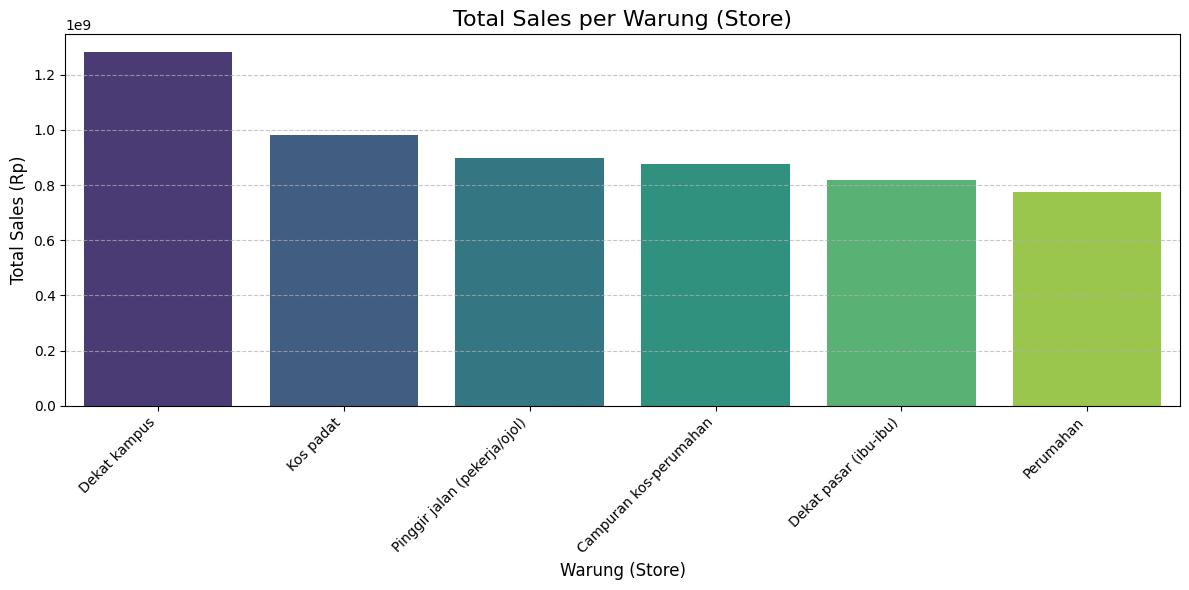

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total sales for each warung_id
df_penjualan['total_harga'] = df_penjualan['jumlah'] * df_penjualan['harga_jual']
sales_per_warung = df_penjualan.groupby('warung_id')['total_harga'].sum().reset_index()

# Merge with df_warung to get warung names
sales_per_warung = pd.merge(sales_per_warung, df_warung[['warung_id', 'nama']], on='warung_id', how='left')

# Sort for better visualization
sales_per_warung = sales_per_warung.sort_values(by='total_harga', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='nama', y='total_harga', data=sales_per_warung, palette='viridis')
plt.title('Total Sales per Warung (Store)', fontsize=16)
plt.xlabel('Warung (Store)', fontsize=12)
plt.ylabel('Total Sales (Rp)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


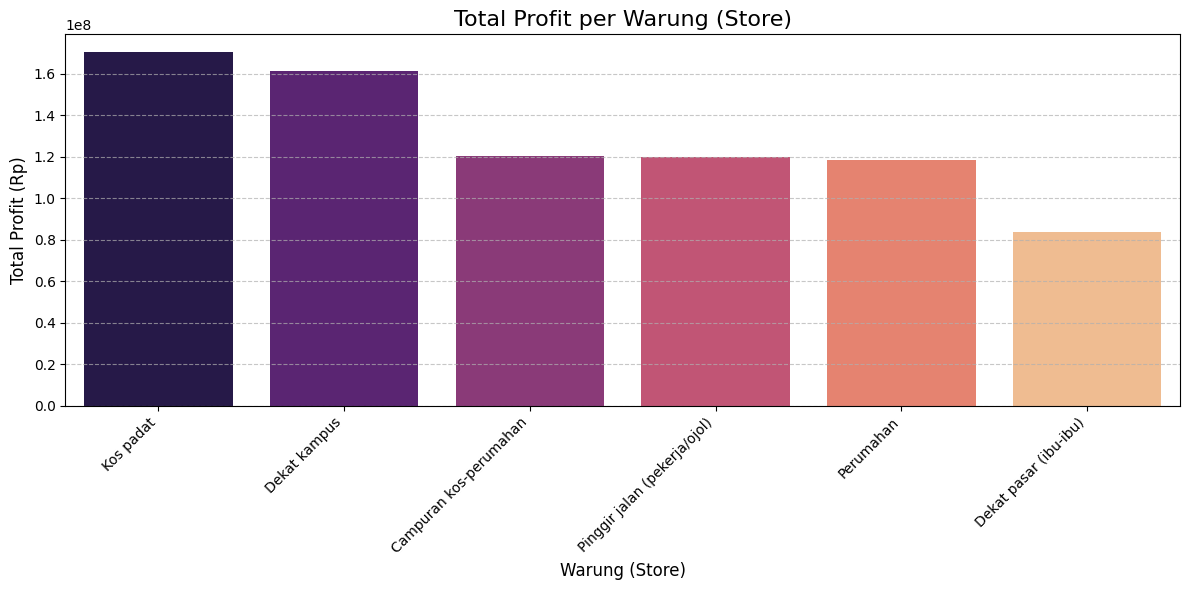

In [ ]:
# Calculate profit per transaction item
df_penjualan['profit_per_item'] = df_penjualan['harga_jual'] - df_penjualan['harga_beli']
df_penjualan['total_profit'] = df_penjualan['profit_per_item'] * df_penjualan['jumlah']

# Group by warung_id and calculate total profit
profit_per_warung = df_penjualan.groupby('warung_id')['total_profit'].sum().reset_index()

# Merge with df_warung to get warung names
profit_per_warung = pd.merge(profit_per_warung, df_warung[['warung_id', 'nama']], on='warung_id', how='left')

# Sort for better visualization
profit_per_warung = profit_per_warung.sort_values(by='total_profit', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='nama', y='total_profit', data=profit_per_warung, palette='magma', hue='nama', legend=False)
plt.title('Total Profit per Warung (Store)', fontsize=16)
plt.xlabel('Warung (Store)', fontsize=12)
plt.ylabel('Total Profit (Rp)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

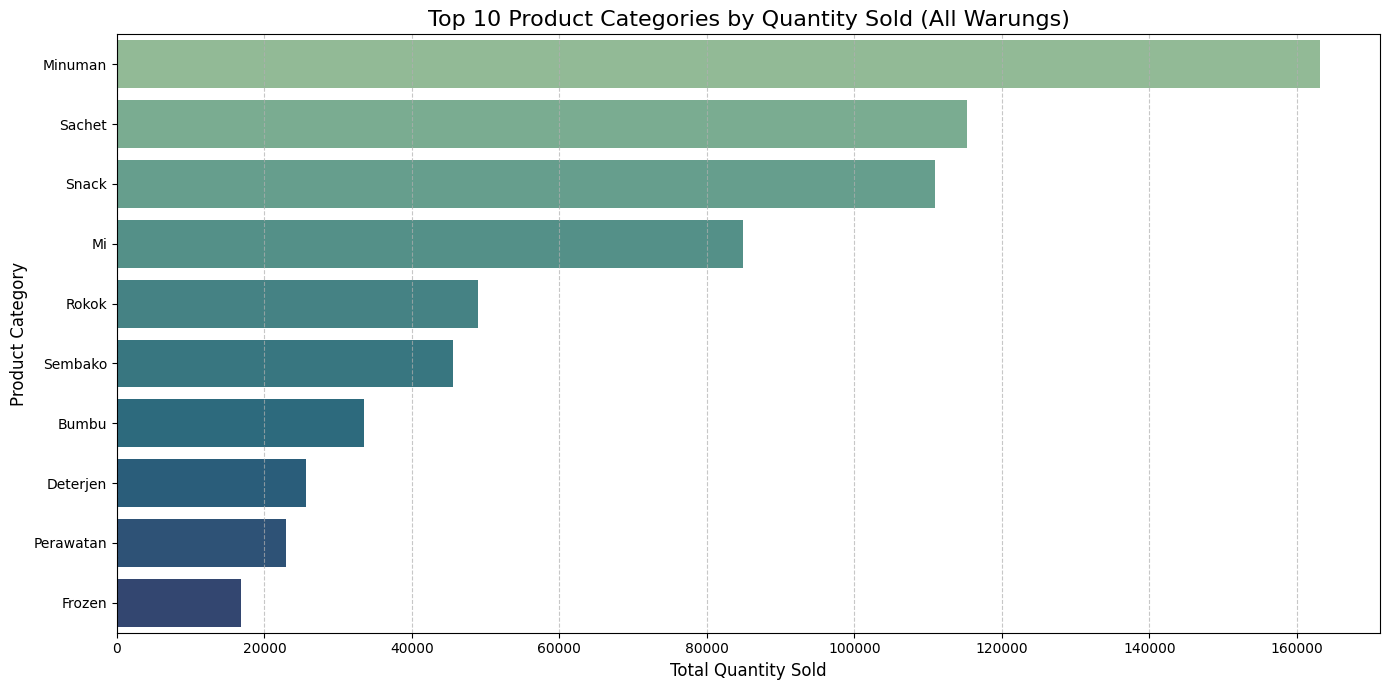

In [ ]:
# Group by category and sum the quantity sold
category_sales = df_penjualan.groupby('kategori')['jumlah'].sum().reset_index()

# Sort by total quantity sold in descending order and take the top N categories
top_n = 10 # You can adjust this number
top_categories = category_sales.sort_values(by='jumlah', ascending=False).head(top_n)

plt.figure(figsize=(14, 7))
sns.barplot(x='jumlah', y='kategori', data=top_categories, palette='crest', hue='kategori', legend=False)
plt.title(f'Top {top_n} Product Categories by Quantity Sold (All Warungs)', fontsize=16)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

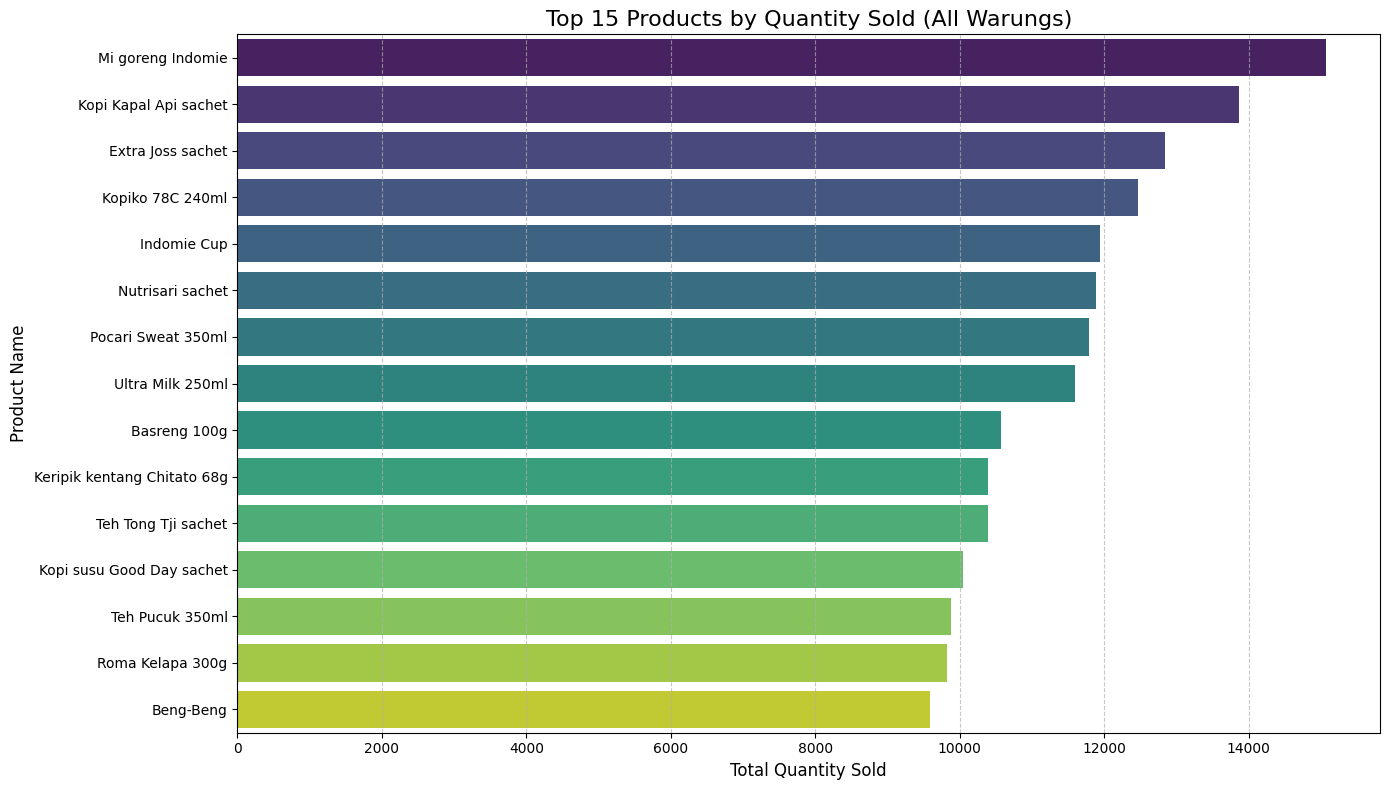

In [ ]:
# Group by product name and sum the quantity sold
product_sales = df_penjualan.groupby('produk')['jumlah'].sum().reset_index()

# Sort by total quantity sold in descending order and take the top N products
top_n_products = 15 # You can adjust this number
top_products = product_sales.sort_values(by='jumlah', ascending=False).head(top_n_products)

plt.figure(figsize=(14, 8))
sns.barplot(x='jumlah', y='produk', data=top_products, palette='viridis', hue='produk', legend=False)
plt.title(f'Top {top_n_products} Products by Quantity Sold (All Warungs)', fontsize=16)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

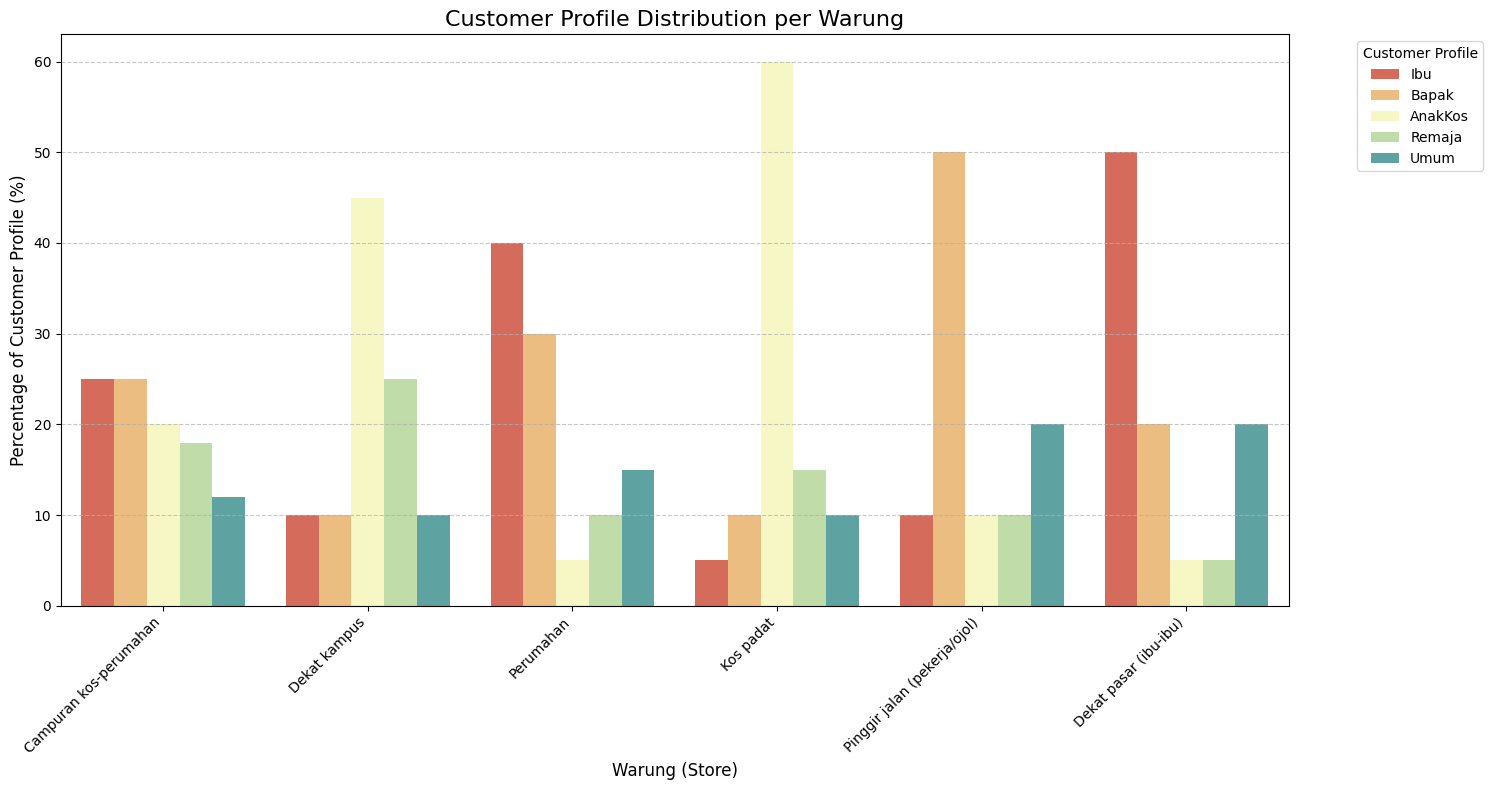

In [ ]:
# To analyze customer profiles per warung, we need to extract this information from the simulation configuration.
# First, let's process the CONFIG_WARUNG to create a DataFrame suitable for visualization.

# Prepare data for customer profiles per warung
profile_data = []
for warung_cfg in CONFIG_WARUNG:
    warung_id = warung_cfg['id']
    warung_name = warung_cfg['nama']
    total_weight = sum(weight for _, weight in warung_cfg['bobot_profil'])
    for profile, weight in warung_cfg['bobot_profil']:
        profile_data.append({
            'warung_id': warung_id,
            'nama': warung_name,
            'profil': profile,
            'percentage': (weight / total_weight) * 100
        })

df_profiles = pd.DataFrame(profile_data)

plt.figure(figsize=(15, 8))
sns.barplot(x='nama', y='percentage', hue='profil', data=df_profiles, palette='Spectral')
plt.title('Customer Profile Distribution per Warung', fontsize=16)
plt.xlabel('Warung (Store)', fontsize=12)
plt.ylabel('Percentage of Customer Profile (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Profile', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

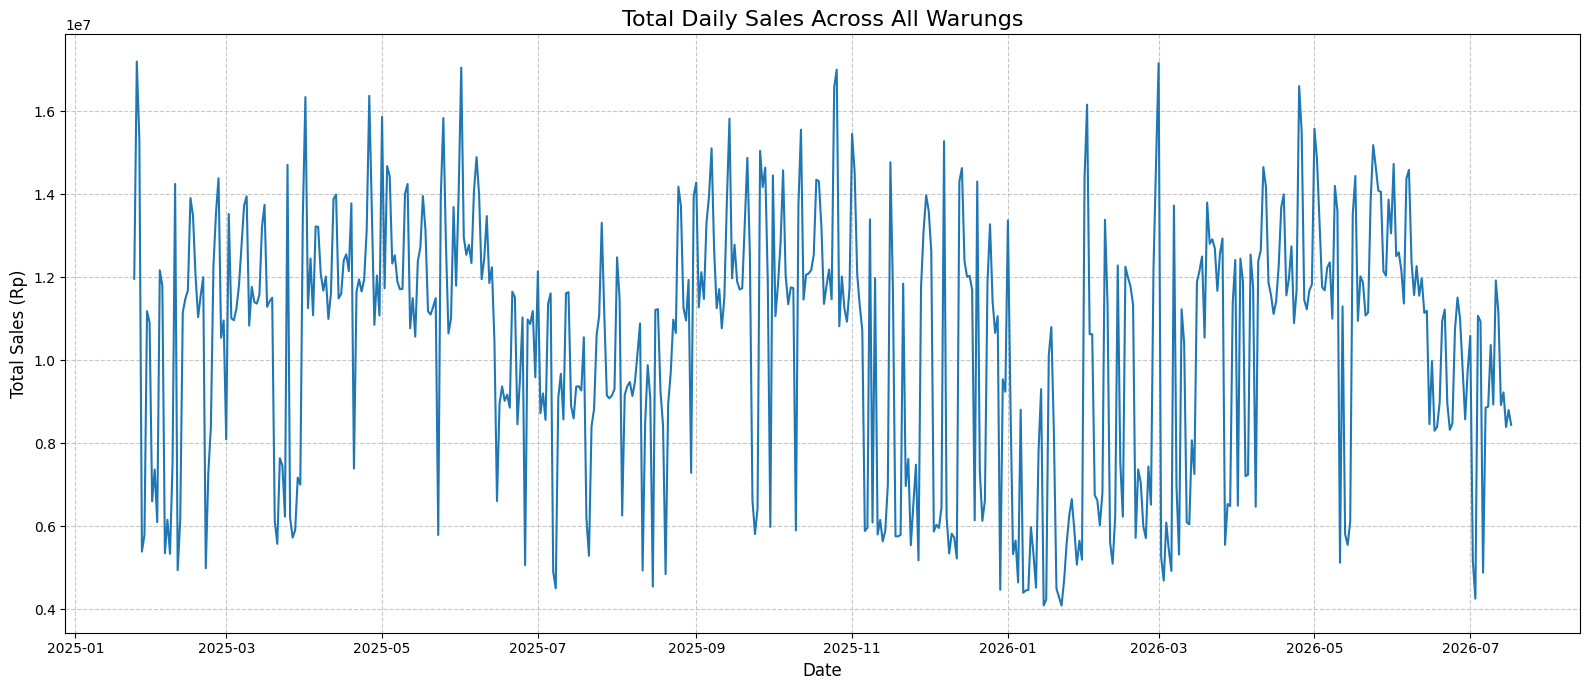

In [ ]:
# Ensure 'tanggal' is in datetime format for time-series analysis
df_penjualan['tanggal'] = pd.to_datetime(df_penjualan['tanggal'])

# Calculate daily total sales across all warungs
daily_sales = df_penjualan.groupby('tanggal')['total_harga'].sum().reset_index()

plt.figure(figsize=(16, 7))
sns.lineplot(x='tanggal', y='total_harga', data=daily_sales)
plt.title('Total Daily Sales Across All Warungs', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (Rp)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

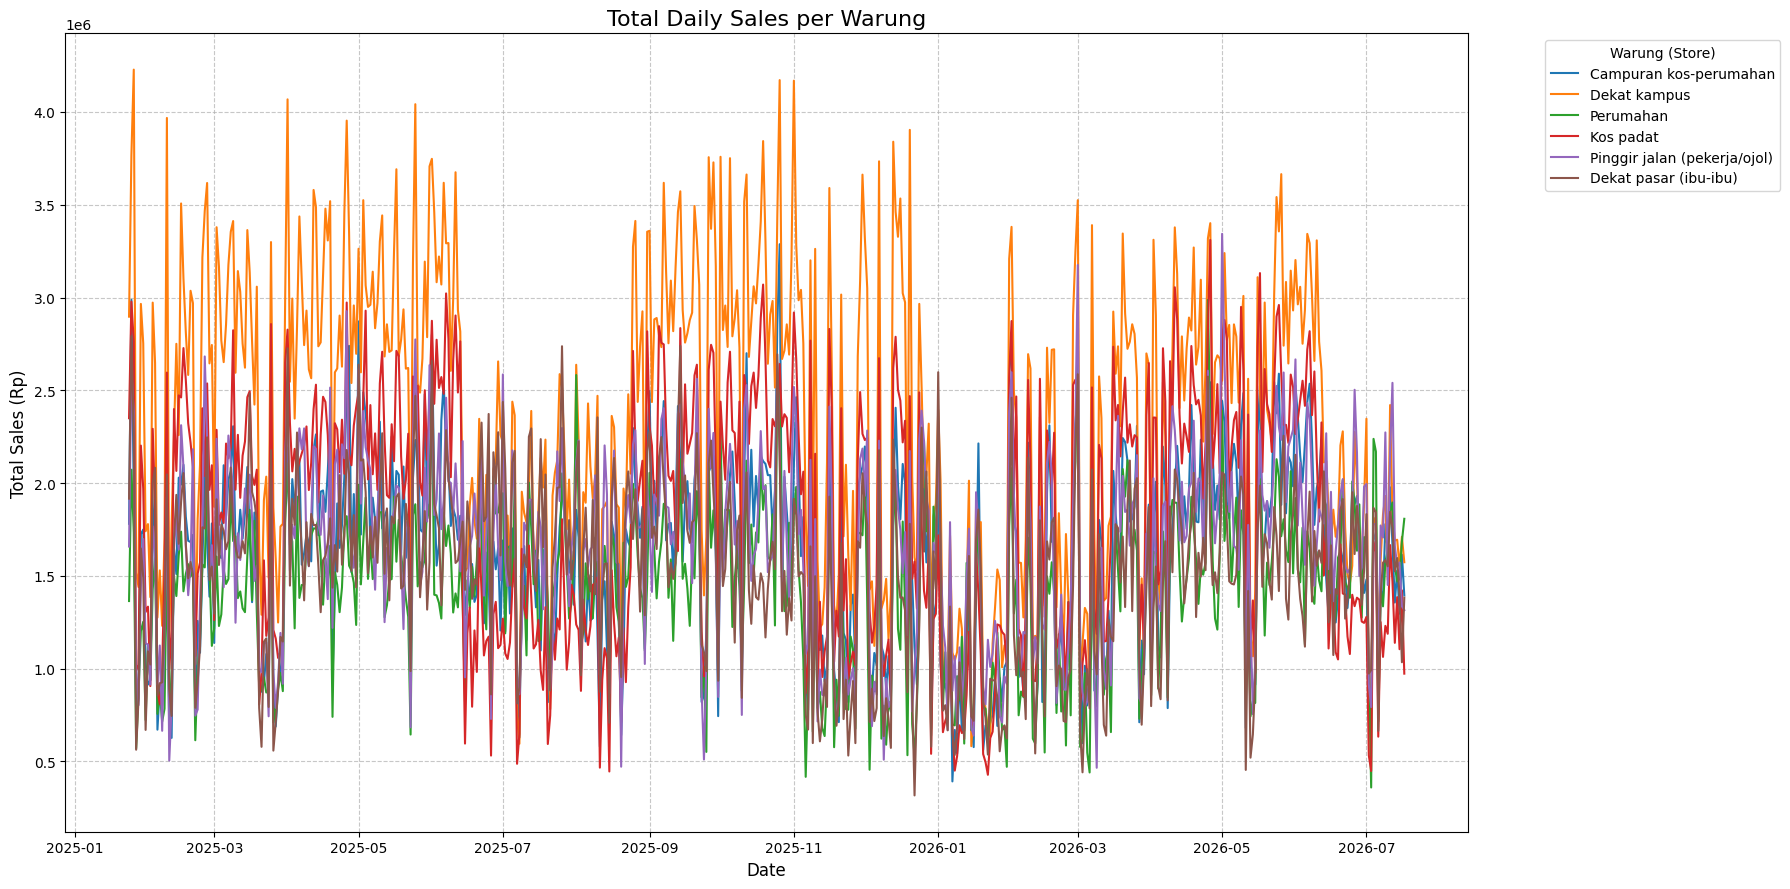

In [ ]:
# Calculate daily total sales for each warung
daily_sales_per_warung = df_penjualan.groupby(['tanggal', 'warung_id'])['total_harga'].sum().reset_index()

# Merge with df_warung to get warung names for better labels
daily_sales_per_warung = pd.merge(daily_sales_per_warung,
                                  df_warung[['warung_id', 'nama']],
                                  on='warung_id', how='left')

plt.figure(figsize=(18, 9))
sns.lineplot(x='tanggal', y='total_harga', hue='nama', data=daily_sales_per_warung)
plt.title('Total Daily Sales per Warung', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (Rp)', fontsize=12)
plt.legend(title='Warung (Store)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4045/3875123061.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_categories_per_warung = category_sales_per_warung.groupby('warung_id').apply(get_top_n_categories).reset_index(drop=True)


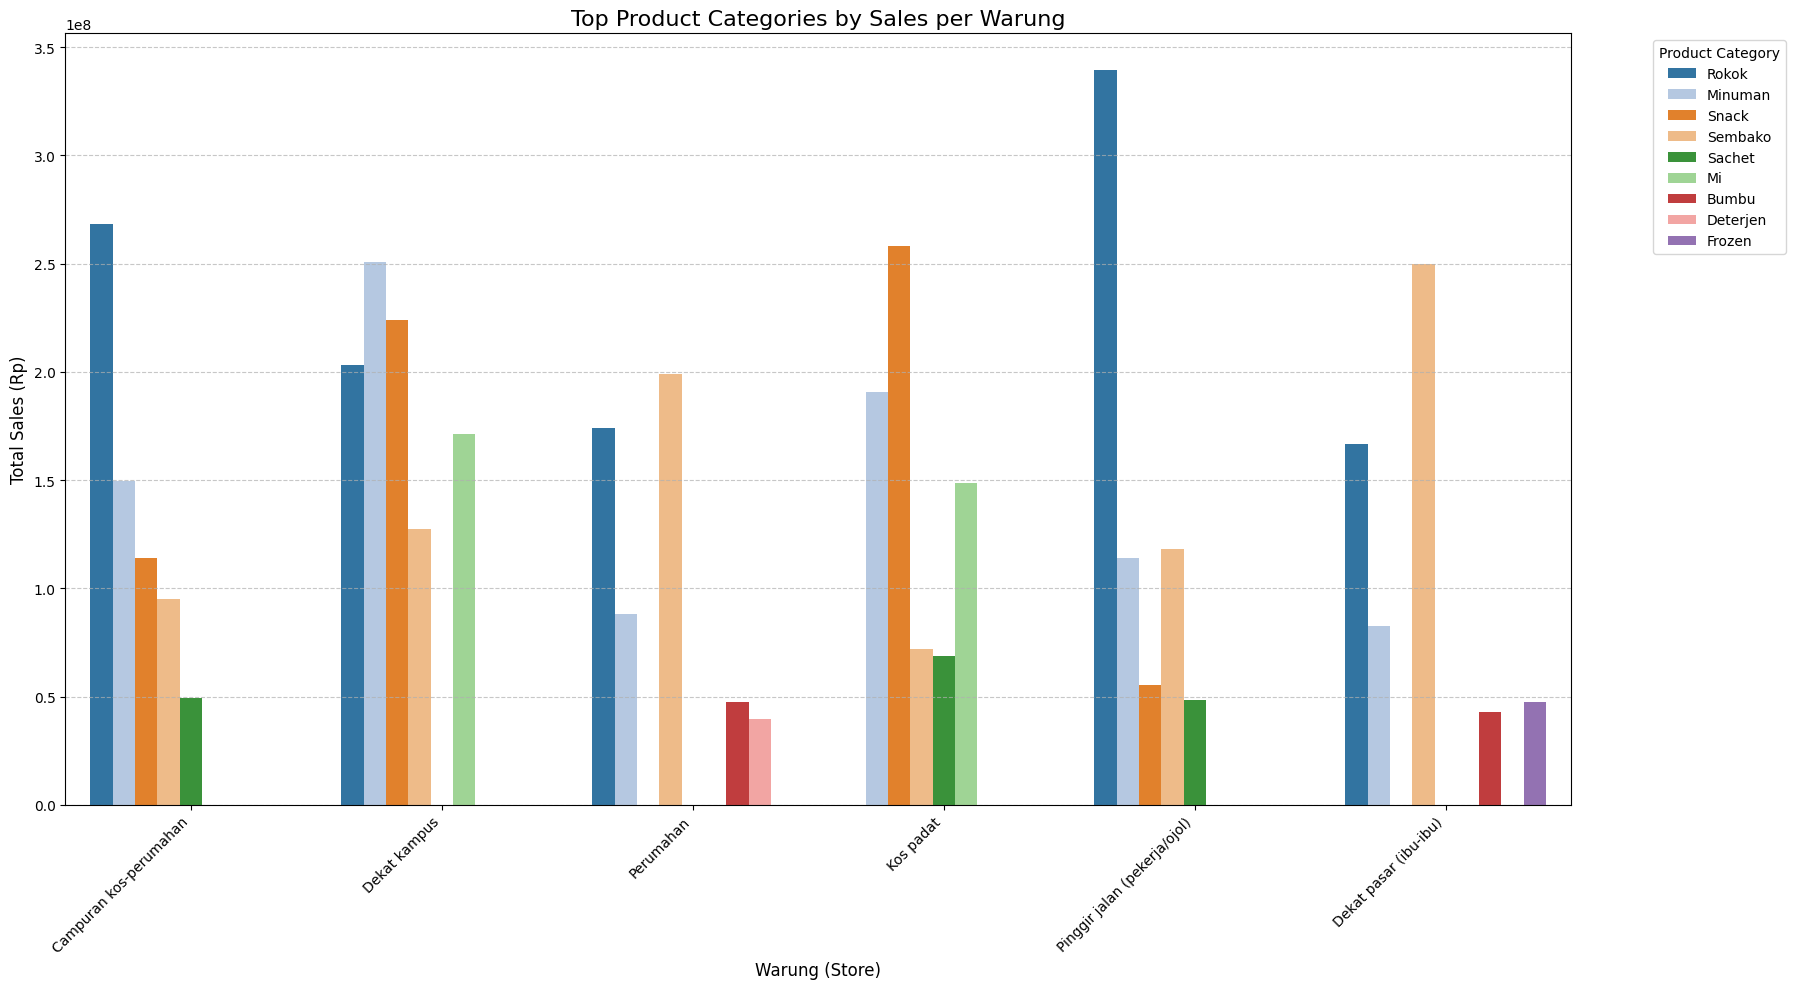

In [ ]:
# Calculate total sales per category for each warung
category_sales_per_warung = df_penjualan.groupby(['warung_id', 'kategori'])['total_harga'].sum().reset_index()

# Merge with df_warung to get warung names
category_sales_per_warung = pd.merge(category_sales_per_warung,
                                     df_warung[['warung_id', 'nama']],
                                     on='warung_id', how='left')

# Get top categories for each warung for better readability if there are many categories
def get_top_n_categories(df, n=5):
    return df.sort_values(by='total_harga', ascending=False).head(n)

top_categories_per_warung = category_sales_per_warung.groupby('warung_id').apply(get_top_n_categories).reset_index(drop=True)

plt.figure(figsize=(18, 10))
sns.barplot(x='nama', y='total_harga', hue='kategori', data=top_categories_per_warung, palette='tab20')
plt.title('Top Product Categories by Sales per Warung', fontsize=16)
plt.xlabel('Warung (Store)', fontsize=12)
plt.ylabel('Total Sales (Rp)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

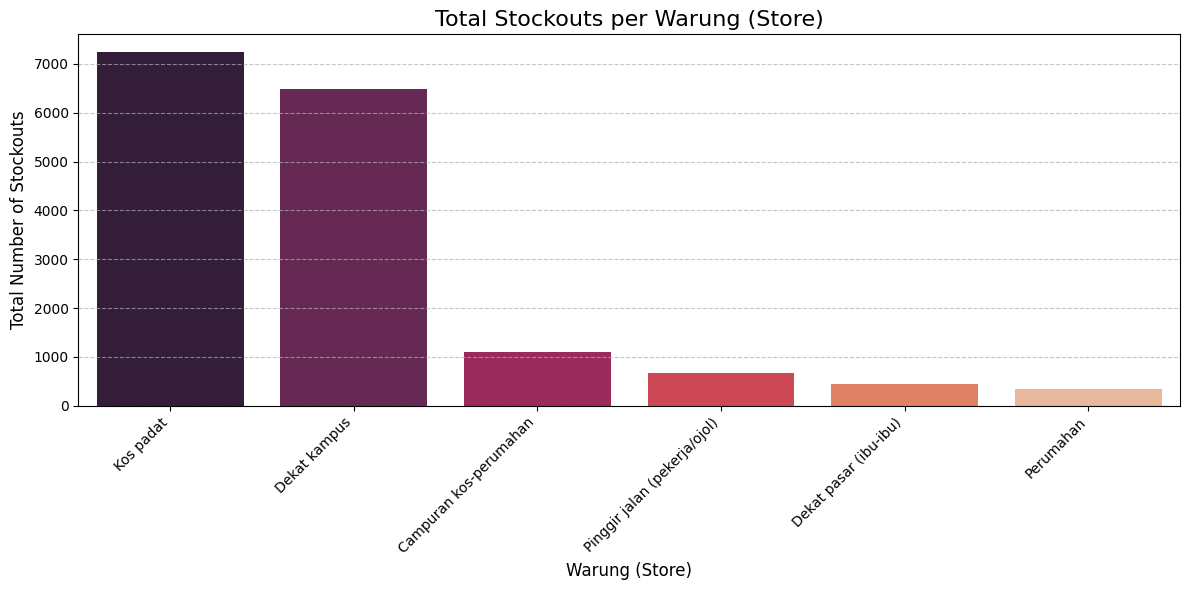

In [ ]:
# Load stockout.csv into a DataFrame
df_stockout = pd.read_csv(f'{data_dir}stockout.csv')

# Calculate total stockouts for each warung_id
stockouts_per_warung = df_stockout.groupby('warung_id').size().reset_index(name='total_stockouts')

# Merge with df_warung to get warung names
stockouts_per_warung = pd.merge(stockouts_per_warung, df_warung[['warung_id', 'nama']], on='warung_id', how='left')

# Sort for better visualization
stockouts_per_warung = stockouts_per_warung.sort_values(by='total_stockouts', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='nama', y='total_stockouts', data=stockouts_per_warung, palette='rocket', hue='nama', legend=False)
plt.title('Total Stockouts per Warung (Store)', fontsize=16)
plt.xlabel('Warung (Store)', fontsize=12)
plt.ylabel('Total Number of Stockouts', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

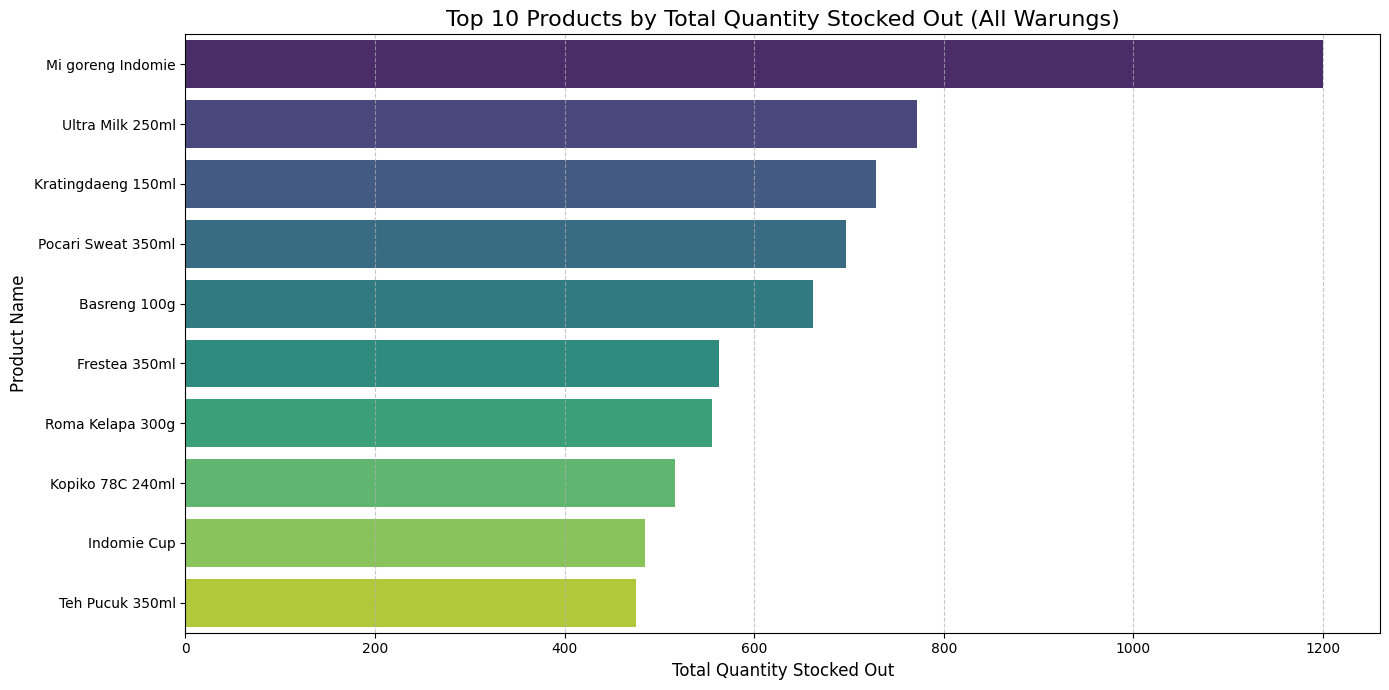

In [ ]:
# Calculate total stockouts for each product
product_stockouts = df_stockout.groupby('produk')['jumlah_hilang'].sum().reset_index()

# Sort by total stockouts in descending order and take the top N products
top_n_stockout_products = 10 # You can adjust this number
top_stockout_products = product_stockouts.sort_values(by='jumlah_hilang', ascending=False).head(top_n_stockout_products)

plt.figure(figsize=(14, 7))
sns.barplot(x='jumlah_hilang', y='produk', data=top_stockout_products, palette='viridis', hue='produk', legend=False)
plt.title(f'Top {top_n_stockout_products} Products by Total Quantity Stocked Out (All Warungs)', fontsize=16)
plt.xlabel('Total Quantity Stocked Out', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

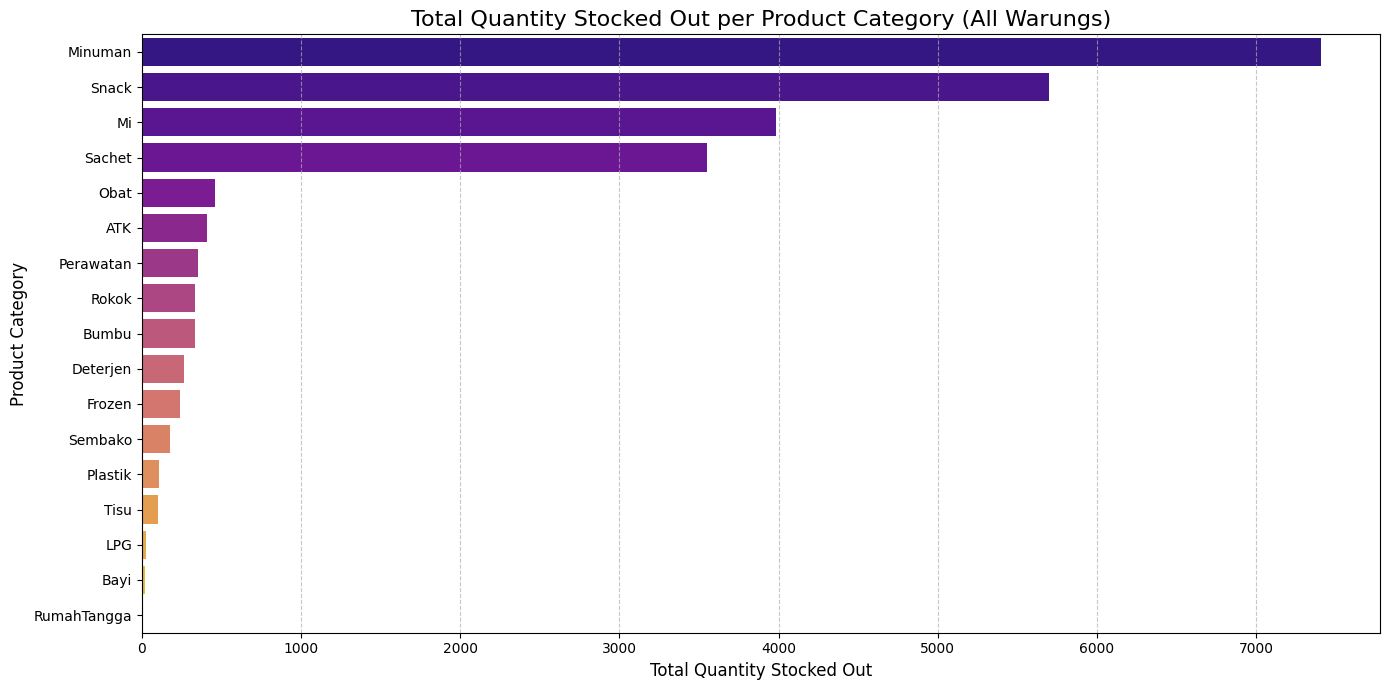

In [ ]:
# Create a DataFrame mapping product names to categories from the DATA list
product_category_map = pd.DataFrame(DATA, columns=['kategori', 'produk', 'harga_jual_dummy'])[['kategori', 'produk']]

# Merge df_stockout with the product_category_map to get the 'kategori' column
df_stockout_with_category = pd.merge(df_stockout, product_category_map, on='produk', how='left')

# Calculate total stockouts for each product category
category_stockouts = df_stockout_with_category.groupby('kategori')['jumlah_hilang'].sum().reset_index()

# Sort by total stockouts in descending order
category_stockouts = category_stockouts.sort_values(by='jumlah_hilang', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x='jumlah_hilang', y='kategori', data=category_stockouts, palette='plasma', hue='kategori', legend=False)
plt.title('Total Quantity Stocked Out per Product Category (All Warungs)', fontsize=16)
plt.xlabel('Total Quantity Stocked Out', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

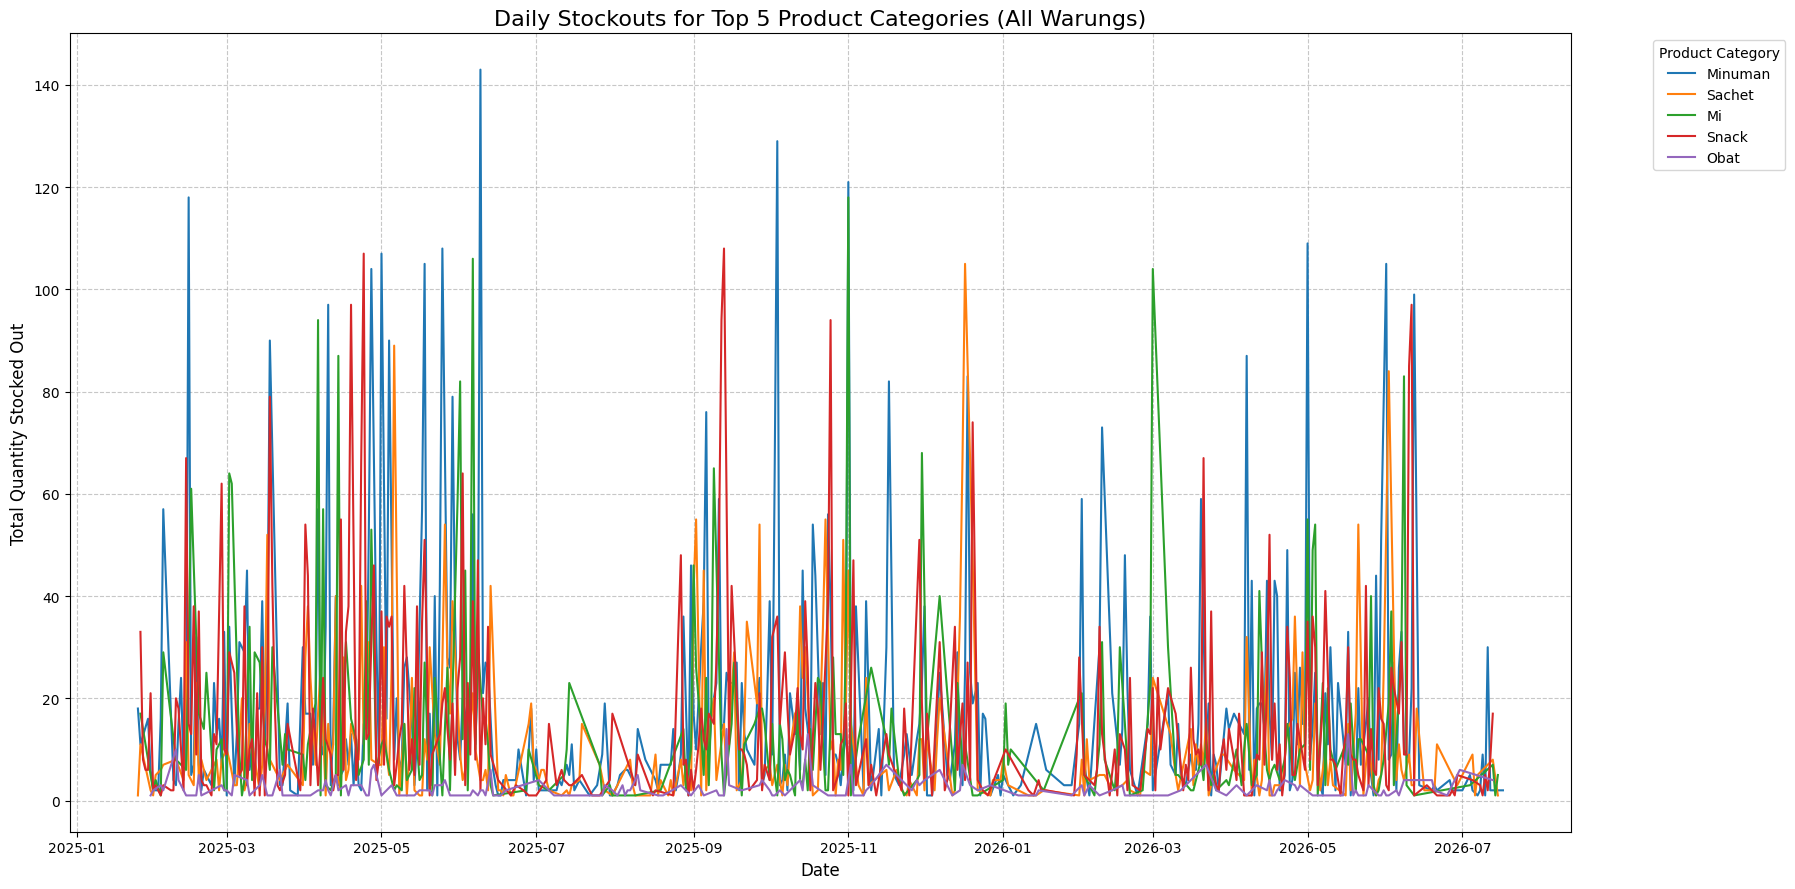

In [ ]:
# Get the top N stockout categories
top_n_categories = 5 # Adjust as needed
top_stockout_category_names = category_stockouts['kategori'].head(top_n_categories).tolist()

# Filter the df_stockout_with_category for only these top categories and create a copy
df_top_category_stockouts = df_stockout_with_category[df_stockout_with_category['kategori'].isin(top_stockout_category_names)].copy()

# Ensure 'tanggal' is in datetime format
df_top_category_stockouts['tanggal'] = pd.to_datetime(df_top_category_stockouts['tanggal'])

# Group by date and category to get daily stockouts per category
daily_category_stockouts = df_top_category_stockouts.groupby(['tanggal', 'kategori'])['jumlah_hilang'].sum().reset_index()

plt.figure(figsize=(18, 9))
sns.lineplot(x='tanggal', y='jumlah_hilang', hue='kategori', data=daily_category_stockouts, palette='tab10')
plt.title(f'Daily Stockouts for Top {top_n_categories} Product Categories (All Warungs)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Quantity Stocked Out', fontsize=12)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

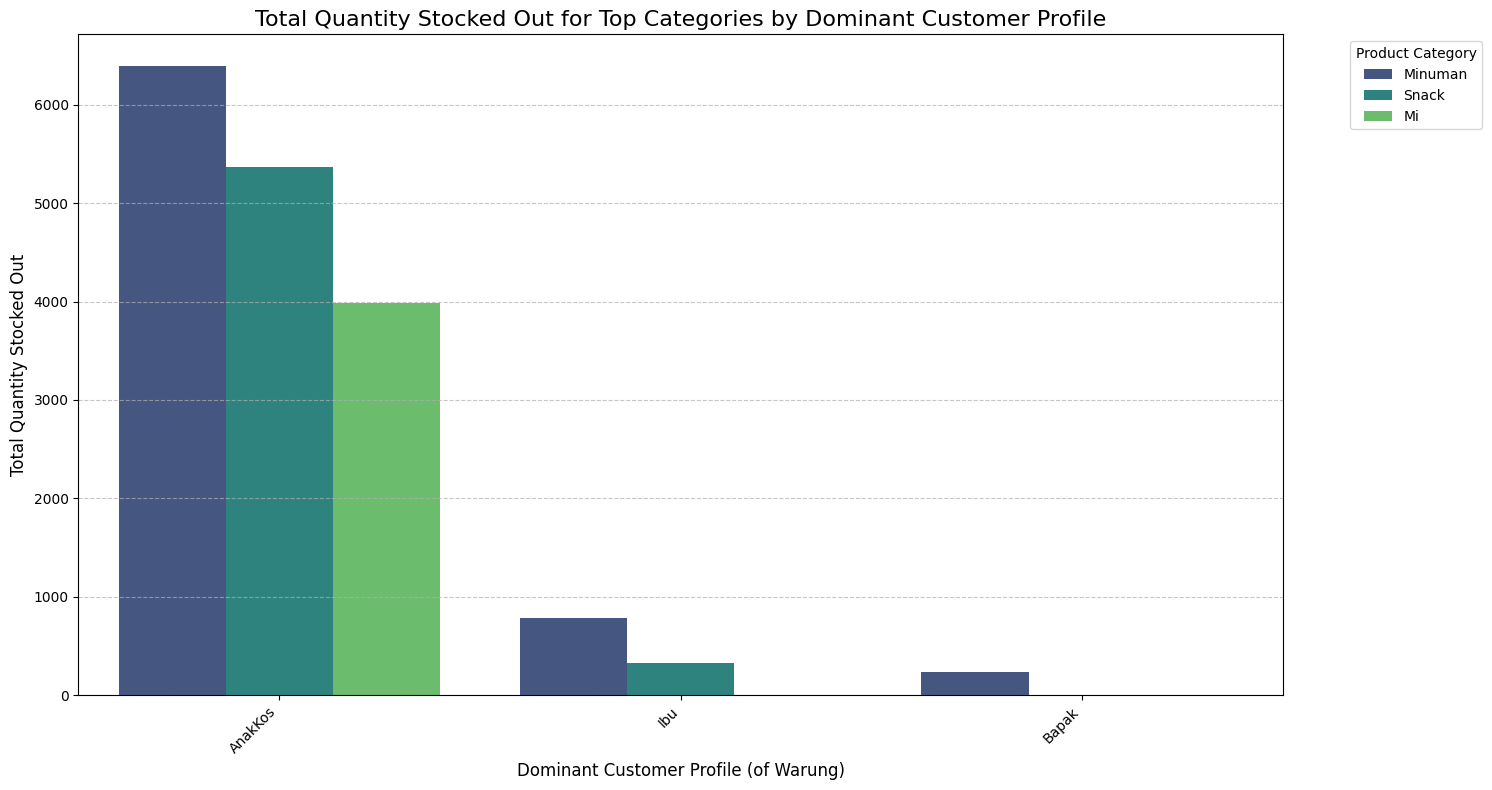

In [ ]:
# To analyze customer profiles and their relation to stockouts, we need to link customer profiles to sales data.
# However, the df_stockout DataFrame only contains product and warung information.
# The customer profile information (like PROFIL and CONFIG_WARUNG['bobot_profil']) is part of the simulation configuration.
# A direct correlation between a specific customer's purchase and a stockout event is not in the logged data.
# Instead, we can look at the overall distribution of stockouts for certain categories in warungs where certain profiles are dominant.

# Let's consider the top 3 stockout categories identified previously:
top_stockout_category_names = category_stockouts['kategori'].head(3).tolist()

# We will use the CONFIG_WARUNG data to get the dominant customer profiles for each warung
warung_profiles_data = []
for warung_cfg in CONFIG_WARUNG:
    warung_id = warung_cfg['id']
    # Get the dominant profile (highest percentage) for each warung
    dominant_profile = max(warung_cfg['bobot_profil'], key=lambda item: item[1])
    warung_profiles_data.append({'warung_id': warung_id, 'dominant_profile': dominant_profile[0]})

df_warung_profiles = pd.DataFrame(warung_profiles_data)

# Merge stockout data with warung profiles and product categories
df_stockout_merged = pd.merge(df_stockout_with_category, df_warung_profiles, on='warung_id', how='left')

# Filter for the top stockout categories
df_stockout_top_categories = df_stockout_merged[df_stockout_merged['kategori'].isin(top_stockout_category_names)]

# Group by dominant profile and category to see stockout quantities
stockouts_by_profile_category = df_stockout_top_categories.groupby(['dominant_profile', 'kategori'])['jumlah_hilang'].sum().reset_index()

# Sort for better visualization
stockouts_by_profile_category = stockouts_by_profile_category.sort_values(by='jumlah_hilang', ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x='dominant_profile', y='jumlah_hilang', hue='kategori', data=stockouts_by_profile_category, palette='viridis')
plt.title('Total Quantity Stocked Out for Top Categories by Dominant Customer Profile', fontsize=16)
plt.xlabel('Dominant Customer Profile (of Warung)', fontsize=12)
plt.ylabel('Total Quantity Stocked Out', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4045/639951039.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_stockout_products_per_warung = stockouts_per_product_per_warung.groupby('warung_id').apply(get_top_n_stockout_products_per_warung).reset_index(drop=True)


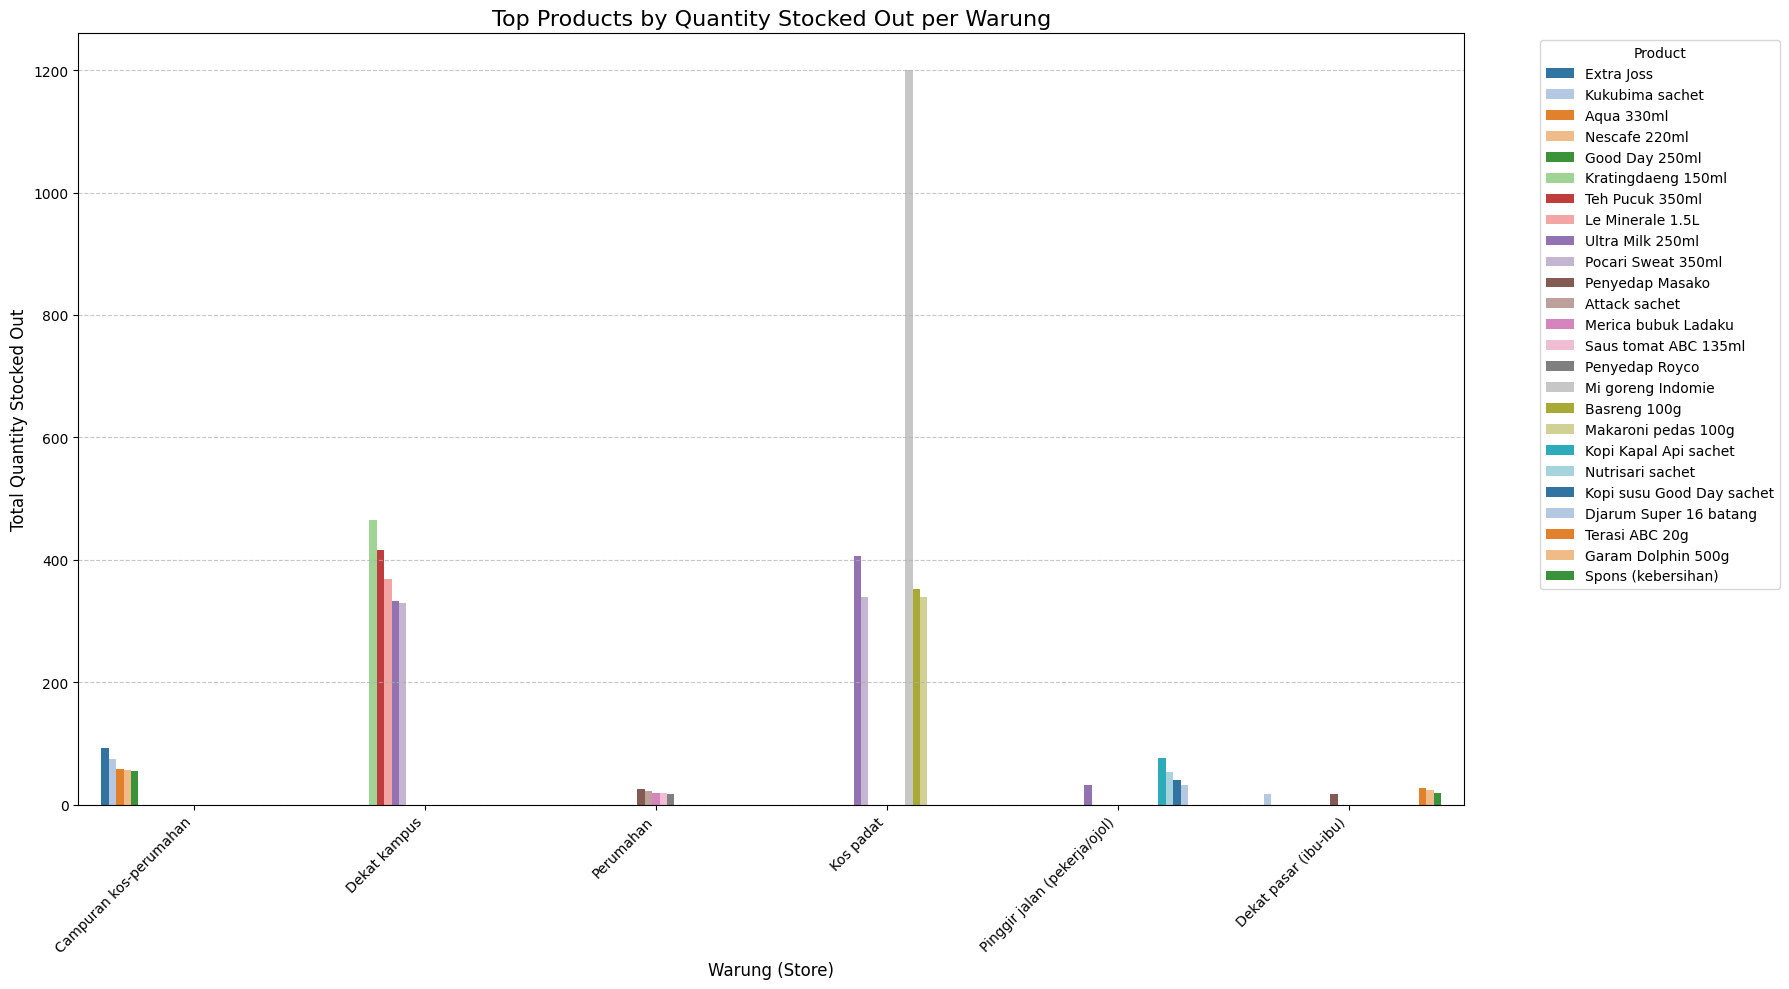

In [ ]:
# Calculate total stockouts for each product per warung
stockouts_per_product_per_warung = df_stockout_with_category.groupby(['warung_id', 'produk'])['jumlah_hilang'].sum().reset_index()

# Get top N stockout products for each warung
def get_top_n_stockout_products_per_warung(df, n=5):
    return df.sort_values(by='jumlah_hilang', ascending=False).head(n)

top_stockout_products_per_warung = stockouts_per_product_per_warung.groupby('warung_id').apply(get_top_n_stockout_products_per_warung).reset_index(drop=True)

# Merge with df_warung to get warung names
top_stockout_products_per_warung = pd.merge(top_stockout_products_per_warung,
                                            df_warung[['warung_id', 'nama']],
                                            on='warung_id', how='left')

plt.figure(figsize=(18, 10))
sns.barplot(x='nama', y='jumlah_hilang', hue='produk', data=top_stockout_products_per_warung, palette='tab20')
plt.title('Top Products by Quantity Stocked Out per Warung', fontsize=16)
plt.xlabel('Warung (Store)', fontsize=12)
plt.ylabel('Total Quantity Stocked Out', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import argparse
import csv
import math
import sqlite3
from collections import defaultdict
from datetime import date, timedelta
from pathlib import Path
from statistics import NormalDist, mean, stdev

# ============================================================
# UTILITAS
# ============================================================
def rp(n):
    """Format rupiah, contoh: Rp1.250.000 (negatif: -Rp1.250.000)."""
    n = int(round(n))
    teks = "Rp" + format(abs(n), ",").replace(",", ".")
    return "-" + teks if n < 0 else teks


def persen(x, desimal=1):
    return f"{100 * x:.{desimal}f}%"


def tabel(judul, baris, kolom, maks=None):
    """Cetak tabel sederhana. kolom = [(kunci, judul_kolom, fungsi_format_atau_None)]."""
    print(f"\n=== {judul} ===")
    if not baris:
        print("(kosong)")
        return
    data = baris[:maks] if maks else baris
    sel = [[(f(r[k]) if f else str(r[k])) for k, _, f in kolom] for r in data]
    lebar = [max(len(h), *(len(s[i]) for s in sel)) for i, (_, h, _) in enumerate(kolom)]
    print("  ".join(h.ljust(lebar[i]) for i, (_, h, _) in enumerate(kolom)))
    print("  ".join("-" * w for w in lebar))
    for s in sel:
        print("  ".join(v.ljust(lebar[i]) for i, v in enumerate(s)))
    if maks and len(baris) > maks:
        print(f"... ({len(baris) - maks} baris lain)")


def hpp_baru(stok, hpp, qty, harga_beli):
    """HPP rata-rata bergerak. Jika stok habis, HPP = harga beli terbaru."""
    if stok <= 0:
        return float(harga_beli)
    return (stok * hpp + qty * harga_beli) / (stok + qty)


# ============================================================
# BAGIAN A1 - SKEMA DATABASE
# ============================================================
SKEMA = """
CREATE TABLE IF NOT EXISTS produk (
    warung_id  TEXT NOT NULL,
    produk     TEXT NOT NULL,
    kategori   TEXT NOT NULL DEFAULT 'Lainnya',
    stok       INTEGER NOT NULL DEFAULT 0,
    hpp        REAL NOT NULL DEFAULT 0,
    harga_jual INTEGER NOT NULL DEFAULT 0,
    PRIMARY KEY (warung_id, produk)
);
CREATE TABLE IF NOT EXISTS transaksi (
    trx_id    TEXT PRIMARY KEY,
    warung_id TEXT NOT NULL,
    tanggal   TEXT NOT NULL,
    jam       TEXT NOT NULL
);
CREATE TABLE IF NOT EXISTS item_transaksi (
    id         INTEGER PRIMARY KEY AUTOINCREMENT,
    trx_id     TEXT NOT NULL REFERENCES transaksi(trx_id),
    warung_id  TEXT NOT NULL,
    tanggal    TEXT NOT NULL,
    jam        TEXT NOT NULL,
    produk     TEXT NOT NULL,
    jumlah     INTEGER NOT NULL CHECK (jumlah > 0),
    harga_jual INTEGER NOT NULL,
    hpp        REAL NOT NULL            -- HPP saat barang dijual (untuk COGS)
);
CREATE TABLE IF NOT EXISTS pembelian (
    id         INTEGER PRIMARY KEY AUTOINCREMENT,
    warung_id  TEXT NOT NULL,
    tanggal    TEXT NOT NULL,
    produk     TEXT NOT NULL,
    jumlah     INTEGER NOT NULL CHECK (jumlah > 0),
    harga_beli INTEGER NOT NULL
);
CREATE TABLE IF NOT EXISTS kas_lain (       -- modal, biaya operasional, prive
    id         INTEGER PRIMARY KEY AUTOINCREMENT,
    warung_id  TEXT NOT NULL,
    tanggal    TEXT NOT NULL,
    jenis      TEXT NOT NULL CHECK (jenis IN ('MODAL','BIAYA','PRIVE')),
    keterangan TEXT NOT NULL DEFAULT '',
    jumlah     INTEGER NOT NULL CHECK (jumlah > 0)
);
CREATE TABLE IF NOT EXISTS stockout (        -- permintaan yang hilang karena stok habis
    id            INTEGER PRIMARY KEY AUTOINCREMENT,
    warung_id     TEXT NOT NULL,
    tanggal       TEXT NOT NULL,
    jam           TEXT NOT NULL,
    produk        TEXT NOT NULL,
    jumlah_hilang INTEGER NOT NULL,
    disubstitusi  INTEGER NOT NULL DEFAULT 0
);
CREATE INDEX IF NOT EXISTS ix_item_w_tgl  ON item_transaksi (warung_id, tanggal);
CREATE INDEX IF NOT EXISTS ix_item_w_prod ON item_transaksi (warung_id, produk, tanggal);
CREATE INDEX IF NOT EXISTS ix_beli_w_tgl  ON pembelian (warung_id, tanggal);
CREATE INDEX IF NOT EXISTS ix_kas_w_tgl   ON kas_lain (warung_id, tanggal);
CREATE INDEX IF NOT EXISTS ix_so_w_prod   ON stockout (warung_id, produk, tanggal);
"""


def buka_db(path="warungsmart.db"):
    con = sqlite3.connect(path)
    con.execute("PRAGMA foreign_keys = ON")
    con.executescript(SKEMA)
    return con


# ============================================================
# BAGIAN A2 - PENCATATAN TRANSAKSI (dipakai aplikasi secara langsung)
# ============================================================
def catat_pembelian(con, warung_id, tanggal, produk, jumlah, harga_beli,
                    kategori="Lainnya", komit=True):
    """Barang masuk: menambah stok dan memperbarui HPP rata-rata bergerak."""
    if jumlah <= 0 or harga_beli <= 0:
        raise ValueError("jumlah dan harga_beli harus > 0")
    r = con.execute("SELECT stok, hpp FROM produk WHERE warung_id=? AND produk=?",
                    (warung_id, produk)).fetchone()
    if r is None:
        con.execute("INSERT INTO produk (warung_id, produk, kategori, stok, hpp, harga_jual) "
                    "VALUES (?,?,?,?,?,0)", (warung_id, produk, kategori, jumlah, harga_beli))
    else:
        stok, hpp = r
        con.execute("UPDATE produk SET stok=?, hpp=? WHERE warung_id=? AND produk=?",
                    (stok + jumlah, hpp_baru(stok, hpp, jumlah, harga_beli), warung_id, produk))
    con.execute("INSERT INTO pembelian (warung_id, tanggal, produk, jumlah, harga_beli) "
                "VALUES (?,?,?,?,?)", (warung_id, tanggal, produk, jumlah, harga_beli))
    if komit:
        con.commit()


def catat_penjualan(con, warung_id, tanggal, jam, items, trx_id=None, komit=True):
    """
    Satu nota penjualan. items = [(produk, jumlah) atau (produk, jumlah, harga_jual), ...]
    Semua item divalidasi dulu; jika ada yang gagal, tidak ada yang tersimpan.
    Mengembalikan trx_id.
    """
    if not items:
        raise ValueError("nota kosong")
    sisa, baris = {}, []
    for it in items:
        produk, jumlah = it[0], int(it[1])
        r = con.execute("SELECT stok, hpp, harga_jual FROM produk WHERE warung_id=? AND produk=?",
                        (warung_id, produk)).fetchone()
        if r is None:
            raise ValueError(f"produk '{produk}' belum terdaftar")
        if jumlah <= 0:
            raise ValueError("jumlah harus > 0")
        stok, hpp, harga_default = r
        stok = sisa.get(produk, stok)
        if jumlah > stok:
            raise ValueError(f"stok '{produk}' tidak cukup (sisa {stok}, diminta {jumlah})")
        harga = int(it[2]) if len(it) > 2 and it[2] is not None else harga_default
        if harga <= 0:
            raise ValueError(f"harga jual '{produk}' belum diatur")
        sisa[produk] = stok - jumlah
        baris.append((produk, jumlah, harga, hpp))

    if trx_id is None:
        n = con.execute("SELECT COUNT(*) FROM transaksi WHERE warung_id=? AND tanggal=?",
                        (warung_id, tanggal)).fetchone()[0] + 1
        trx_id = f"{warung_id}-{tanggal.replace('-', '')}-{n:04d}"
    con.execute("INSERT INTO transaksi (trx_id, warung_id, tanggal, jam) VALUES (?,?,?,?)",
                (trx_id, warung_id, tanggal, jam))
    for produk, jumlah, harga, hpp in baris:
        con.execute("INSERT INTO item_transaksi (trx_id, warung_id, tanggal, jam, produk, "
                    "jumlah, harga_jual, hpp) VALUES (?,?,?,?,?,?,?,?)",
                    (trx_id, warung_id, tanggal, jam, produk, jumlah, harga, hpp))
        con.execute("UPDATE produk SET stok = stok - ?, harga_jual = ? "
                    "WHERE warung_id=? AND produk=?", (jumlah, harga, warung_id, produk))
    if komit:
        con.commit()
    return trx_id


def catat_kas_lain(con, warung_id, tanggal, jenis, jumlah, keterangan="", komit=True):
    """jenis: MODAL (setoran modal), BIAYA (operasional), PRIVE (pengambilan pribadi)."""
    con.execute("INSERT INTO kas_lain (warung_id, tanggal, jenis, keterangan, jumlah) "
                "VALUES (?,?,?,?,?)", (warung_id, tanggal, jenis.upper(), keterangan, int(jumlah)))
    if komit:
        con.commit()


# ============================================================
# IMPOR DATA SIMULASI (luaran warung_abm.py) -> database
# ============================================================
def impor_simulasi(con, folder, warung_ids=None):
    """
    Memutar ulang pembelian & penjualan secara kronologis (pembelian pagi lebih dulu),
    menghitung HPP sendiri, lalu memasukkannya ke database. Mengembalikan laporan impor.
    """
    folder = Path(folder)

    def baca(nama):
        with open(folder / nama, newline="", encoding="utf-8") as f:
            return list(csv.DictReader(f))

    jual_semua, beli_semua = baca("penjualan.csv"), baca("pembelian.csv")
    so_semua = baca("stockout.csv") if (folder / "stockout.csv").exists() else []
    ids = warung_ids or sorted({r["warung_id"] for r in jual_semua})
    laporan = {}

    for wid in ids:
        for tbl in ("item_transaksi", "transaksi", "pembelian", "kas_lain", "stockout", "produk"):
            con.execute(f"DELETE FROM {tbl} WHERE warung_id=?", (wid,))
        beli = [r for r in beli_semua if r["warung_id"] == wid]
        jual = [r for r in jual_semua if r["warung_id"] == wid]
        state = {}                      # produk -> [stok, hpp, kategori, harga_jual]
        rows_beli, rows_trx, rows_item = [], [], []
        seen, selisih_stok, i = set(), 0, 0

        def proses_beli(r):
            p, q, h = r["produk"], int(r["jumlah"]), int(r["harga_beli"])
            s = state.setdefault(p, [0, 0.0, r["kategori"], 0])
            s[1] = hpp_baru(s[0], s[1], q, h)
            s[0] += q
            rows_beli.append((wid, r["tanggal"], p, q, h))

        for r in jual:
            while i < len(beli) and beli[i]["tanggal"] <= r["tanggal"]:
                proses_beli(beli[i])
                i += 1
            s = state[r["produk"]]
            q, hj = int(r["jumlah"]), int(r["harga_jual"])
            if q > s[0]:
                raise ValueError(f"stok negatif untuk {r['produk']} pada {r['tanggal']}")
            if r["trx_id"] not in seen:
                seen.add(r["trx_id"])
                rows_trx.append((r["trx_id"], wid, r["tanggal"], r["jam"]))
            rows_item.append((r["trx_id"], wid, r["tanggal"], r["jam"], r["produk"], q, hj, s[1]))
            s[0] -= q
            s[3] = hj
            if s[0] != int(r["stok_akhir"]):
                selisih_stok += 1
        while i < len(beli):
            proses_beli(beli[i])
            i += 1

        con.executemany("INSERT INTO transaksi VALUES (?,?,?,?)", rows_trx)
        con.executemany("INSERT INTO item_transaksi (trx_id, warung_id, tanggal, jam, produk, "
                        "jumlah, harga_jual, hpp) VALUES (?,?,?,?,?,?,?,?)", rows_item)
        con.executemany("INSERT INTO pembelian (warung_id, tanggal, produk, jumlah, harga_beli) "
                        "VALUES (?,?,?,?,?)", rows_beli)
        con.executemany("INSERT INTO produk VALUES (?,?,?,?,?,?)",
                        [(wid, p, s[2], s[0], s[1], s[3]) for p, s in state.items()])
        con.executemany("INSERT INTO stockout (warung_id, tanggal, jam, produk, jumlah_hilang, "
                        "disubstitusi) VALUES (?,?,?,?,?,?)",
                        [(r["warung_id"], r["tanggal"], r["jam"], r["produk"],
                          int(r["jumlah_hilang"]), int(r["disubstitusi"])) for r in so_semua if r["warung_id"] == wid])
        con.commit()
        laporan[wid] = dict(item=len(rows_item), transaksi=len(rows_trx),
                            pembelian=len(rows_beli), produk=len(state),
                            selisih_stok=selisih_stok)
    return laporan


# ============================================================
# BANTUAN RENTANG TANGGAL
# ============================================================
def tanggal_terakhir(con, warung_id):
    return con.execute("SELECT MAX(tanggal) FROM item_transaksi WHERE warung_id=?",
                       (warung_id,)).fetchone()[0]


def tanggal_pertama(con, warung_id):
    r = con.execute("SELECT MIN(t) FROM (SELECT MIN(tanggal) t FROM item_transaksi WHERE warung_id=? "
                    "UNION ALL SELECT MIN(tanggal) FROM pembelian WHERE warung_id=?)",
                    (warung_id, warung_id)).fetchone()
    return r[0]


def _rentang(con, warung_id, dari=None, sampai=None, hari=None):
    sampai = sampai or tanggal_terakhir(con, warung_id)
    if dari is None:
        if hari:
            dari = (date.fromisoformat(sampai) - timedelta(days=hari - 1)).isoformat()
        else:
            dari = tanggal_pertama(con, warung_id)
    return dari, sampai


def _jumlah_hari(dari, sampai):
    return (date.fromisoformat(sampai) - date.fromisoformat(dari)).days + 1


# ============================================================
# BAGIAN A3 - MARGIN, LABA RUGI, ARUS KAS, PERSEDIAAN
# ============================================================
def analisis_margin(con, warung_id, margin_min=0.10):
    """Margin per produk berdasar harga jual terakhir dan HPP saat ini."""
    hasil = []
    for p, kat, stok, hpp, jual in con.execute(
            "SELECT produk, kategori, stok, hpp, harga_jual FROM produk "
            "WHERE warung_id=? AND harga_jual>0", (warung_id,)):
        margin = jual - hpp
        m = margin / jual
        flag = "RUGI" if margin < 0 else ("TIPIS" if m < margin_min else "")
        hasil.append(dict(produk=p, kategori=kat, stok=stok, hpp=hpp, harga_jual=jual,
                          margin_rp=margin, margin_persen=m,
                          markup_persen=margin / hpp if hpp else 0, catatan=flag))
    return sorted(hasil, key=lambda r: r["margin_persen"])


def laporan_laba_rugi(con, warung_id, dari=None, sampai=None, hari=None):
    dari, sampai = _rentang(con, warung_id, dari, sampai, hari)
    omzet, hpp_terjual = con.execute(
        "SELECT COALESCE(SUM(jumlah*harga_jual),0), COALESCE(SUM(jumlah*hpp),0) "
        "FROM item_transaksi WHERE warung_id=? AND tanggal BETWEEN ? AND ?",
        (warung_id, dari, sampai)).fetchone()
    biaya = con.execute(
        "SELECT keterangan, SUM(jumlah) FROM kas_lain WHERE warung_id=? AND jenis='BIAYA' "
        "AND tanggal BETWEEN ? AND ? GROUP BY keterangan ORDER BY 2 DESC",
        (warung_id, dari, sampai)).fetchall()
    prive = con.execute(
        "SELECT COALESCE(SUM(jumlah),0) FROM kas_lain WHERE warung_id=? AND jenis='PRIVE' "
        "AND tanggal BETWEEN ? AND ?", (warung_id, dari, sampai)).fetchone()[0]
    total_biaya = sum(j for _, j in biaya)
    laba_kotor = omzet - hpp_terjual
    laba_bersih = laba_kotor - total_biaya
    return dict(dari=dari, sampai=sampai, omzet=omzet, hpp=hpp_terjual, laba_kotor=laba_kotor,
                margin_kotor=laba_kotor / omzet if omzet else 0, biaya=biaya,
                total_biaya=total_biaya, laba_bersih=laba_bersih,
                margin_bersih=laba_bersih / omzet if omzet else 0,
                prive=prive, laba_ditahan=laba_bersih - prive)


def cetak_laba_rugi(lr):
    print(f"\n=== LAPORAN LABA RUGI  {lr['dari']} s.d. {lr['sampai']} ===")
    print(f"Penjualan (omzet)          {rp(lr['omzet']):>16}")
    print(f"HPP barang terjual         {rp(-lr['hpp']):>16}")
    print(f"Laba kotor                 {rp(lr['laba_kotor']):>16}  ({persen(lr['margin_kotor'])})")
    for ket, jml in lr["biaya"]:
        print(f"  Biaya: {ket:<18}{rp(-jml):>16}")
    print(f"Laba bersih                {rp(lr['laba_bersih']):>16}  ({persen(lr['margin_bersih'])})")
    print(f"Pengambilan pribadi (prive){rp(-lr['prive']):>16}   <- bukan biaya usaha")
    print(f"Laba yang tetap di usaha   {rp(lr['laba_ditahan']):>16}")


def _total_arus(con, warung_id, dari=None, sampai=None):
    """Total arus kas per komponen pada rentang tanggal (None = tanpa batas)."""
    kond, par = "warung_id=?", [warung_id]
    if dari:
        kond += " AND tanggal>=?"
        par.append(dari)
    if sampai:
        kond += " AND tanggal<=?"
        par.append(sampai)
    q = lambda sql: con.execute(sql.format(kond=kond), par).fetchone()[0] or 0
    kas = lambda j: q("SELECT SUM(jumlah) FROM kas_lain WHERE {kond} AND jenis='%s'" % j)
    return dict(penjualan=q("SELECT SUM(jumlah*harga_jual) FROM item_transaksi WHERE {kond}"),
                pembelian=q("SELECT SUM(jumlah*harga_beli) FROM pembelian WHERE {kond}"),
                modal=kas("MODAL"), biaya=kas("BIAYA"), prive=kas("PRIVE"))


def _kas(a):
    return a["penjualan"] + a["modal"] - a["pembelian"] - a["biaya"] - a["prive"]


def laporan_arus_kas(con, warung_id, dari=None, sampai=None):
    """Arus kas bulanan: kas masuk, kas keluar, saldo."""
    dari, sampai = _rentang(con, warung_id, dari, sampai)
    per = defaultdict(lambda: dict(penjualan=0, pembelian=0, modal=0, biaya=0, prive=0))
    for kunci, tbl, ekspr, jenis in [
            ("penjualan", "item_transaksi", "jumlah*harga_jual", None),
            ("pembelian", "pembelian", "jumlah*harga_beli", None),
            ("modal", "kas_lain", "jumlah", "MODAL"),
            ("biaya", "kas_lain", "jumlah", "BIAYA"),
            ("prive", "kas_lain", "jumlah", "PRIVE")]:
        sql = (f"SELECT strftime('%Y-%m', tanggal), SUM({ekspr}) FROM {tbl} "
               f"WHERE warung_id=? AND tanggal BETWEEN ? AND ?")
        if jenis:
            sql += f" AND jenis='{jenis}'"
        for bln, jml in con.execute(sql + " GROUP BY 1", (warung_id, dari, sampai)):
            per[bln][kunci] = jml or 0
    saldo = _kas(_total_arus(con, warung_id, sampai=(date.fromisoformat(dari)
                                                     - timedelta(days=1)).isoformat()))
    hasil = []
    for bln in sorted(per):
        a = per[bln]
        masuk, keluar = a["penjualan"] + a["modal"], a["pembelian"] + a["biaya"] + a["prive"]
        saldo_awal, saldo = saldo, saldo + masuk - keluar
        hasil.append(dict(bulan=bln, saldo_awal=saldo_awal, penjualan=a["penjualan"],
                          modal=a["modal"], beli_stok=a["pembelian"], biaya=a["biaya"],
                          prive=a["prive"], arus_bersih=masuk - keluar, saldo_akhir=saldo))
    return hasil


def nilai_persediaan(con, warung_id):
    """Nilai persediaan saat ini = stok x HPP, total dan per kategori."""
    per_kat = con.execute(
        "SELECT kategori, SUM(stok), SUM(stok*hpp) FROM produk WHERE warung_id=? "
        "GROUP BY kategori ORDER BY 3 DESC", (warung_id,)).fetchall()
    return dict(total=sum(n for _, _, n in per_kat), unit=sum(u for _, u, _ in per_kat),
                per_kategori=[dict(kategori=k, unit=u, nilai=n) for k, u, n in per_kat])


def posisi_keuangan(con, warung_id):
    """Ringkasan pemisah modal, laba, prive, kas, dan persediaan (sepanjang waktu)."""
    a = _total_arus(con, warung_id)
    cogs = con.execute("SELECT COALESCE(SUM(jumlah*hpp),0) FROM item_transaksi WHERE warung_id=?",
                       (warung_id,)).fetchone()[0]
    laba_bersih = a["penjualan"] - cogs - a["biaya"]
    persediaan = nilai_persediaan(con, warung_id)["total"]
    kas = _kas(a)
    return dict(modal=a["modal"], laba_bersih=laba_bersih, prive=a["prive"],
                ekuitas=a["modal"] + laba_bersih - a["prive"], kas=kas,
                persediaan=persediaan, aset=kas + persediaan)


def cek_integritas(con, warung_id):
    """Pemeriksaan otomatis. Semua harus lulus agar laporan dapat dipercaya."""
    pk = posisi_keuangan(con, warung_id)
    a = _total_arus(con, warung_id)
    cogs = con.execute("SELECT COALESCE(SUM(jumlah*hpp),0) FROM item_transaksi WHERE warung_id=?",
                       (warung_id,)).fetchone()[0]
    neg = con.execute("SELECT COUNT(*) FROM produk WHERE warung_id=? AND stok<0",
                      (warung_id,)).fetchone()[0]
    jual_rugi = con.execute("SELECT COUNT(*) FROM item_transaksi WHERE warung_id=? "
                            "AND harga_jual<hpp", (warung_id,)).fetchone()[0]
    cek = [
        ("Aset (kas + persediaan) = modal + laba - prive",
         abs(pk["aset"] - pk["ekuitas"]) < 1, f"selisih {rp(pk['aset'] - pk['ekuitas'])}"),
        ("Persediaan = total pembelian - HPP terjual",
         abs(pk["persediaan"] - (a["pembelian"] - cogs)) < 1,
         f"selisih {rp(pk['persediaan'] - (a['pembelian'] - cogs))}"),
        ("Tidak ada stok negatif", neg == 0, f"{neg} produk"),
    ]
    info = f"info: {jual_rugi} baris terjual di bawah HPP (penjualan rugi)"
    return cek, info


# ============================================================
# BAGIAN B1 - PRODUK TERLARIS & ANALISIS ABC
# ============================================================
def produk_terlaris(con, warung_id, hari=30, sampai=None, urut="jumlah", n=10):
    """urut: 'jumlah' (unit), 'omzet', atau 'laba'."""
    ekspr = {"jumlah": "SUM(jumlah)", "omzet": "SUM(jumlah*harga_jual)",
             "laba": "SUM(jumlah*(harga_jual-hpp))"}[urut]
    dari, sampai = _rentang(con, warung_id, None, sampai, hari)
    rows = con.execute(
        f"SELECT produk, SUM(jumlah), SUM(jumlah*harga_jual), SUM(jumlah*(harga_jual-hpp)) "
        f"FROM item_transaksi WHERE warung_id=? AND tanggal BETWEEN ? AND ? "
        f"GROUP BY produk ORDER BY {ekspr} DESC, produk LIMIT ?",
        (warung_id, dari, sampai, n)).fetchall()
    return [dict(peringkat=i, produk=p, unit=q, omzet=o, laba=l)
            for i, (p, q, o, l) in enumerate(rows, 1)]


def analisis_abc(con, warung_id, hari=90, sampai=None, batas_a=0.80, batas_b=0.95, dasar="omzet"):
    """
    Pareto: urutkan berdasar omzet (atau laba), lalu beri kelas dari porsi kumulatif
    SEBELUM produk itu ditambahkan: < 80% -> A, < 95% -> B, sisanya C.
    Produk tanpa penjualan pada periode otomatis kelas C.
    """
    ekspr = {"omzet": "jumlah*harga_jual", "laba": "jumlah*(harga_jual-hpp)"}[dasar]
    dari, sampai = _rentang(con, warung_id, None, sampai, hari)
    nilai = dict(con.execute(
        f"SELECT produk, SUM({ekspr}) FROM item_transaksi WHERE warung_id=? "
        f"AND tanggal BETWEEN ? AND ? GROUP BY produk", (warung_id, dari, sampai)))
    semua = [r[0] for r in con.execute("SELECT produk FROM produk WHERE warung_id=?", (warung_id,))]
    daftar = sorted(((p, nilai.get(p, 0)) for p in semua), key=lambda x: (-x[1], x[0]))
    total = sum(v for _, v in daftar) or 1
    kum, hasil = 0, []
    for i, (p, v) in enumerate(daftar, 1):
        before = kum / total
        kelas = "C" if v <= 0 else ("A" if before < batas_a else "B" if before < batas_b else "C")
        kum += v
        hasil.append(dict(peringkat=i, produk=p, nilai=v, porsi=v / total,
                          kumulatif=kum / total, kelas=kelas))
    return hasil


def ringkas_abc(hasil):
    out = {}
    for k in "ABC":
        sub = [r for r in hasil if r["kelas"] == k]
        out[k] = dict(jumlah=len(sub), porsi_produk=len(sub) / len(hasil),
                      porsi_nilai=sum(r["porsi"] for r in sub))
    return out


# ============================================================
# BAGIAN B2 - SAFETY STOCK, REORDER POINT, PERINGATAN STOK
# ============================================================
def _permintaan_harian(con, warung_id, dari, sampai, koreksi_stockout=True, produk=None):
    """Permintaan harian per produk (hari tanpa penjualan dihitung 0).
    Jika koreksi_stockout, permintaan yang hilang karena stok habis ditambahkan kembali."""
    n = _jumlah_hari(dari, sampai)
    idx = {(date.fromisoformat(dari) + timedelta(days=i)).isoformat(): i for i in range(n)}
    seri = defaultdict(lambda: [0] * n)
    filt, par = ("AND produk=?", [produk]) if produk else ("", [])
    sumber = [("SELECT produk, tanggal, SUM(jumlah) FROM item_transaksi "
               "WHERE warung_id=? AND tanggal BETWEEN ? AND ? %s GROUP BY produk, tanggal")]
    if koreksi_stockout:
        sumber.append("SELECT produk, tanggal, SUM(jumlah_hilang) FROM stockout "
                      "WHERE warung_id=? AND tanggal BETWEEN ? AND ? %s GROUP BY produk, tanggal")
    for sql in sumber:
        for p, tgl, q in con.execute(sql % filt, [warung_id, dari, sampai] + par):
            seri[p][idx[tgl]] += q
    return seri, n


def reorder_point(con, warung_id, hari_data=28, sampai=None, lead_time=2,
                  tingkat_layanan=0.95, review=1, koreksi_stockout=True, hari_berlebih=45):
    """
    lead_time: hari (angka) atau dict {kategori: hari, 'default': hari}.
    Hasil diurutkan dari yang paling mendesak.
    """
    dari, sampai = _rentang(con, warung_id, None, sampai, hari_data)
    seri, n = _permintaan_harian(con, warung_id, dari, sampai, koreksi_stockout)
    z = NormalDist().inv_cdf(tingkat_layanan)
    urutan = {"HABIS": 0, "PESAN SEKARANG": 1, "WASPADA": 2, "AMAN": 3,
              "BERLEBIH": 4, "TIDAK LAKU": 5}
    hasil = []
    for p, kat, stok in con.execute("SELECT produk, kategori, stok FROM produk WHERE warung_id=?",
                                    (warung_id,)):
        L = lead_time.get(kat, lead_time.get("default", 2)) if isinstance(lead_time, dict) \
            else lead_time
        s = seri.get(p, [0] * n)
        d = mean(s)
        sd = stdev(s) if n > 1 else 0.0
        ss = z * sd * math.sqrt(L)
        rop = d * L + ss
        target = d * (L + review) + ss
        if d > 0:
            rop, target = max(1, math.ceil(rop)), max(1, math.ceil(target))
        else:
            rop, target = 0, 0
        hari_stok = stok / d if d > 0 else float("inf")
        if d == 0:
            status = "TIDAK LAKU" if stok > 0 else "AMAN"
        elif stok <= 0:
            status = "HABIS"
        elif stok <= rop:
            status = "PESAN SEKARANG"
        elif stok <= rop * 1.25 or hari_stok <= L + review:
            status = "WASPADA"
        elif hari_stok > hari_berlebih:
            status = "BERLEBIH"
        else:
            status = "AMAN"
        saran = max(0, target - stok) if status in ("HABIS", "PESAN SEKARANG", "WASPADA") else 0
        hasil.append(dict(produk=p, kategori=kat, stok=stok, rata_harian=d, sigma=sd,
                          safety_stock=math.ceil(ss) if d > 0 else 0, rop=rop, target=target,
                          hari_stok=hari_stok, status=status, saran_pesan=saran))
    return sorted(hasil, key=lambda r: (urutan[r["status"]], r["hari_stok"], r["produk"]))


def peringatan_stok(rop_hasil):
    """Aturan if-then: hanya yang perlu tindakan pembelian."""
    return [r for r in rop_hasil if r["status"] in ("HABIS", "PESAN SEKARANG", "WASPADA")]


# ============================================================
# BAGIAN B3 - SIMULASI HARGA
# ============================================================
def simulasi_harga(con, warung_id, produk, harga_baru, hari_data=28, sampai=None,
                   elastisitas=(0.0, 0.5, 1.0, 1.5), koreksi_stockout=True):
    """
    Volume baru = volume lama x (harga baru / harga lama) ^ (-elastisitas).
    elastisitas 0 = 'harga baru x volume tetap' (versi paling sederhana).
    Juga menghitung batas penurunan volume sebelum laba harian turun.
    """
    r = con.execute("SELECT harga_jual, hpp FROM produk WHERE warung_id=? AND produk=?",
                    (warung_id, produk)).fetchone()
    if r is None or r[0] <= 0:
        raise ValueError("produk tidak ditemukan / belum punya harga jual")
    p0, hpp = r
    dari, sampai = _rentang(con, warung_id, None, sampai, hari_data)
    seri, n = _permintaan_harian(con, warung_id, dari, sampai, koreksi_stockout, produk)
    v0 = mean(seri[produk]) if produk in seri else 0.0
    laba0 = (p0 - hpp) * v0
    margin_baru = harga_baru - hpp
    skenario = []
    for e in elastisitas:
        v1 = v0 * (harga_baru / p0) ** (-e)
        laba1 = margin_baru * v1
        skenario.append(dict(elastisitas=e, volume=v1, laba_harian=laba1, selisih=laba1 - laba0,
                             perubahan_volume=(v1 / v0 - 1) if v0 else 0))
    if margin_baru > 0 and p0 - hpp > 0:
        batas = 1 - (p0 - hpp) / margin_baru       # volume boleh turun sebesar ini
    else:
        batas = None
    return dict(produk=produk, harga_lama=p0, harga_baru=harga_baru, hpp=hpp,
                margin_lama=(p0 - hpp) / p0, margin_baru=margin_baru / harga_baru,
                volume_lama=v0, laba_harian_lama=laba0, skenario=skenario,
                batas_penurunan_volume=batas)


# ============================================================
# DEMO KAS (contoh modal/biaya/prive; HANYA untuk data simulasi)
# ============================================================
def siapkan_demo_kas(con, warung_id):
    """Mengisi modal awal, biaya bulanan, dan prive contoh agar laporan kas lengkap."""
    if con.execute("SELECT COUNT(*) FROM kas_lain WHERE warung_id=?", (warung_id,)).fetchone()[0]:
        return False
    awal = tanggal_pertama(con, warung_id)
    beli_awal = con.execute("SELECT SUM(jumlah*harga_beli) FROM pembelian "
                            "WHERE warung_id=? AND tanggal=?", (warung_id, awal)).fetchone()[0]
    modal = math.ceil(beli_awal * 1.3 / 1_000_000) * 1_000_000
    catat_kas_lain(con, warung_id, awal, "MODAL", modal, "Modal awal (contoh)", komit=False)
    akhir = tanggal_terakhir(con, warung_id)
    bulan = [r[0] for r in con.execute(
        "SELECT DISTINCT strftime('%Y-%m', tanggal) FROM item_transaksi WHERE warung_id=? "
        "ORDER BY 1", (warung_id,))]
    for b in bulan:
        if f"{b}-05" > awal and f"{b}-05" <= akhir:
            catat_kas_lain(con, warung_id, f"{b}-05", "BIAYA", 350_000, "Listrik", komit=False)
            catat_kas_lain(con, warung_id, f"{b}-05", "BIAYA", 200_000, "Kebersihan & lain-lain",
                           komit=False)
        lk = con.execute("SELECT SUM(jumlah*(harga_jual-hpp)) FROM item_transaksi "
                         "WHERE warung_id=? AND strftime('%Y-%m', tanggal)=?", (warung_id, b)).fetchone()[0] or 0
        tgl_prive = f"{b}-28"
        if awal < tgl_prive <= akhir and lk > 0:
            catat_kas_lain(con, warung_id, tgl_prive, "PRIVE",
                           int(lk * 0.5 // 100_000 * 100_000), "Ambil pribadi (50% laba kotor, contoh)",
                           komit=False)
    con.commit()
    return True


# ============================================================
# DEMO / CLI
# ============================================================
def main():
    ap = argparse.ArgumentParser(description="WarungSmart Core - demo laporan & analitik")
    ap.add_argument("--data", default="data_simulasi", help="folder luaran warung_abm.py")
    ap.add_argument("--db", default="warungsmart.db")
    ap.add_argument("--warung", default="W2")
    ap.add_argument("--hari", type=int, default=30, help="jendela laporan/analisis (hari)")
    ap.add_argument("--impor", action="store_true", help="paksa impor ulang data simulasi")
    ap.add_argument("--demo", action="store_true", help="isi modal/biaya/prive contoh + demo catat")

    # Modify this line to handle unrecognized arguments
    args, unknown = ap.parse_known_args()

    con = buka_db(args.db)
    ada = con.execute("SELECT COUNT(*) FROM item_transaksi WHERE warung_id=?", (args.warung,)).fetchone()[0]
    if args.impor or not ada:
        lap = impor_simulasi(con, args.data, [args.warung])[args.warung]
        print(f"Impor {args.warung}: {lap['item']:,} item, {lap['transaksi']:,} nota, "
              f"{lap['pembelian']:,} pembelian, {lap['produk']} produk | "
              f"selisih stok vs simulasi: {lap['selisih_stok']}")
    if args.demo and siapkan_demo_kas(con, args.warung):
        print("Modal, biaya, dan prive CONTOH diisi (data simulasi).")

    w = args.warung
    # --- A. Deterministik ---
    cetak_laba_rugi(laporan_laba_rugi(con, w, hari=args.hari))

    kas = laporan_arus_kas(con, w)
    tabel("ARUS KAS BULANAN", kas, [
        ("bulan", "Bulan", None), ("saldo_awal", "Saldo awal", rp), ("penjualan", "Penjualan", rp),
        ("beli_stok", "Beli stok", rp), ("biaya", "Biaya", rp), ("prive", "Prive", rp),
        ("saldo_akhir", "Saldo akhir", rp)], maks=6)

    nv = nilai_persediaan(con, w)
    tabel(f"NILAI PERSEDIAAN (total {rp(nv['total'])}, {nv['unit']:,} unit)", nv["per_kategori"],
          [("kategori", "Kategori", None), ("unit", "Unit", None), ("nilai", "Nilai", rp)], maks=6)

    pk = posisi_keuangan(con, w)
    print("\n=== POSISI KEUANGAN (sepanjang waktu) ===")
    print(f"Modal disetor {rp(pk['modal'])} + laba bersih {rp(pk['laba_bersih'])} "
          f"- prive {rp(pk['prive'])} = {rp(pk['ekuitas'])}")
    print(f"Kas {rp(pk['kas'])} + persediaan {rp(pk['persediaan'])} = {rp(pk['aset'])}")

    cek, info = cek_integritas(con, w)
    print("\n=== CEK INTEGRITAS ===")
    for nama, ok, det in cek:
        print(f"[{'LULUS' if ok else 'GAGAL'}] {nama} ({det})")
    print(info)

    mg = analisis_margin(con, w, margin_min=0.08)
    tabel("MARGIN TERTIPIS", mg, [
        ("produk", "Produk", None), ("harga_jual", "Jual", rp), ("hpp", "HPP", rp),
        ("margin_persen", "Margin", persen), ("catatan", "Catatan", None)], maks=6)

    # --- B. Statistik & aturan ---
    tabel(f"PRODUK TERLARIS ({args.hari} hari, unit)", produk_terlaris(con, w, args.hari), [
        ("peringkat", "#", None), ("produk", "Produk", None), ("unit", "Unit", None),
        ("omzet", "Omzet", rp), ("laba", "Laba kotor", rp)])

    abc = analisis_abc(con, w, hari=90)
    print("\n=== ANALISIS ABC (omzet 90 hari) ===")
    for k, v in ringkas_abc(abc).items():
        print(f"Kelas {k}: {v['jumlah']:>3} produk ({persen(v['porsi_produk'], 0)} produk) "
              f"-> {persen(v['porsi_nilai'], 0)} omzet")

    rop = reorder_point(con, w, hari_data=28, lead_time={"default": 2, "Frozen": 1, "LPG": 3})
    hitung = defaultdict(int)
    for r in rop:
        hitung[r["status"]] += 1
    print("\n=== STATUS STOK === " + " | ".join(f"{k}: {v}" for k, v in hitung.items()))
    tabel("PERINGATAN STOK (perlu tindakan)", peringatan_stok(rop), [
        ("produk", "Produk", None), ("stok", "Stok", None),
        ("rata_harian", "Rata2/hari", lambda x: f"{x:.1f}"), ("safety_stock", "SS", None),
        ("rop", "ROP", None), ("status", "Status", None), ("saran_pesan", "Saran pesan", None)], maks=10)

    top = produk_terlaris(con, w, args.hari, n=1)[0]["produk"]
    p0 = con.execute("SELECT harga_jual FROM produk WHERE warung_id=? AND produk=?", (w, top)).fetchone()[0]
    sim = simulasi_harga(con, w, top, int(round(p0 * 1.10 / 100) * 100))
    print(f"\n=== SIMULASI HARGA: {top} ===")
    print(f"Harga {rp(sim['harga_lama'])} -> {rp(sim['harga_baru'])} | HPP {rp(sim['hpp'])} | "
          f"margin {persen(sim['margin_lama'])} -> {persen(sim['margin_baru'])}")
    print(f"Volume saat ini {sim['volume_lama']:.1f}/hari | laba kotor {rp(sim['laba_harian_lama'])}/hari")
    if sim["batas_penurunan_volume"] is not None:
        print(f"Kenaikan harga masih menguntungkan selama volume tidak turun lebih dari "
              f"{persen(sim['batas_penurunan_volume'])}")
    for s in sim["skenario"]:
        print(f"  elastisitas {s['elastisitas']:.1f}: volume {s['volume']:.1f}/hari "
              f"({s['perubahan_volume']:+.0%}) | laba {rp(s['laba_harian'])}/hari "
              f"({'+' if s['selisih'] >= 0 else ''}{rp(s['selisih'])})")

    # --- Demo pencatatan langsung (dibatalkan agar data tetap bersih) ---
    if args.demo:
        besok = (date.fromisoformat(tanggal_terakhir(con, w)) + timedelta(days=1)).isoformat()
        sebelum = con.execute("SELECT stok, hpp FROM produk WHERE warung_id=? AND produk=?", (w, top)).fetchone()
        catat_pembelian(con, w, besok, top, 20, int(sebelum[1]) + 300, komit=False)
        trx = catat_penjualan(con, w, besok, "07:00", [(top, 3), (top, 1)], komit=False)
        sesudah = con.execute("SELECT stok, hpp FROM produk WHERE warung_id=? AND produk=?", (w, top)).fetchone()
        print(f"\n=== DEMO CATAT TRANSAKSI ({top}) ===")
        print(f"Beli 20 pcs @ harga lebih mahal Rp300, jual 4 pcs (nota {trx})")
        print(f"Stok {sebelum[0]} -> {sesudah[0]} | HPP {rp(sebelum[1])} -> {rp(sesudah[1])}")
        try:
            catat_penjualan(con, w, besok, "08:00", [(top, 10_000)], komit=False)
        except ValueError as e:
            print(f"Validasi stok bekerja: {e}")
        con.rollback()
        print("(perubahan demo dibatalkan)")
    con.close()


if __name__ == "__main__":
    main()

Impor W2: 126,329 item, 87,985 nota, 7,938 pembelian, 138 produk | selisih stok vs simulasi: 0

=== LAPORAN LABA RUGI  2026-06-18 s.d. 2026-07-17 ===
Penjualan (omzet)              Rp51.675.200
HPP barang terjual            -Rp45.889.811
Laba kotor                      Rp5.785.389  (11.2%)
Laba bersih                     Rp5.785.389  (11.2%)
Pengambilan pribadi (prive)             Rp0   <- bukan biaya usaha
Laba yang tetap di usaha        Rp5.785.389

=== ARUS KAS BULANAN ===
Bulan    Saldo awal     Penjualan     Beli stok     Biaya  Prive  Saldo akhir  
-------  -------------  ------------  ------------  -----  -----  -------------
2025-01  Rp0            Rp21.307.850  Rp34.457.700  Rp0    Rp0    -Rp13.149.850
2025-02  -Rp13.149.850  Rp67.346.650  Rp60.073.200  Rp0    Rp0    -Rp5.876.400 
2025-03  -Rp5.876.400   Rp78.453.100  Rp67.201.450  Rp0    Rp0    Rp5.375.250  
2025-04  Rp5.375.250    Rp89.413.650  Rp77.787.600  Rp0    Rp0    Rp17.001.300 
2025-05  Rp17.001.300   Rp91.745.150  R

In [ ]:
import pandas as pd

# Load datasets
df_penjualan = pd.read_csv('data_simulasi/penjualan.csv')
df_warung = pd.read_csv('data_simulasi/warung.csv')
df_kalender = pd.read_csv('data_simulasi/kalender.csv')

# Merge penjualan dengan informasi warung
df_gabungan = pd.merge(df_penjualan, df_warung, on='warung_id', how='left')

# Merge dengan informasi kalender harian
df_gabungan = pd.merge(df_gabungan, df_kalender, on='tanggal', how='left')

# Simpan hasil penggabungan ke dalam satu file CSV
output_file = 'data_simulasi_gabungan.csv'
df_gabungan.to_csv(output_file, index=False)

print(f"Berhasil menggabungkan data menjadi satu file: '{output_file}'")
print(f"Ukuran data gabungan: {df_gabungan.shape[0]:,} baris dan {df_gabungan.shape[1]} kolom.")
display(df_gabungan.head())

Berhasil menggabungkan data menjadi satu file: 'data_simulasi_gabungan.csv'
Ukuran data gabungan: 508,156 baris dan 21 kolom.


,warung_id,trx_id,tanggal,jam,produk,kategori,jumlah,harga_jual,harga_beli,stok_akhir,...,populasi,frac_sku,sku_aktif,mult_harga,hari,hujan,akhir_pekan,libur_nasional,gajian,fase_akademik
0,W1,W1-000001,2025-01-24,06:00,Surya 12 batang,Rokok,1,25000,23450,28,...,60,0.6,163,1.0,Fri,0,0,0,0,BIASA
1,W1,W1-000002,2025-01-24,06:00,Kopi Torabika sachet,Sachet,1,2000,1550,43,...,60,0.6,163,1.0,Fri,0,0,0,0,BIASA
2,W1,W1-000002,2025-01-24,06:00,Extra Joss sachet,Sachet,1,2000,1550,43,...,60,0.6,163,1.0,Fri,0,0,0,0,BIASA
3,W1,W1-000003,2025-01-24,06:00,Good Day 250ml,Minuman,1,5000,4050,38,...,60,0.6,163,1.0,Fri,0,0,0,0,BIASA
4,W1,W1-000004,2025-01-24,06:00,Plastik kresek kecil,Plastik,1,5000,3650,8,...,60,0.6,163,1.0,Fri,0,0,0,0,BIASA


In [ ]:
# ============================================================
# RETAIL AI ANALYTICS PIPELINE  -  v2 (perbaikan)
# ============================================================
#
# Modul:
#   1. Load & validasi data
#   2. Cleaning
#   3. EDA
#   4. Dataset permintaan harian (GRID LENGKAP, hari tanpa penjualan = 0)
#   5. Forecasting permintaan (direct H-hari ke depan, tanpa kebocoran data)
#   6. Deteksi anomali (fitur bebas-skala + aturan bisnis)
#   7. Elastisitas harga (Poisson fixed-effect, offset trafik toko, SE & CI)
#   8. Market basket (pasangan produk & kategori, pakai scipy sparse)
#   9. Insight bisnis
#
# Kolom yang diharapkan (hasil gabungan penjualan + warung + kalender):
#   warung_id, trx_id, tanggal, jam, produk, kategori, jumlah, harga_jual,
#   harga_beli, stok_akhir, nama, populasi, frac_sku, sku_aktif, mult_harga,
#   hari, hujan, akhir_pekan, libur_nasional, gajian, fase_akademik
#
# Opsional: data_simulasi/stockout.csv  -> koreksi permintaan yang hilang
#
# Dependensi: numpy, pandas, scipy, scikit-learn, matplotlib
#             xgboost (opsional; jika tidak ada dipakai HistGradientBoosting)
# ============================================================

import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse, stats
from sklearn.ensemble import HistGradientBoostingRegressor, IsolationForest
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:                                   # fallback otomatis
    HAS_XGB = False

warnings.filterwarnings("ignore")


# ============================================================
# KONFIGURASI
# ============================================================
def _first_existing(*paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return paths[-1]


DATA_PATH = _first_existing(os.environ.get("RETAIL_DATA_PATH"),
                            "/content/data_simulasi_gabungan.csv",
                            "data_simulasi_gabungan.csv")
STOCKOUT_PATH = _first_existing(os.environ.get("RETAIL_STOCKOUT_PATH"),
                                "/content/data_simulasi/stockout.csv",
                                "data_simulasi/stockout.csv")
OUTPUT_DIR = "outputs"

FORECAST_HORIZON = 7        # prediksi H hari ke depan; semua lag/rolling digeser >= H hari
TEST_FRACTION = 0.20        # porsi TANGGAL terakhir untuk uji
CORRECT_STOCKOUT = True     # permintaan = terjual + penjualan hilang karena stok habis
USE_WEATHER = False         # hujan tidak diketahui H hari sebelumnya -> default dimatikan
GAJIAN_DAYS = {25, 26, 1}

ANOMALY_RATE = 0.005        # porsi kandidat IsolationForest
Z_QTY_THRESHOLD = 4.0
PRICE_JUMP_THRESHOLD = 0.15

MIN_SUPPORT = 0.0005        # dihitung dari basket >= 2 item
MIN_CONFIDENCE = 0.02
MIN_LIFT = 1.10
MIN_PAIR_COUNT = 20

RANDOM_STATE = 42
KEYS = ["warung_id", "produk"]
CAT_COLS = ["warung_id", "kategori", "fase_akademik"]
REQUIRED_COLS = ["warung_id", "trx_id", "tanggal", "produk", "kategori", "jumlah",
                 "harga_jual", "harga_beli", "hujan", "akhir_pekan",
                 "libur_nasional", "gajian"]

_META = {"categories": {}, "numeric": []}     # diisi oleh create_demand_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)


def _banner(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


def _jsonable(o):
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return None if np.isnan(o) else float(o)
    if isinstance(o, (pd.Timestamp, np.datetime64)):
        return str(o)[:10]
    raise TypeError(f"tidak bisa serialisasi {type(o)}")


# ============================================================
# 1. LOAD
# ============================================================
def load_data(path):
    _banner("1. LOADING DATA")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"File data tidak ditemukan: {path}\n"
            "Set DATA_PATH atau environment variable RETAIL_DATA_PATH.")
    df = pd.read_csv(path)
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Kolom wajib tidak ada: {missing}")
    if "fase_akademik" not in df.columns:
        print("PERINGATAN: kolom 'fase_akademik' tidak ada -> diisi 'BIASA'.")
        df["fase_akademik"] = "BIASA"
    print(f"Rows    : {len(df):,}")
    print(f"Columns : {len(df.columns)}")
    return df


def load_stockout(path):
    if not CORRECT_STOCKOUT or not os.path.exists(path):
        print("Koreksi stockout: TIDAK dipakai (file tidak ada / dimatikan).")
        return None
    so = pd.read_csv(path)
    so["tanggal"] = pd.to_datetime(so["tanggal"], errors="coerce")
    print(f"Koreksi stockout: dipakai ({len(so):,} kejadian)")
    return so


# ============================================================
# 2. CLEANING
# ============================================================
def clean_data(df):
    _banner("2. CLEANING DATA")
    df = df.copy()
    df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")

    num_cols = ["jumlah", "harga_jual", "harga_beli", "stok_akhir", "populasi", "frac_sku",
                "sku_aktif", "mult_harga", "hujan", "akhir_pekan", "libur_nasional", "gajian"]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    before = len(df)
    df = df.dropna(subset=["tanggal", "produk", "jumlah", "harga_jual", "harga_beli"])
    df = df[(df["jumlah"] > 0) & (df["harga_jual"] > 0) & (df["harga_beli"] > 0)]
    dup = df.duplicated().sum()
    df = df.drop_duplicates()
    print(f"Baris tidak valid dibuang : {before - len(df) - dup:,}")
    print(f"Baris duplikat dibuang    : {dup:,}")

    for c in ["hujan", "akhir_pekan", "libur_nasional", "gajian"]:
        df[c] = df[c].fillna(0).astype(int)
    df["fase_akademik"] = df["fase_akademik"].fillna("BIASA")

    # satu produk harus punya satu kategori
    n_kat = df.groupby("produk")["kategori"].nunique()
    if (n_kat > 1).any():
        raise ValueError(f"Produk dengan >1 kategori: {list(n_kat[n_kat > 1].index[:5])}")

    df = df.sort_values(["warung_id", "produk", "tanggal"]).reset_index(drop=True)

    df["revenue"] = df["jumlah"] * df["harga_jual"]
    df["profit"] = df["jumlah"] * (df["harga_jual"] - df["harga_beli"])
    df["margin"] = (df["harga_jual"] - df["harga_beli"]) / df["harga_jual"]
    df["year"] = df["tanggal"].dt.year
    df["month"] = df["tanggal"].dt.month
    df["day_of_week"] = df["tanggal"].dt.dayofweek

    rugi = (df["harga_jual"] < df["harga_beli"]).sum()
    print(f"Baris terjual di bawah HPP: {rugi:,} ({100 * rugi / len(df):.2f}%)")
    print(f"Data setelah cleaning     : {df.shape}")
    return df


# ============================================================
# 3. EDA
# ============================================================
def run_eda(df):
    _banner("3. EXPLORATORY DATA ANALYSIS")

    print("\nTop 20 produk (unit):")
    print(df.groupby("produk")["jumlah"].sum().sort_values(ascending=False).head(20))
    print("\nKategori (unit):")
    print(df.groupby("kategori")["jumlah"].sum().sort_values(ascending=False))

    per_warung = df.groupby("warung_id").agg(
        transaksi=("trx_id", "nunique"), omzet=("revenue", "sum"), laba=("profit", "sum"))
    per_warung["margin_%"] = 100 * per_warung["laba"] / per_warung["omzet"]
    print("\nRingkasan per warung:")
    print(per_warung.round(1))
    print(f"\nTotal omzet : Rp {df['revenue'].sum():,.0f}")
    print(f"Total laba  : Rp {df['profit'].sum():,.0f}")

    daily = (df.groupby("tanggal")
               .agg(quantity=("jumlah", "sum"), revenue=("revenue", "sum"),
                    profit=("profit", "sum"))
               .reset_index())
    plt.figure(figsize=(14, 5))
    plt.plot(daily["tanggal"], daily["quantity"])
    plt.title("Daily Retail Quantity")
    plt.xlabel("Date")
    plt.ylabel("Quantity")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/daily_sales.png")
    plt.close()
    return daily


# ============================================================
# 4. DATASET PERMINTAAN HARIAN
# ============================================================
def build_calendar(df, dates):
    """Kalender per tanggal. Tanggal masa depan: akhir pekan & gajian dihitung dari aturan,
    libur nasional = 0 (tidak diketahui), fase akademik = fase terakhir yang diketahui."""
    idx = pd.DatetimeIndex(dates)
    obs = df.groupby("tanggal")[["hujan", "akhir_pekan", "libur_nasional", "gajian"]].first()
    obs_fase = df.groupby("tanggal")["fase_akademik"].first()
    cal = pd.DataFrame(index=idx)
    cal["akhir_pekan"] = obs["akhir_pekan"].reindex(idx).fillna(pd.Series(idx.dayofweek >= 5, index=idx).astype(int))
    cal["gajian"] = obs["gajian"].reindex(idx).fillna(pd.Series(idx.day.isin(list(GAJIAN_DAYS)), index=idx).astype(int))
    cal["libur_nasional"] = obs["libur_nasional"].reindex(idx).fillna(0)
    cal["hujan"] = obs["hujan"].reindex(idx).fillna(0)
    cal["fase_akademik"] = obs_fase.reindex(idx).ffill().bfill().fillna("BIASA")
    return cal.rename_axis("tanggal").reset_index()


def _rolling(grid, col, shift, window, stat, min_periods):
    """Statistik rolling per seri, digeser `shift` hari (hanya memakai data <= t-shift)."""
    def f(x):
        return getattr(x.shift(shift).rolling(window, min_periods=min_periods), stat)()
    return grid.groupby(KEYS, sort=False)[col].transform(f)


def create_demand_dataset(df, stockout=None, horizon=FORECAST_HORIZON):
    _banner("4. BUILDING DEMAND DATASET")
    first_date, last_date = df["tanggal"].min(), df["tanggal"].max()
    dates = pd.date_range(first_date, last_date + pd.Timedelta(days=horizon), freq="D")

    # ---- grid lengkap: setiap seri (warung x produk) x setiap tanggal ----
    series = df[KEYS + ["kategori"]].drop_duplicates(KEYS)
    grid = series.merge(pd.DataFrame({"tanggal": dates}), how="cross")
    obs = (df.groupby(KEYS + ["tanggal"], as_index=False)
             .agg(jumlah=("jumlah", "sum"), harga_jual=("harga_jual", "mean"),
                  harga_beli=("harga_beli", "mean")))
    grid = grid.merge(obs, on=KEYS + ["tanggal"], how="left")
    grid["jumlah"] = grid["jumlah"].fillna(0.0)          # hari tanpa penjualan = 0 (bukan baris hilang)

    if stockout is not None:
        so = (stockout.groupby(["warung_id", "tanggal", "produk"], as_index=False)["jumlah_hilang"]
                      .sum().rename(columns={"jumlah_hilang": "lost"}))
        grid = grid.merge(so, on=["warung_id", "tanggal", "produk"], how="left")
        grid["lost"] = grid["lost"].fillna(0.0)
    else:
        grid["lost"] = 0.0
    grid["demand"] = grid["jumlah"] + grid["lost"]

    grid = grid.sort_values(KEYS + ["tanggal"]).reset_index(drop=True)
    future_mask = grid["tanggal"] > last_date
    grid.loc[future_mask, ["jumlah", "lost", "demand"]] = np.nan

    # harga & HPP: teruskan nilai terakhir pada hari tanpa transaksi
    for c in ["harga_jual", "harga_beli"]:
        grid[c] = grid.groupby(KEYS, sort=False)[c].ffill()
        grid[c] = grid.groupby(KEYS, sort=False)[c].bfill()

    # ---- kalender ----
    grid = grid.merge(build_calendar(df, dates), on="tanggal", how="left")
    grid["day_of_week"] = grid["tanggal"].dt.dayofweek
    grid["month"] = grid["tanggal"].dt.month
    grid["day_of_month"] = grid["tanggal"].dt.day
    grid["week_of_year"] = grid["tanggal"].dt.isocalendar().week.astype(int)

    # ---- lag & rolling: semuanya digeser >= horizon ----
    H = horizon
    wk_lags = [7 * k for k in range(1, 9) if 7 * k >= H][:4]          # hari-yang-sama minggu lalu
    lags = sorted({H, H + 1, H + 2, H + 6, 14, 21, 28} | set(wk_lags))
    lags = [l for l in lags if l >= H]
    g = grid.groupby(KEYS, sort=False)["demand"]
    for l in lags:
        grid[f"lag_{l}"] = g.shift(l)
    grid["same_dow_mean"] = grid[[f"lag_{l}" for l in wk_lags]].mean(axis=1)
    for w in (7, 14, 28):
        grid[f"rmean_{w}"] = _rolling(grid, "demand", H, w, "mean", max(3, w // 2))
    grid["rstd_7"] = _rolling(grid, "demand", H, 7, "std", 4)
    grid["rstd_28"] = _rolling(grid, "demand", H, 28, "std", 14)
    grid["is_zero"] = (grid["demand"] == 0).astype(float).where(grid["demand"].notna())
    grid["zero_share_28"] = _rolling(grid, "is_zero", H, 28, "mean", 14)

    # ---- harga ----
    gp = grid.groupby(KEYS, sort=False)["harga_jual"]
    grid["margin_pct"] = (grid["harga_jual"] - grid["harga_beli"]) / grid["harga_jual"]
    grid["price_chg_1"] = grid["harga_jual"] / gp.shift(1) - 1
    grid["price_chg_7"] = grid["harga_jual"] / gp.shift(7) - 1
    grid["price_rel_28"] = grid["harga_jual"] / _rolling(grid, "harga_jual", 1, 28, "mean", 7)

    # ---- fitur khusus deteksi anomali (memakai hari kemarin) ----
    grid["rm28_1"] = _rolling(grid, "demand", 1, 28, "mean", 14)
    grid["rs28_1"] = _rolling(grid, "demand", 1, 28, "std", 14)
    scale = np.maximum.reduce([grid["rs28_1"].fillna(0).values,
                               np.sqrt(grid["rm28_1"].fillna(0).values),
                               np.full(len(grid), 0.5)])
    grid["z_qty"] = (grid["demand"] - grid["rm28_1"]) / scale

    # ---- total permintaan toko per hari (dipakai sebagai offset elastisitas) ----
    grid["shop_total"] = grid.groupby(["warung_id", "tanggal"])["demand"].transform("sum")

    # ---- daftar fitur model ----
    numeric = (["day_of_week", "month", "day_of_month", "week_of_year", "akhir_pekan",
                "libur_nasional", "gajian", "harga_jual", "margin_pct", "price_chg_7",
                "price_rel_28", "same_dow_mean", "rstd_7", "rstd_28", "zero_share_28"]
               + [f"lag_{l}" for l in lags] + [f"rmean_{w}" for w in (7, 14, 28)])
    if USE_WEATHER:
        numeric.append("hujan")
    _META["numeric"] = numeric
    _META["categories"] = {c: sorted(grid[c].dropna().unique()) for c in CAT_COLS + ["produk"]}

    warm = first_date + pd.Timedelta(days=28 + H)          # buang masa pemanasan lag/rolling
    daily = grid[(grid["tanggal"] <= last_date) & (grid["tanggal"] >= warm)].reset_index(drop=True)
    future = grid[grid["tanggal"] > last_date].reset_index(drop=True)

    zero_pct = 100 * (daily["jumlah"] == 0).mean()
    print(f"Seri (warung x produk) : {len(series):,}")
    print(f"Demand dataset         : {len(daily):,} baris ({zero_pct:.1f}% hari tanpa penjualan ikut dimodelkan)")
    print(f"Baris masa depan       : {len(future):,} ({horizon} hari)")
    print(f"Lag dipakai            : {lags} (semua >= horizon {H})")
    return daily, future


def make_X(data):
    X = data[_META["numeric"]].copy()
    for c in CAT_COLS:
        X[c] = pd.Categorical(data[c], categories=_META["categories"][c])
    prod = pd.Categorical(data["produk"], categories=_META["categories"]["produk"])
    X["produk"] = prod if HAS_XGB else prod.codes
    return X


# ============================================================
# 5. DEMAND FORECASTING
# ============================================================
def _scores(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    err = y - p
    ss_tot = ((y - y.mean()) ** 2).sum()
    return {"MAE": float(np.abs(err).mean()),
            "RMSE": float(np.sqrt((err ** 2).mean())),
            "WAPE_%": float(100 * np.abs(err).sum() / max(y.sum(), 1e-9)),
            "Bias_%": float(100 * (p.sum() / max(y.sum(), 1e-9) - 1)),
            "R2": float(1 - (err ** 2).sum() / ss_tot) if ss_tot > 0 else float("nan")}


def _make_model():
    if HAS_XGB:
        return XGBRegressor(
            objective="count:poisson", eval_metric="poisson-nloglik",
            n_estimators=1500, learning_rate=0.05, max_depth=6, min_child_weight=5,
            subsample=0.8, colsample_bytree=0.8, tree_method="hist",
            enable_categorical=True, early_stopping_rounds=50,
            random_state=RANDOM_STATE, n_jobs=-1)
    return HistGradientBoostingRegressor(
        loss="poisson", learning_rate=0.06, max_iter=600, max_leaf_nodes=48,
        min_samples_leaf=40, l2_regularization=1.0, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=30,
        categorical_features="from_dtype", random_state=RANDOM_STATE)


def demand_forecasting(daily, future):
    _banner(f"5. DEMAND FORECASTING (direct {FORECAST_HORIZON} hari)")
    print(f"Model : {'XGBoost (count:poisson)' if HAS_XGB else 'HistGradientBoosting (poisson) - xgboost tidak terpasang'}")
    data = daily.dropna(subset=["demand", "rmean_28"])

    dates = np.sort(data["tanggal"].unique())
    cut = dates[int(len(dates) * (1 - TEST_FRACTION)) - 1]
    train_all, test = data[data["tanggal"] <= cut], data[data["tanggal"] > cut]
    print(f"Split tanggal : train <= {str(cut)[:10]} | test > {str(cut)[:10]}")
    print(f"Train : {len(train_all):,} | Test : {len(test):,}")

    model = _make_model()
    X_test, y_test = make_X(test), test["demand"].values
    if HAS_XGB:
        tr_dates = np.sort(train_all["tanggal"].unique())
        vcut = tr_dates[int(len(tr_dates) * 0.9) - 1]
        tr, va = train_all[train_all["tanggal"] <= vcut], train_all[train_all["tanggal"] > vcut]
        model.fit(make_X(tr), tr["demand"].values,
                  eval_set=[(make_X(va), va["demand"].values)], verbose=False)
        print(f"Best iteration : {model.best_iteration}")
    else:
        model.fit(make_X(train_all), train_all["demand"].values)
    pred = np.maximum(model.predict(X_test), 0)

    # ---- metrik + pembanding (baseline) ----
    H = FORECAST_HORIZON
    naive_col = f"lag_{7 if H <= 7 else 7 * int(np.ceil(H / 7))}"
    rows = {"Model": _scores(y_test, pred),
            f"Naif ({naive_col})": _scores(y_test, test[naive_col].fillna(0)),
            "Rata2 28 hari": _scores(y_test, test["rmean_28"].fillna(0)),
            "Rata2 hari-sama": _scores(y_test, test["same_dow_mean"].fillna(0))}
    table = pd.DataFrame(rows).T
    print("\nMetrik level SKU-hari (makin kecil MAE/RMSE/WAPE makin baik):")
    print(table.round(4))
    base_best = table.drop(index="Model")["WAPE_%"].min()
    skill = 1 - table.loc["Model", "WAPE_%"] / base_best
    print(f"\nPerbaikan WAPE vs baseline terbaik: {100 * skill:.1f}%")

    result = test[["tanggal", "warung_id", "produk", "kategori"]].copy()
    result["jumlah"] = test["demand"].values
    result["prediction"] = pred
    result["error"] = result["jumlah"] - result["prediction"]
    agg = result.groupby(["warung_id", "tanggal"], as_index=False)[["jumlah", "prediction"]].sum()
    wape_agg = 100 * (agg["jumlah"] - agg["prediction"]).abs().sum() / agg["jumlah"].sum()
    print(f"WAPE total per warung-hari (level yang dipakai untuk pengadaan): {wape_agg:.2f}%")
    result.to_csv(f"{OUTPUT_DIR}/forecasts.csv", index=False)

    # ---- pentingnya fitur ----
    try:
        if HAS_XGB:
            imp = pd.Series(model.feature_importances_, index=X_test.columns)
        else:
            s = test.sample(min(15000, len(test)), random_state=RANDOM_STATE)
            pi = permutation_importance(model, make_X(s), s["demand"].values, n_repeats=1,
                                        random_state=RANDOM_STATE, scoring="neg_mean_absolute_error")
            imp = pd.Series(pi.importances_mean, index=X_test.columns)
        imp.sort_values(ascending=False).rename("importance").to_csv(f"{OUTPUT_DIR}/feature_importance.csv")
        print("\nFitur terpenting:", ", ".join(imp.sort_values(ascending=False).head(6).index))
    except Exception as exc:                                   # noqa: BLE001
        print(f"(feature importance dilewati: {exc})")

    # ---- plot ----
    day = result.groupby("tanggal")[["jumlah", "prediction"]].sum().reset_index()
    plt.figure(figsize=(14, 5))
    plt.plot(day["tanggal"], day["jumlah"], label="Actual")
    plt.plot(day["tanggal"], day["prediction"], label="Predicted", linestyle="--")
    plt.legend()
    plt.title(f"Demand Forecast (horizon {H} hari, total semua warung)")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/forecast.png")
    plt.close()

    # ---- prediksi H hari ke depan (benar-benar masa depan) ----
    fut = future[["tanggal", "warung_id", "produk", "kategori"]].copy()
    fut["prediction"] = np.maximum(model.predict(make_X(future)), 0)
    fut.to_csv(f"{OUTPUT_DIR}/future_forecast.csv", index=False)
    summary = (fut.groupby(["warung_id", "produk", "kategori"], as_index=False)["prediction"].sum()
                  .rename(columns={"prediction": f"pred_{H}d"})
                  .sort_values(f"pred_{H}d", ascending=False))
    summary.to_csv(f"{OUTPUT_DIR}/future_forecast_summary.csv", index=False)
    print(f"Prediksi {H} hari ke depan disimpan ({str(fut['tanggal'].min())[:10]} s.d. {str(fut['tanggal'].max())[:10]})")

    metrics = {**{k: v for k, v in rows["Model"].items()},
               "WAPE_warung_hari_%": float(wape_agg),
               "baseline_WAPE_terbaik_%": float(base_best),
               "improvement_vs_baseline_%": float(100 * skill),
               "backend": "xgboost" if HAS_XGB else "hist_gradient_boosting"}
    return model, metrics, result, summary


# ============================================================
# 6. ANOMALY DETECTION
# ============================================================
def anomaly_detection(daily):
    _banner("6. ANOMALY DETECTION")
    feat_cols = ["z_qty", "price_chg_1", "margin_pct", "price_rel_28"]
    data = daily.dropna(subset=feat_cols).copy()

    # fitur bebas-skala: harga mutlak / jumlah mutlak TIDAK dipakai
    F = data[feat_cols].clip(lower=[-10, -0.5, -0.5, 0.5], upper=[10, 0.5, 0.8, 1.5], axis=1)
    model = IsolationForest(n_estimators=300, contamination=ANOMALY_RATE,
                            random_state=RANDOM_STATE, n_jobs=-1)
    ml_flag = model.fit_predict(F) == -1
    data["anomaly_score"] = model.decision_function(F)

    rules = {
        "LONJAKAN_PENJUALAN": (data["z_qty"] >= Z_QTY_THRESHOLD) & (data["demand"] >= 5),
        "PENURUNAN_TAJAM": (data["z_qty"] <= -Z_QTY_THRESHOLD) & (data["rm28_1"] >= 5),
        "JUAL_DI_BAWAH_HPP": (data["jumlah"] > 0) & (data["harga_jual"] < data["harga_beli"]),
        "LONJAKAN_HARGA": data["price_chg_1"].abs() >= PRICE_JUMP_THRESHOLD,
    }
    data["anomaly_type"] = ""
    for name, mask in rules.items():
        data.loc[mask, "anomaly_type"] = data.loc[mask, "anomaly_type"] + name + ";"
    only_ml = ml_flag & (data["anomaly_type"] == "")
    data.loc[only_ml, "anomaly_type"] = "POLA_TIDAK_BIASA;"
    data["anomaly_type"] = data["anomaly_type"].str.rstrip(";")

    anomalies = data[data["anomaly_type"] != ""].sort_values("anomaly_score")
    keep = ["tanggal", "warung_id", "produk", "kategori", "jumlah", "demand", "harga_jual",
            "harga_beli", "z_qty", "price_chg_1", "margin_pct", "anomaly_type", "anomaly_score"]
    anomalies = anomalies[keep]
    anomalies.to_csv(f"{OUTPUT_DIR}/anomalies.csv", index=False)

    print(f"Baris dianalisis : {len(data):,}")
    print(f"Anomali          : {len(anomalies):,} ({100 * len(anomalies) / len(data):.2f}%)")
    counts = {name: int(mask.sum()) for name, mask in rules.items()}
    counts["POLA_TIDAK_BIASA (hanya ML)"] = int(only_ml.sum())
    for k, v in counts.items():
        print(f"  {k:<30}{v:>8,}")
    return model, anomalies


# ============================================================
# 7. PRICE ELASTICITY
# ============================================================
def fe_poisson_slope(y, x, offset, fe, cluster):
    """
    Poisson (PPML) dengan SATU regressor x, fixed effect grup `fe`, dan offset log-trafik:
        E[y] = exp(alpha_grup + beta * x + offset)
    Fixed effect di-'partial out' tiap iterasi IRLS, jadi cepat walau grupnya ratusan.
    Kembalian: beta, SE (cluster-robust), SE (model), jumlah baris terpakai.
    """
    y, x, offset = np.asarray(y, float), np.asarray(x, float), np.asarray(offset, float)
    fe = pd.factorize(np.asarray(fe))[0]
    tot = np.bincount(fe, weights=y)
    keep = tot[fe] > 0                                   # grup tanpa penjualan tidak informatif
    y, x, offset, fe = y[keep], x[keep], offset[keep], fe[keep]
    cluster = np.asarray(cluster)[keep]
    fe = pd.factorize(fe)[0]
    ng = fe.max() + 1
    cl = pd.factorize(cluster)[0]
    n_cl = cl.max() + 1

    alpha = np.log(np.bincount(fe, weights=y) / np.bincount(fe, weights=np.exp(offset)))
    beta = 0.0
    for _ in range(200):
        eta = np.clip(alpha[fe] + beta * x + offset, -30, 20)
        mu = np.exp(eta)
        z = eta - offset + (y - mu) / mu
        sw = np.bincount(fe, weights=mu)
        xm = np.bincount(fe, weights=mu * x) / sw
        zm = np.bincount(fe, weights=mu * z) / sw
        xt = x - xm[fe]
        sxx = (mu * xt * xt).sum()
        beta_new = (mu * xt * (z - zm[fe])).sum() / sxx
        alpha = zm - beta_new * xm
        done = abs(beta_new - beta) < 1e-9
        beta = beta_new
        if done:
            break

    eta = np.clip(alpha[fe] + beta * x + offset, -30, 20)
    mu = np.exp(eta)
    sw = np.bincount(fe, weights=mu)
    xt = x - (np.bincount(fe, weights=mu * x) / sw)[fe]
    sxx = (mu * xt * xt).sum()
    resid = y - mu
    phi = (resid ** 2 / mu).sum() / max(len(y) - ng - 1, 1)            # dispersi quasi-Poisson
    se_model = np.sqrt(phi / sxx)
    S = np.bincount(cl, weights=xt * resid, minlength=n_cl)
    se_cluster = np.sqrt((S ** 2).sum() * n_cl / max(n_cl - 1, 1)) / sxx
    return beta, se_cluster, se_model, int(len(y))


def _elasticity_row(beta, se, n_obs, n_units, price_sd, extra):
    z = beta / se if se > 0 else np.nan
    p = 2 * (1 - stats.norm.cdf(abs(z))) if np.isfinite(z) else np.nan
    return {**extra, "n_observations": n_obs, "units": n_units, "price_sd": price_sd,
            "elasticity": beta, "se": se, "ci_low": beta - 1.96 * se, "ci_high": beta + 1.96 * se,
            "p_value": p, "reliable": bool(np.isfinite(p) and p < 0.05 and beta < 0)}


def estimate_price_elasticity(daily):
    """
    Elastisitas = d log(pangsa permintaan produk di toko) / d log(harga relatif).
      * grid lengkap (hari nol ikut), Poisson -> tidak ada bias seleksi dari log(0)
      * offset log(total permintaan toko-hari) -> trafik, cuaca, kalender ikut terkontrol
      * fixed effect per seri warung-produk
      * harga relatif = harga produk dibanding indeks harga toko (membuang inflasi umum)
    """
    _banner("7. PRICE ELASTICITY")
    d = daily[["warung_id", "produk", "kategori", "tanggal", "demand", "harga_jual", "shop_total"]].copy()
    d = d[(d["harga_jual"] > 0) & (d["shop_total"] > 0)]
    d["series"] = d["warung_id"] + "|" + d["produk"]
    d["lp"] = np.log(d["harga_jual"])
    d["lp_dm"] = d["lp"] - d.groupby("series")["lp"].transform("mean")
    d["rel_price"] = d["lp_dm"] - d.groupby(["warung_id", "tanggal"])["lp_dm"].transform("mean")
    d["offset"] = np.log(d["shop_total"])
    d["week"] = (d["tanggal"] - d["tanggal"].min()).dt.days // 7

    # ---- level kategori (paling stabil): cluster per seri ----
    cat_rows = []
    for kat, g in d.groupby("kategori"):
        if g["demand"].sum() < 200:
            continue
        b, se, _, n = fe_poisson_slope(g["demand"], g["rel_price"], g["offset"], g["series"], g["series"])
        cat_rows.append(_elasticity_row(b, se, n, g["demand"].sum(), g["rel_price"].std(),
                                        {"kategori": kat, "n_seri": g["series"].nunique()}))
    cat_df = pd.DataFrame(cat_rows).sort_values("elasticity")
    cat_df.to_csv(f"{OUTPUT_DIR}/elasticity_category.csv", index=False)
    print("\nElastisitas per kategori (dengan 95% CI):")
    print(cat_df[["kategori", "elasticity", "ci_low", "ci_high", "p_value", "reliable"]].round(3).to_string(index=False))

    # ---- level produk (lebih berisik): cluster per minggu ----
    rows = []
    for produk, g in d.groupby("produk"):
        if len(g) < 300 or g["demand"].sum() < 100 or g["rel_price"].std() < 0.005:
            continue
        b, se, _, n = fe_poisson_slope(g["demand"], g["rel_price"], g["offset"], g["warung_id"], g["week"])
        rows.append(_elasticity_row(b, se, n, g["demand"].sum(), g["rel_price"].std(),
                                    {"produk": produk, "kategori": g["kategori"].iloc[0]}))
    elasticity_df = pd.DataFrame(rows)
    if len(elasticity_df):
        elasticity_df = elasticity_df.sort_values("elasticity")
    elasticity_df.to_csv(f"{OUTPUT_DIR}/elasticity.csv", index=False)
    n_rel = int(elasticity_df["reliable"].sum()) if len(elasticity_df) else 0
    print(f"\nProduk dianalisis: {len(elasticity_df)} | signifikan & bertanda negatif: {n_rel}")
    if n_rel:
        print("\nProduk paling sensitif harga (hanya yang signifikan):")
        print(elasticity_df[elasticity_df["reliable"]]
              [["produk", "elasticity", "ci_low", "ci_high", "p_value"]].head(15).round(3).to_string(index=False))
    print("\nCATATAN: variasi harga di data ini kecil (SD harga relatif ~1-3%), sehingga CI produk lebar.")
    print("Gunakan angka level kategori untuk keputusan; uji harga nyata (A/B) untuk produk penting.")
    return elasticity_df, cat_df


# ============================================================
# 8. MARKET BASKET ANALYSIS
# ============================================================
def _pair_rules(df, item_col):
    """Aturan asosiasi A -> B (pasangan) lewat perkalian matriks sparse. Tanpa mlxtend, hemat memori."""
    pairs = df[["trx_id", item_col]].drop_duplicates()
    t_code, _ = pd.factorize(pairs["trx_id"])
    i_code, items = pd.factorize(pairs[item_col])
    M = sparse.csr_matrix((np.ones(len(pairs), dtype=np.int32), (t_code, i_code)))
    M = M[np.asarray(M.sum(axis=1)).ravel() >= 2]          # basket 1 item tidak memuat asosiasi
    n = M.shape[0]
    item_cnt = np.asarray(M.sum(axis=0)).ravel()
    co = (M.T @ M).tocoo()
    m = (co.row != co.col) & (co.data >= MIN_PAIR_COUNT) & (co.data / n >= MIN_SUPPORT)
    a, b, c = co.row[m], co.col[m], co.data[m]
    support = c / n
    confidence = c / item_cnt[a]
    lift = confidence / (item_cnt[b] / n)
    rules = pd.DataFrame({
        "antecedents": items[a], "consequents": items[b], "pair_count": c,
        "support": support, "confidence": confidence, "lift": lift,
        "leverage": support - (item_cnt[a] / n) * (item_cnt[b] / n)})
    rules = rules[(rules["confidence"] >= MIN_CONFIDENCE) & (rules["lift"] >= MIN_LIFT)]
    return rules.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True), n


def market_basket_analysis(df):
    _banner("8. MARKET BASKET ANALYSIS")
    n_all = df["trx_id"].nunique()
    sizes = df.groupby("trx_id")["produk"].nunique()
    print(f"Transaksi        : {n_all:,}")
    print(f"Basket >= 2 item : {(sizes >= 2).sum():,} ({100 * (sizes >= 2).mean():.1f}%)")

    rules, n_multi = _pair_rules(df, "produk")
    rules.to_csv(f"{OUTPUT_DIR}/basket_rules.csv", index=False)
    print(f"Aturan produk    : {len(rules):,} (support >= {MIN_SUPPORT}, confidence >= {MIN_CONFIDENCE}, lift >= {MIN_LIFT})")
    if len(rules):
        print(rules.head(15).round(4).to_string(index=False))
    else:
        print("Tidak ada pasangan produk yang muncul bersama lebih sering dari kebetulan.")

    old_support = MIN_SUPPORT
    globals()["MIN_SUPPORT"] = 0.002
    try:
        cat_rules, _ = _pair_rules(df, "kategori")
    finally:
        globals()["MIN_SUPPORT"] = old_support
    cat_rules.to_csv(f"{OUTPUT_DIR}/basket_rules_category.csv", index=False)
    print(f"\nAturan kategori  : {len(cat_rules):,}")
    if len(cat_rules):
        print(cat_rules.head(10).round(4).to_string(index=False))
    return rules, cat_rules


# ============================================================
# 9. BUSINESS INSIGHTS
# ============================================================
def generate_business_insights(df, elasticity, cat_elasticity, anomalies, rules, cat_rules,
                               metrics, next_week):
    _banner("9. BUSINESS INSIGHTS")
    ins = {}
    ins["top_products_units"] = df.groupby("produk")["jumlah"].sum().nlargest(10).to_dict()
    ins["top_products_revenue"] = df.groupby("produk")["revenue"].sum().nlargest(10).to_dict()
    ins["top_products_profit"] = df.groupby("produk")["profit"].sum().nlargest(10).to_dict()
    ins["forecast_quality"] = metrics

    if len(cat_elasticity):
        ins["category_elasticity"] = cat_elasticity.set_index("kategori")[
            ["elasticity", "ci_low", "ci_high", "p_value", "reliable"]].to_dict("index")
    if len(elasticity):
        rel = elasticity[elasticity["reliable"]].head(10)
        ins["price_sensitive_products_significant"] = rel.set_index("produk")[
            ["elasticity", "ci_low", "ci_high"]].to_dict("index")

    if len(anomalies):
        ins["anomalies_by_type"] = anomalies["anomaly_type"].str.split(";").explode().value_counts().to_dict()
        ins["products_with_most_anomalies"] = anomalies.groupby("produk").size().nlargest(10).to_dict()
        below = anomalies[anomalies["anomaly_type"].str.contains("JUAL_DI_BAWAH_HPP")]
        ins["products_sold_below_cost"] = below.groupby("produk").size().nlargest(10).to_dict()

    if len(rules):
        ins["top_basket_rules"] = rules.head(10)[["antecedents", "consequents", "lift", "confidence"]].to_dict("records")
    if len(cat_rules):
        ins["top_category_rules"] = cat_rules.head(10)[["antecedents", "consequents", "lift", "confidence"]].to_dict("records")

    col = [c for c in next_week.columns if c.startswith("pred_")][0]
    ins[f"top_predicted_demand_{col}"] = (next_week.head(15)
                                          .assign(item=lambda x: x["warung_id"] + " | " + x["produk"])
                                          .set_index("item")[col].round(1).to_dict())

    with open(f"{OUTPUT_DIR}/business_insights.json", "w", encoding="utf-8") as f:
        json.dump(ins, f, indent=4, ensure_ascii=False, default=_jsonable)
    print("Insight disimpan ke business_insights.json")
    return ins


# ============================================================
# 10. MAIN
# ============================================================
def main():
    print("\n" + "=" * 70)
    print(" RETAIL AI ANALYTICS SYSTEM v2 ")
    print("=" * 70)

    df = clean_data(load_data(DATA_PATH))
    run_eda(df)
    stockout = load_stockout(STOCKOUT_PATH)

    daily, future = create_demand_dataset(df, stockout)
    model, metrics, forecasts, next_week = demand_forecasting(daily, future)
    _, anomalies = anomaly_detection(daily)
    elasticity, cat_elasticity = estimate_price_elasticity(daily)
    rules, cat_rules = market_basket_analysis(df)
    generate_business_insights(df, elasticity, cat_elasticity, anomalies, rules, cat_rules,
                               metrics, next_week)

    pipeline_metrics = {
        "forecasting": metrics,
        "forecast_horizon_days": FORECAST_HORIZON,
        "n_rows_original": int(len(df)),
        "n_rows_daily_grid": int(len(daily)),
        "n_anomalies": int(len(anomalies)),
        "n_elasticity_products": int(len(elasticity)),
        "n_elasticity_significant": int(elasticity["reliable"].sum()) if len(elasticity) else 0,
        "n_association_rules": int(len(rules)),
    }
    with open(f"{OUTPUT_DIR}/metrics.json", "w", encoding="utf-8") as f:
        json.dump(pipeline_metrics, f, indent=4, default=_jsonable)

    _banner("PIPELINE COMPLETED")
    for name in sorted(os.listdir(OUTPUT_DIR)):
        print(f"  ✓ {name}")


if __name__ == "__main__":
    main()


 RETAIL AI ANALYTICS SYSTEM v2 

1. LOADING DATA
Rows    : 508,156
Columns : 21

2. CLEANING DATA
Baris tidak valid dibuang : 0
Baris duplikat dibuang    : 0
Baris terjual di bawah HPP: 322 (0.06%)
Data setelah cleaning     : (508156, 27)

3. EXPLORATORY DATA ANALYSIS

Top 20 produk (unit):
produk
Mi goreng Indomie              15065
Kopi Kapal Api sachet          13861
Extra Joss sachet              12844
Kopiko 78C 240ml               12466
Indomie Cup                    11935
Nutrisari sachet               11893
Pocari Sweat 350ml             11788
Ultra Milk 250ml               11593
Basreng 100g                   10566
Keripik kentang Chitato 68g    10396
Teh Tong Tji sachet            10388
Kopi susu Good Day sachet      10041
Teh Pucuk 350ml                 9881
Roma Kelapa 300g                9819
Beng-Beng                       9587
Kratingdaeng 150ml              9125
Chocolatos sachet               8450
Extra Joss                      8078
Aqua 600ml                      80

```markdown
## Visualisasi & Eksplorasi Hasil Retail AI Analytics Pipeline

Di bawah ini kita akan memuat data dari folder `outputs/`:
1. **Metrik & Ringkasan Pipeline** (`metrics.json` & `business_insights.json`)
2. **Pola Pembelian Bersama / Market Basket Analysis** (`basket_rules.csv`)
3. **Elastisitas Harga** (`elasticity_category.csv`)
4. **Deteksi Anomali** (`anomalies.csv`)
5. **Hasil Prediksi Permintaan** (`future_forecast_summary.csv`)
```

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

output_dir = 'outputs/'

# 1. Load Metrics & Insights
with open(os.path.join(output_dir, 'metrics.json'), 'r') as f:
    metrics = json.load(f)

with open(os.path.join(output_dir, 'business_insights.json'), 'r') as f:
    insights = json.load(f)

print("=== RINGKASAN METRIK PIPELINE ===")
print(json.dumps(metrics, indent=2))

=== RINGKASAN METRIK PIPELINE ===
{
  "forecasting": {
    "MAE": 1.0523299928742689,
    "RMSE": 1.7005745485483206,
    "WAPE_%": 70.70705989311294,
    "Bias_%": 2.2173422460038505,
    "R2": 0.6489346729533447,
    "WAPE_warung_hari_%": 13.756092783631821,
    "baseline_WAPE_terbaik_%": 73.81417361712545,
    "improvement_vs_baseline_%": 4.209372769150166,
    "backend": "xgboost"
  },
  "forecast_horizon_days": 7,
  "n_rows_original": 508156,
  "n_rows_daily_grid": 478235,
  "n_anomalies": 4242,
  "n_elasticity_products": 264,
  "n_elasticity_significant": 34,
  "n_association_rules": 297
}



=== TOP 10 ATURAN ASOSIASI KATEGORI (MARKET BASKET) ===


,antecedents,consequents,pair_count,support,confidence,lift,leverage
0,Bumbu,Sembako,3583,0.034921,0.345816,2.400962,0.020377
1,Sembako,Bumbu,3583,0.034921,0.242455,2.400962,0.020377
2,LPG,Rokok,1198,0.011676,0.356336,2.331234,0.006668
3,Rokok,LPG,1198,0.011676,0.076388,2.331234,0.006668
4,Deterjen,Sembako,2701,0.026325,0.322816,2.241274,0.014579
5,Sembako,Deterjen,2701,0.026325,0.182772,2.241274,0.014579
6,Deterjen,Bumbu,1818,0.017719,0.217282,2.151683,0.009484
7,Bumbu,Deterjen,1818,0.017719,0.175466,2.151683,0.009484
8,RumahTangga,Rokok,651,0.006345,0.326479,2.135908,0.003374
9,Rokok,RumahTangga,651,0.006345,0.041510,2.135908,0.003374


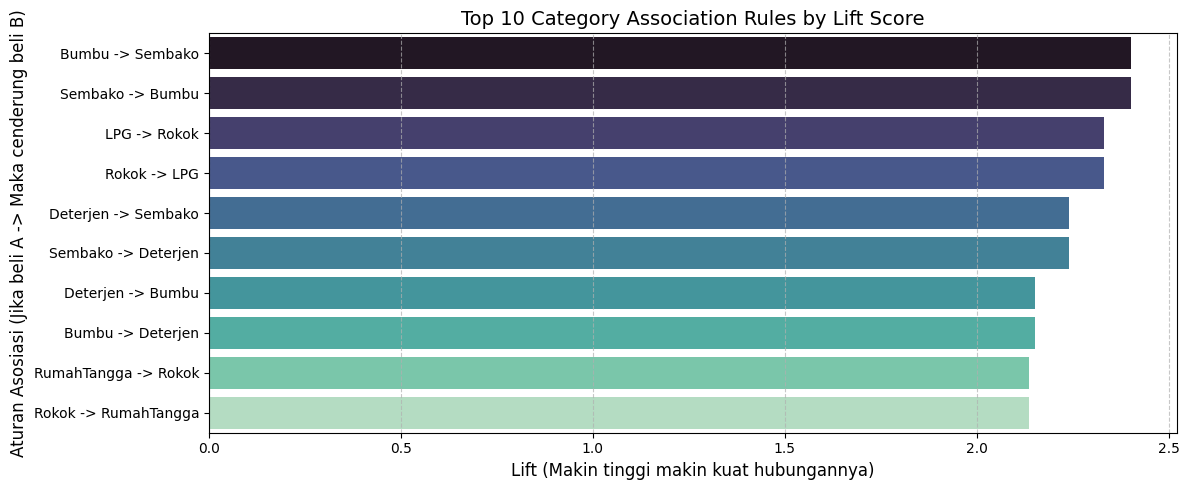

In [ ]:
# 2. Visualisasi Market Basket Analysis (Aturan Kategori)
df_basket_cat = pd.read_csv(os.path.join(output_dir, 'basket_rules_category.csv'))

print("\n=== TOP 10 ATURAN ASOSIASI KATEGORI (MARKET BASKET) ===")
display(df_basket_cat.head(10))

# Plot top category association rules
if not df_basket_cat.empty:
    plt.figure(figsize=(12, 5))
    df_basket_plot = df_basket_cat.head(10).copy()
    df_basket_plot['Rule'] = df_basket_plot['antecedents'] + ' -> ' + df_basket_plot['consequents']
    sns.barplot(x='lift', y='Rule', data=df_basket_plot, palette='mako', hue='Rule', legend=False)
    plt.title('Top 10 Category Association Rules by Lift Score', fontsize=14)
    plt.xlabel('Lift (Makin tinggi makin kuat hubungannya)', fontsize=12)
    plt.ylabel('Aturan Asosiasi (Jika beli A -> Maka cenderung beli B)', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


=== ELASTISITAS HARGA PER KATEGORI ===


,kategori,n_seri,n_observations,units,price_sd,elasticity,se,ci_low,ci_high,p_value,reliable
0,Snack,76,38380,108313.0,0.015604,-1.232180,0.274654,-1.770502,-0.693859,7.246835e-06,True
1,Minuman,76,38380,159332.0,0.017734,-0.978406,0.195733,-1.362042,-0.594770,5.772312e-07,True
2,Sembako,76,38380,42806.0,0.073745,-0.968127,0.076635,-1.118331,-0.817923,0.000000e+00,True
3,Mi,52,26260,82818.0,0.016403,-0.949008,0.274211,-1.486462,-0.411555,5.384331e-04,True
4,Rokok,52,26260,46160.0,0.034377,-0.800935,0.156423,-1.107525,-0.494345,3.050456e-07,True
5,Sachet,52,26260,111245.0,0.020436,-0.660817,0.181933,-1.017405,-0.304229,2.810047e-04,True
6,Deterjen,59,29795,24303.0,0.015616,-0.197253,0.573895,-1.322087,0.927581,7.310648e-01,False
7,Perawatan,66,33330,21746.0,0.016600,-0.125734,0.549080,-1.201931,0.950464,8.188771e-01,False
8,LPG,36,18180,6412.0,0.028335,-0.062508,0.421900,-0.889432,0.764416,8.822180e-01,False
9,Frozen,35,17675,15999.0,0.013440,0.065881,0.664504,-1.236548,1.368309,9.210249e-01,False


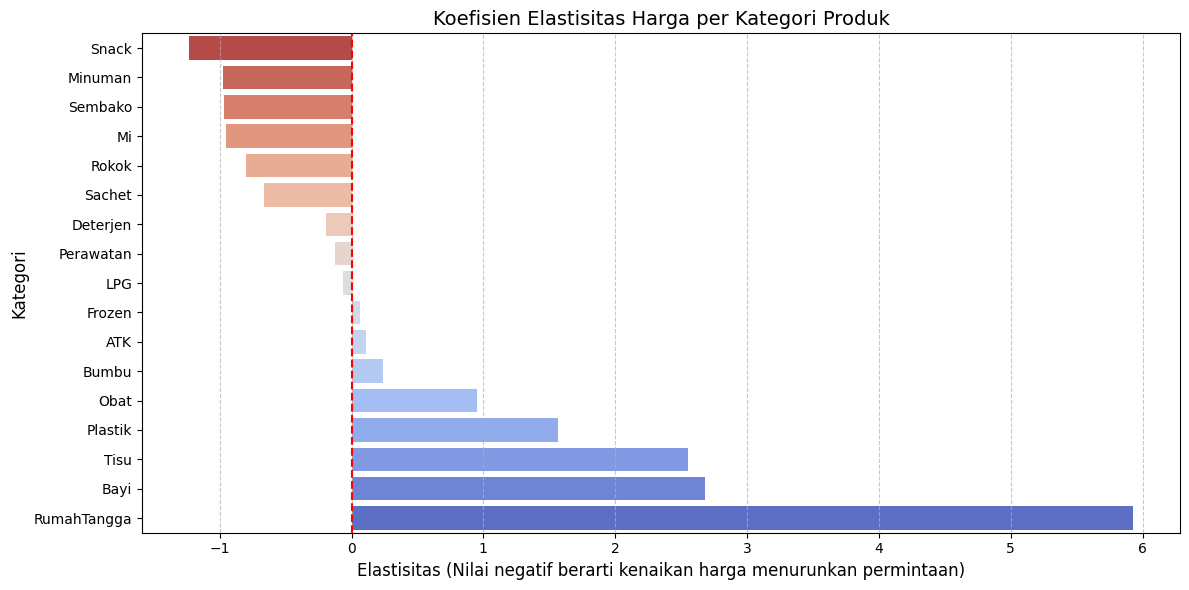

In [ ]:
# 3. Visualisasi Elastisitas Harga Kategori
df_elast_cat = pd.read_csv(os.path.join(output_dir, 'elasticity_category.csv'))

print("\n=== ELASTISITAS HARGA PER KATEGORI ===")
display(df_elast_cat)

# Plot elastisitas
plt.figure(figsize=(12, 6))
sns.barplot(x='elasticity', y='kategori', data=df_elast_cat.sort_values('elasticity'),
            palette='coolwarm_r', hue='kategori', legend=False)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Koefisien Elastisitas Harga per Kategori Produk', fontsize=14)
plt.xlabel('Elastisitas (Nilai negatif berarti kenaikan harga menurunkan permintaan)', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


=== TOTAL DETEKSI ANOMALI: 4242 KEJADIAN ===


,tanggal,warung_id,produk,kategori,jumlah,demand,harga_jual,harga_beli,z_qty,price_chg_1,margin_pct,anomaly_type,anomaly_score
0,2026-02-08,W1,Amplop,ATK,3.0,3.0,1100.0,750.0,5.642857,0.100000,0.318182,POLA_TIDAK_BIASA,-0.132338
1,2025-09-07,W2,Tepung beras Rose Brand 500g,Sembako,4.0,4.0,9700.0,8900.0,3.968627,0.102273,0.082474,POLA_TIDAK_BIASA,-0.120933
2,2026-04-09,W1,Amplop,ATK,3.0,3.0,1100.0,750.0,3.388096,0.100000,0.318182,POLA_TIDAK_BIASA,-0.120209
3,2026-02-23,W6,Amplop,ATK,1.0,1.0,1100.0,700.0,2.000000,0.100000,0.363636,POLA_TIDAK_BIASA,-0.117831
4,2026-01-18,W6,Aluminium foil,Plastik,3.0,4.0,10500.0,7479.0,6.527166,0.071429,0.287714,POLA_TIDAK_BIASA,-0.117114
5,2025-09-01,W4,Minyak goreng Fortune 1L,Sembako,5.0,5.0,23500.0,19232.0,3.957081,0.119048,0.181617,POLA_TIDAK_BIASA,-0.116356
6,2025-09-01,W1,Minyak goreng Bimoli 1L,Sembako,5.0,5.0,25500.0,21071.0,4.447428,0.108696,0.173686,LONJAKAN_PENJUALAN,-0.116345
7,2026-03-10,W1,Gula pasir Gulaku 1kg,Sembako,2.0,2.0,25000.0,20777.0,3.642857,0.111111,0.168920,POLA_TIDAK_BIASA,-0.112696
8,2026-04-25,W2,Beras premium 10kg,Sembako,1.0,1.0,190500.0,133150.0,2.000000,0.110787,0.301050,POLA_TIDAK_BIASA,-0.112180
9,2025-09-01,W4,Gula pasir Gulaku 1kg,Sembako,5.0,5.0,22000.0,17764.0,3.616638,0.100000,0.192545,POLA_TIDAK_BIASA,-0.111687


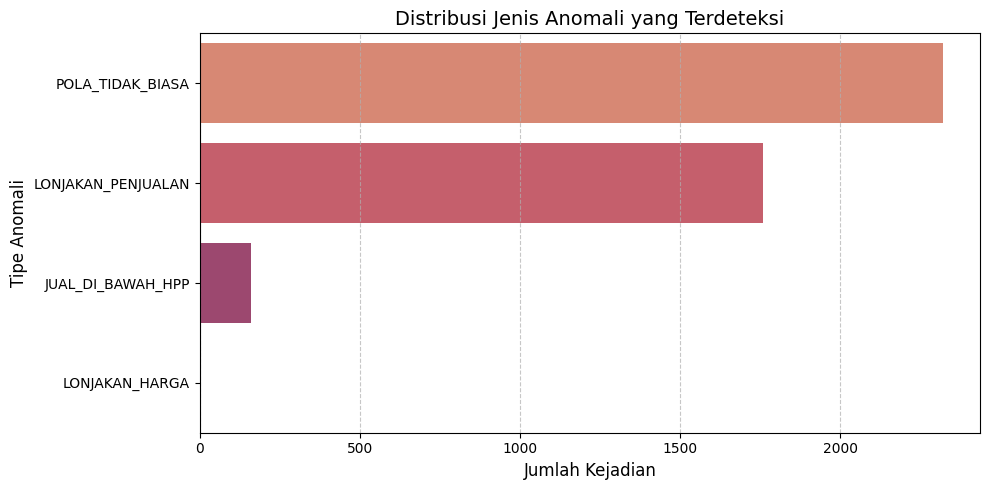

In [ ]:
# 4. Ringkasan & Visualisasi Anomali
df_anomalies = pd.read_csv(os.path.join(output_dir, 'anomalies.csv'))

print(f"\n=== TOTAL DETEKSI ANOMALI: {len(df_anomalies)} KEJADIAN ===")
display(df_anomalies.head(10))

if not df_anomalies.empty:
    plt.figure(figsize=(10, 5))
    anomaly_counts = df_anomalies['anomaly_type'].str.split(';').explode().value_counts()
    sns.barplot(x=anomaly_counts.values, y=anomaly_counts.index, palette='flare', hue=anomaly_counts.index, legend=False)
    plt.title('Distribusi Jenis Anomali yang Terdeteksi', fontsize=14)
    plt.xlabel('Jumlah Kejadian', fontsize=12)
    plt.ylabel('Tipe Anomali', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


=== TOP 15 ESTIMASI PRODUK PALING BANYAK DIMINTA (7 HARI KE DEPAN) ===


,warung_id,produk,kategori,pred_7d
0,W4,Mi goreng Indomie,Mi,80.976204
1,W5,Kopi Kapal Api sachet,Sachet,64.914350
2,W4,Kopi Kapal Api sachet,Sachet,58.977910
3,W1,Aqua 600ml,Minuman,54.717323
4,W2,Pocari Sweat 350ml,Minuman,41.427456
5,W5,Surya 16 batang,Rokok,39.527515
6,W2,Indomie Cup,Mi,39.210870
7,W2,Teh Botol Sosro 350ml,Minuman,38.733470
8,W2,Ultra Milk 250ml,Minuman,38.461815
9,W2,Beng-Beng,Snack,36.834557


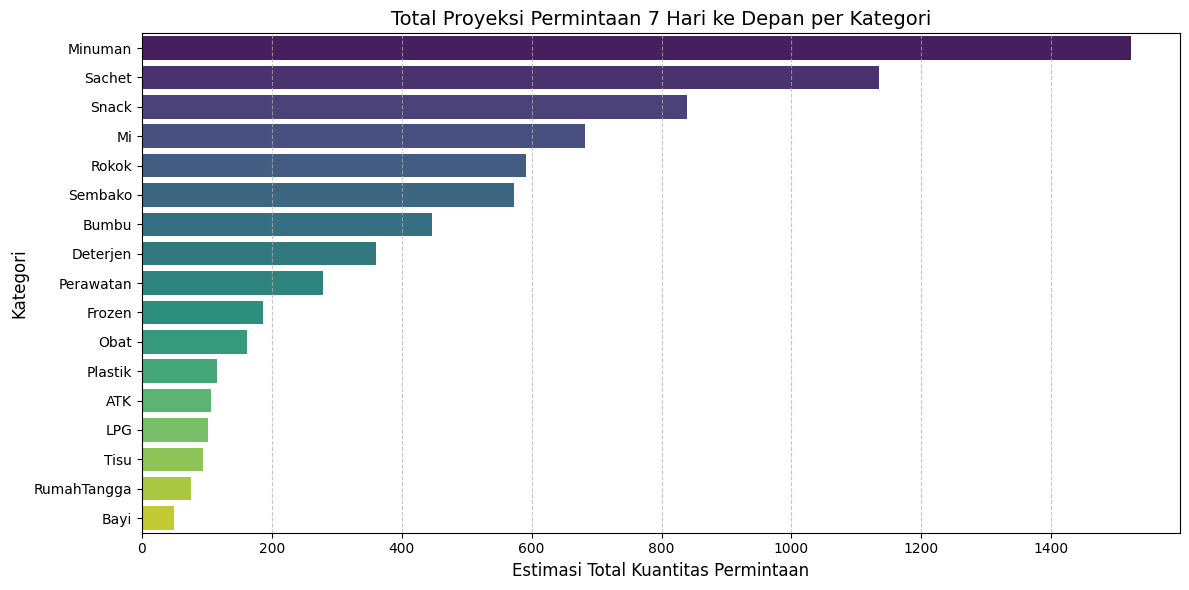

In [ ]:
# 5. Visualisasi Ringkasan Prediksi Permintaan Masa Depan (Next 7 Days)
df_fut_sum = pd.read_csv(os.path.join(output_dir, 'future_forecast_summary.csv'))

print("\n=== TOP 15 ESTIMASI PRODUK PALING BANYAK DIMINTA (7 HARI KE DEPAN) ===")
display(df_fut_sum.head(15))

# Agregasi top kategori untuk prediksi masa depan
plt.figure(figsize=(12, 6))
cat_fut = df_fut_sum.groupby('kategori')['pred_7d'].sum().reset_index().sort_values('pred_7d', ascending=False)
sns.barplot(x='pred_7d', y='kategori', data=cat_fut, palette='viridis', hue='kategori', legend=False)
plt.title('Total Proyeksi Permintaan 7 Hari ke Depan per Kategori', fontsize=14)
plt.xlabel('Estimasi Total Kuantitas Permintaan', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

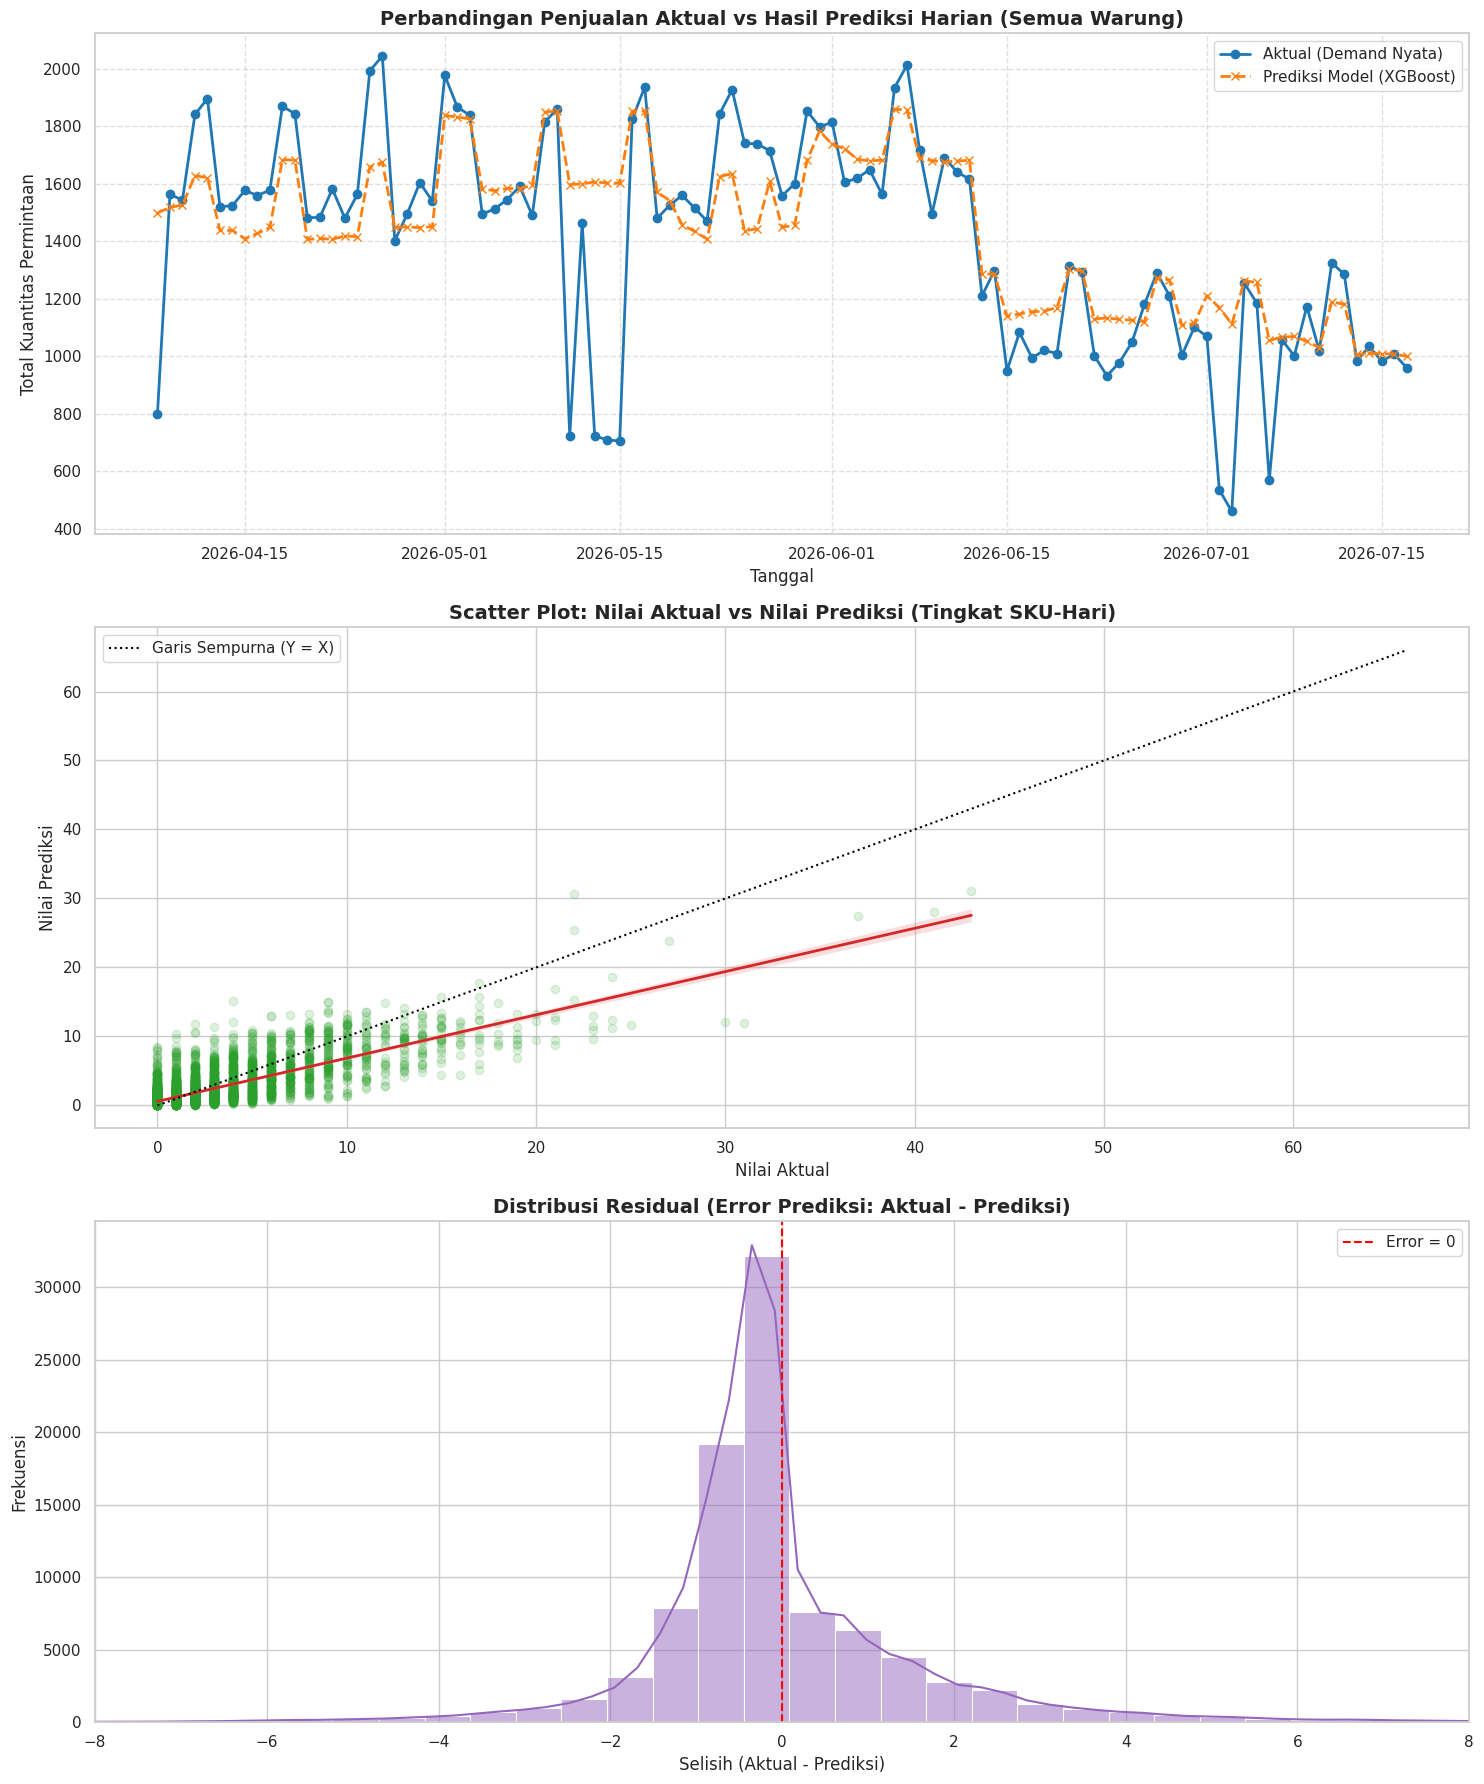

=== METRIK EVALUASI MODEL (DETIL TINGKAT SKU-HARI) ===
R-squared (R2)      : 0.6489 (Model menjelaskan 64.89% varians permintaan)
WAPE (Weighted APE) : 70.71% (Tingkat kesalahan rata-rata terbobot)
MAE (Mean Abs Error): 1.0523 unit
RMSE                : 1.7006 unit


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load forecast results on test set
forecast_df = pd.read_csv('outputs/forecasts.csv')
forecast_df['tanggal'] = pd.to_datetime(forecast_df['tanggal'])

# Group by date to see overall performance
daily_forecast = forecast_df.groupby('tanggal').agg(
    aktual=('jumlah', 'sum'),
    prediksi=('prediction', 'sum')
).reset_index()

# Setup plot style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# 1. Actual vs Predicted Time-Series
axes[0].plot(daily_forecast['tanggal'], daily_forecast['aktual'], label='Aktual (Demand Nyata)', color='#1f77b4', linewidth=2, marker='o')
axes[0].plot(daily_forecast['tanggal'], daily_forecast['prediksi'], label='Prediksi Model (XGBoost)', color='#ff7f0e', linewidth=2, linestyle='--', marker='x')
axes[0].set_title('Perbandingan Penjualan Aktual vs Hasil Prediksi Harian (Semua Warung)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tanggal', fontsize=12)
axes[0].set_ylabel('Total Kuantitas Permintaan', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Scatter Plot Actual vs Predicted
sns.regplot(ax=axes[1], x='jumlah', y='prediction', data=forecast_df.sample(min(10000, len(forecast_df)), random_state=42),
            scatter_kws={'alpha':0.15, 'color': '#2ca02c'}, line_kws={'color': '#d62728', 'linewidth': 2})
ideal_line = np.linspace(0, forecast_df['jumlah'].max(), 100)
axes[1].plot(ideal_line, ideal_line, color='black', linestyle=':', label='Garis Sempurna (Y = X)')
axes[1].set_title('Scatter Plot: Nilai Aktual vs Nilai Prediksi (Tingkat SKU-Hari)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nilai Aktual', fontsize=12)
axes[1].set_ylabel('Nilai Prediksi', fontsize=12)
axes[1].legend(fontsize=11)

# 3. Residual Distribution
residuals = forecast_df['jumlah'] - forecast_df['prediction']
sns.histplot(ax=axes[2], x=residuals, bins=100, kde=True, color='#9467bd')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Error = 0')
axes[2].set_title('Distribusi Residual (Error Prediksi: Aktual - Prediksi)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Selisih (Aktual - Prediksi)', fontsize=12)
axes[2].set_ylabel('Frekuensi', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].set_xlim(-8, 8)  # Batasi x-limit agar grafik lebih fokus pada rentang error dominan

plt.tight_layout()
plt.show()

# Print Summary Metrics manually calculated
mae = np.abs(residuals).mean()
rmse = np.sqrt((residuals ** 2).mean())
mape = 100 * (np.abs(residuals).sum() / forecast_df['jumlah'].sum())
r2 = 1 - (residuals ** 2).sum() / ((forecast_df['jumlah'] - forecast_df['jumlah'].mean()) ** 2).sum()

print("=== METRIK EVALUASI MODEL (DETIL TINGKAT SKU-HARI) ===")
print(f"R-squared (R2)      : {r2:.4f} (Model menjelaskan {r2*100:.2f}% varians permintaan)")
print(f"WAPE (Weighted APE) : {mape:.2f}% (Tingkat kesalahan rata-rata terbobot)")
print(f"MAE (Mean Abs Error): {mae:.4f} unit")
print(f"RMSE                : {rmse:.4f} unit")

CROSS-WARUNG INTELLIGENCE

--- PEER TERDEKAT TIAP WARUNG ---
W1 [Campuran kos-perumahan] -> W5 (0.97), W2 (0.88)
W2 [Dekat kampus] -> W4 (0.94), W1 (0.88)
W3 [Perumahan] -> W6 (0.99), W5 (0.88)
W4 [Kos padat] -> W2 (0.94), W1 (0.70)
W5 [Pinggir jalan (pekerja/ojol)] -> W1 (0.97), W3 (0.88)
W6 [Dekat pasar (ibu-ibu)] -> W3 (0.99), W5 (0.82)

--- BENCHMARK vs PEER (rasio > 1 = lebih baik) ---


,omzet_per_hari_vs_peer,margin_vs_peer,stockout_rate_vs_peer,basket_size_vs_peer
warung_id,,,,
W1,0.81,1.06,0.46,1.01
W2,1.38,0.81,1.30,1.00
W3,0.90,1.30,0.77,0.99
W4,0.91,1.32,2.00,1.03
W5,1.09,0.92,0.90,0.99
W6,0.98,0.71,0.92,1.01



--- TOP 5 GAP PRODUK PER WARUNG (belum distok, tapi laku di peer) ---

[W1]


,produk,kategori,estimasi_omzet_harian
84,Surya 16 batang,Rokok,103786.0
19,Esse 16 batang,Rokok,73363.0
22,Gudang Garam Filter 12 batang,Rokok,64616.0
68,Pocari Sweat 350ml,Minuman,44920.0
16,Djarum Super 12 batang,Rokok,44644.0



[W2]


...


--- DIAGNOSIS ANOMALI LINTAS-WARUNG (7 hari terakhir) ---


,growth_7hari,growth_peer,selisih,diagnosis
warung_id,,,,
W1,0.035,0.060,-0.025,NORMAL
W2,0.079,0.045,0.034,NORMAL
W3,0.058,0.022,0.035,NORMAL
W4,0.055,0.057,-0.002,TREN_PASAR_NAIK
W5,0.040,0.046,-0.006,NORMAL
W6,0.005,0.049,-0.044,NORMAL



--- WARUNG HEALTH SCORE ---


,skor_total,omzet,margin,stockout,basket
warung_id,,,,,
W3,61,40,79,79,49
W1,57,30,55,100,51
W5,53,58,42,61,48
W2,52,87,30,26,49
W6,44,48,21,58,51
W4,42,40,82,0,52



CONTOH INSIGHT NARATIF untuk W2
Skor kesehatan: 52/100
Tren 7 hari: +7.9% (peer +4.5%) -> NORMAL

Pertimbangkan menambah produk (laku di warung serupa):
  - Mi goreng Indomie (Mi) potensi ~Rp46,170/hari
  - Nescafe 220ml (Minuman) potensi ~Rp37,880/hari
  - Surya 12 batang (Rokok) potensi ~Rp33,475/hari

Stok yang perlu ditambah:
  - Minyak kayu putih Cap Lang 30ml (Obat): sisa 0.0 hari, target 2 (tambah 2)
  - Pembalut Laurier: sisa 0.0 hari, target 1 (tambah 1)
  - Plastik kresek kecil: sisa 0.0 hari, target 2 (tambah 2)


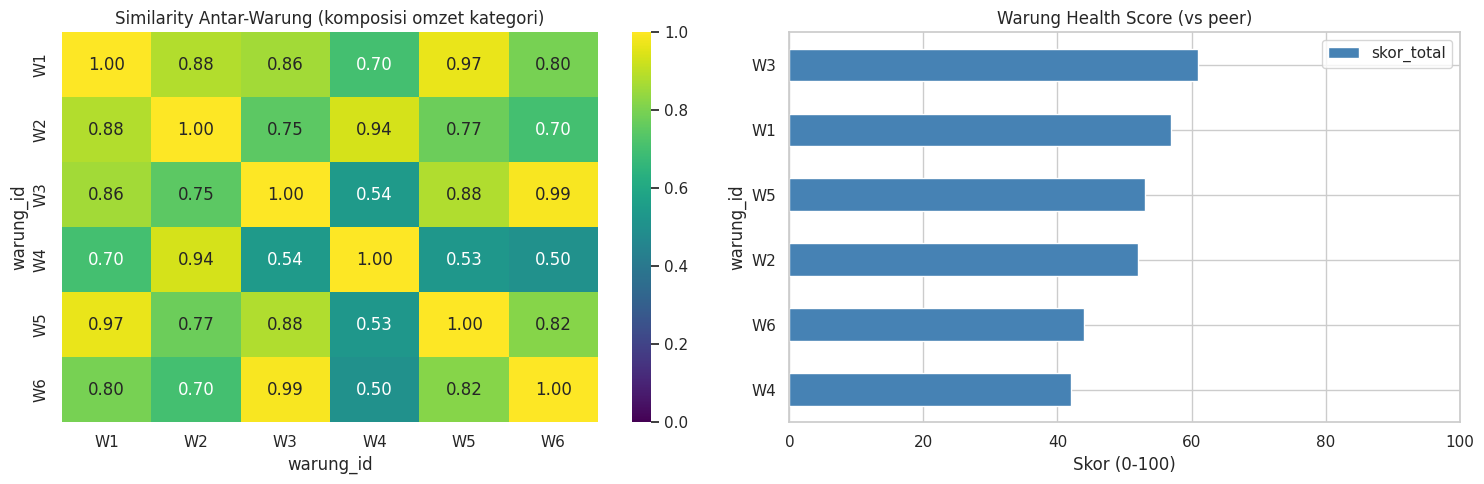


Semua artefak tersimpan di: outputs/cross_warung/


In [ ]:
# ============================================================
# MODUL INSIGHT LINTAS-WARUNG (Cross-Warung Intelligence)
# ============================================================
# Kelanjutan pipeline: memanfaatkan data SEMUA warung untuk
# memberi insight ke tiap pedagang — sesuatu yang tidak bisa
# dilakukan jika tiap warung hanya melihat datanya sendiri.
#
# Yang dibangun di cell ini:
#   1. Peer similarity  : siapa "warung tetangga/pembanding" saya?
#   2. Benchmark KPI    : kinerja saya vs warung serupa & jaringan
#   3. Gap produk       : barang apa yang laku di peer tapi belum saya stok
#   4. Rekomendasi stok : stok target berbasis peer (bukan cuma data sendiri)
#   5. Jam buka         : jam ramai di peer yang belum saya manfaatkan
#   6. Anomali lintas   : penurunan saya = masalah saya atau tren pasar?
#   7. Health score     : skor kesehatan warung 0-100
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import json, os

sns.set_theme(style="whitegrid")
CROSS_OUT = "outputs/cross_warung"
os.makedirs(CROSS_OUT, exist_ok=True)
N_PEERS = 2  # jumlah peer terdekat untuk perbandingan

# ---- pastikan data tersedia (fallback load dari CSV) ----
try: df_penjualan
except NameError: df_penjualan = pd.read_csv("data_simulasi/penjualan.csv")
try: df_warung
except NameError: df_warung = pd.read_csv("data_simulasi/warung.csv")
try: df_stockout
except NameError:
    try: df_stockout = pd.read_csv("data_simulasi/stockout.csv")
    except FileNotFoundError: df_stockout = None

df_penjualan = df_penjualan.copy()
df_penjualan["tanggal"] = pd.to_datetime(df_penjualan["tanggal"])
if "total_harga" not in df_penjualan.columns:
    df_penjualan["total_harga"] = df_penjualan["jumlah"] * df_penjualan["harga_jual"]
df_penjualan["jam_int"] = pd.to_numeric(
    df_penjualan["jam"].astype(str).str[:2], errors="coerce")


# ------------------------------------------------------------
# 1. PEER SIMILARITY  (siapa pembanding yang paling mirip?)
# ------------------------------------------------------------
def build_similarity(df_penjualan):
    """Similarity antar-warung berbasis komposisi omzet per kategori."""
    pivot = df_penjualan.pivot_table(
        index="warung_id", columns="kategori",
        values="total_harga", aggfunc="sum", fill_value=0)
    share = pivot.div(pivot.sum(axis=1), axis=0)          # profil omzet (share)
    sim = pd.DataFrame(cosine_similarity(share.values),
                       index=share.index, columns=share.index)
    return sim

def get_peers(wid, sim, k=N_PEERS):
    """K warung paling mirip (tidak termasuk diri sendiri)."""
    return sim.loc[wid].drop(wid).sort_values(ascending=False).head(k)


# ------------------------------------------------------------
# 2. BENCHMARK KPI
# ------------------------------------------------------------
def warung_kpi(df_penjualan, df_warung, df_stockout):
    rows = []
    for _, w in df_warung.iterrows():
        wid = w["warung_id"]
        pj  = df_penjualan[df_penjualan["warung_id"] == wid]
        so  = df_stockout[df_stockout["warung_id"] == wid] if df_stockout is not None else pd.DataFrame()

        omzet   = pj["total_harga"].sum()
        n_hari  = pj["tanggal"].nunique()
        n_trx   = pj["trx_id"].nunique()
        cogs    = (pj["jumlah"] * pj["harga_beli"]).sum()
        margin  = (omzet - cogs) / omzet if omzet > 0 else 0
        terjual = pj["jumlah"].sum()
        hilang  = so["jumlah_hilang"].sum() if len(so) else 0
        demand  = terjual + hilang
        so_rate = hilang / demand if demand > 0 else 0

        rows.append({
            "warung_id": wid, "nama": w["nama"],
            "omzet_per_hari": omzet / max(n_hari, 1),
            "trx_per_hari": n_trx / max(n_hari, 1),
            "basket_size": terjual / max(n_trx, 1),
            "margin": margin,
            "stockout_rate": so_rate,
            "sku_aktif": pj["produk"].nunique(),
            "n_hari": n_hari,
        })
    return pd.DataFrame(rows).set_index("warung_id")

def benchmark_report(kpi, sim):
    """Bandingkan tiap warung dengan peer terdekat & median jaringan."""
    out = []
    for wid in kpi.index:
        peers = get_peers(wid, sim).index
        peer_med = kpi.loc[peers].median(numeric_only=True)
        net_med  = kpi.drop(wid).median(numeric_only=True)
        row = {"warung_id": wid, "peer": list(peers)}
        for m in ["omzet_per_hari", "margin", "stockout_rate", "basket_size"]:
            row[f"{m}_vs_peer"] = (kpi.at[wid, m] / peer_med[m]) if peer_med[m] else np.nan
            row[f"{m}_vs_jaringan"] = (kpi.at[wid, m] / net_med[m]) if net_med[m] else np.nan
        out.append(row)
    return pd.DataFrame(out).set_index("warung_id")


# ------------------------------------------------------------
# 3. GAP PRODUK  (barang peer yang belum saya jual)
# ------------------------------------------------------------
def product_gap(df_penjualan, sim, min_omzet_peer=100_000):
    """Produk yang laku di peer tapi belum distok warung ini."""
    hasil = []
    omz = df_penjualan.groupby(["warung_id", "produk"]).agg(
        omzet=("total_harga", "sum"), qty=("jumlah", "sum"),
        kategori=("kategori", "first")).reset_index()

    for wid in df_penjualan["warung_id"].unique():
        punya_saya = set(df_penjualan.loc[df_penjualan["warung_id"] == wid, "produk"])
        peers = get_peers(wid, sim).index
        kandidat = omz[omz["warung_id"].isin(peers)]

        for prod, g in kandidat.groupby("produk"):
            if prod in punya_saya:
                continue
            omzet_peer = g["omzet"].sum()
            if omzet_peer < min_omzet_peer:
                continue
            # estimasi potensi: rata-rata omzet peer per warung
            hasil.append({
                "warung_id": wid, "produk": prod,
                "kategori": g["kategori"].iloc[0],
                "omzet_peer_total": omzet_peer,
                "estimasi_omzet_harian": omzet_peer / len(peers) / df_penjualan["tanggal"].nunique(),
                "qty_peer_total": int(g["qty"].sum()),
            })
    gap = pd.DataFrame(hasil)
    if len(gap):
        gap = gap.sort_values(["warung_id", "estimasi_omzet_harian"],
                              ascending=[True, False])
    return gap


# ------------------------------------------------------------
# 4. REKOMENDASI STOK PEER-BASED
# ------------------------------------------------------------
def stock_recommendation(df_penjualan, sim, target_days=7):
    """
    Bandingkan 'hari stok' warung vs peer untuk produk yang sama.
    Jika warung pegang stok lebih tipis dari peer padahal laku, naikkan.
    """
    hasil = []
    for wid in df_penjualan["warung_id"].unique():
        pj_saya  = df_penjualan[df_penjualan["warung_id"] == wid]
        peers    = get_peers(wid, sim).index
        pj_peer  = df_penjualan[df_penjualan["warung_id"].isin(peers)]
        n_hari   = pj_saya["tanggal"].nunique()

        stok_terakhir = (pj_saya.sort_values("tanggal")
                         .groupby("produk")["stok_akhir"].last())

        for prod in pj_saya["produk"].unique():
            d_saya = pj_saya.loc[pj_saya["produk"] == prod, "jumlah"].sum() / max(n_hari, 1)
            d_peer = pj_peer.loc[pj_peer["produk"] == prod, "jumlah"].sum() / max(n_hari, 1) / max(len(peers), 1)
            if d_peer <= 0:
                continue
            stok = float(stok_terakhir.get(prod, 0))
            hari_stok_saya = stok / d_saya if d_saya > 0 else np.inf
            hari_stok_peer = (stok / d_peer) if d_peer > 0 else np.inf
            target = np.ceil(d_peer * target_days)
            if hari_stok_peer < 3 and d_saya >= d_peer * 0.7:
                # stok menipis relatif terhadap laju permintaan peer
                hasil.append({
                    "warung_id": wid, "produk": prod,
                    "stok_sekarang": int(stok),
                    "laju_jual_saya": round(d_saya, 2),
                    "laju_jual_peer": round(d_peer, 2),
                    "hari_stok_sisa": round(min(hari_stok_saya, 999), 1),
                    "stok_target_disarankan": int(target),
                    "saran_tambah": int(max(0, target - stok)),
                })
    rec = pd.DataFrame(hasil)
    if len(rec):
        rec = rec.sort_values(["warung_id", "hari_stok_sisa"])
    return rec


# ------------------------------------------------------------
# 5. REKOMENDASI JAM BUKA
# ------------------------------------------------------------
def operating_hours(df_penjualan, sim):
    """Cari jam ramai di peer yang tidak tercakup oleh warung ini."""
    pola = (df_penjualan.groupby(["warung_id", "jam_int"])["total_harga"]
            .sum().reset_index())
    hasil = []
    for wid in df_penjualan["warung_id"].unique():
        peers = get_peers(wid, sim).index
        jam_saya = set(pola.loc[pola["warung_id"] == wid, "jam_int"])
        peer_pola = pola[pola["warung_id"].isin(peers)]
        total_peer = peer_pola["total_harga"].sum()
        for jam, g in peer_pola.groupby("jam_int"):
            share = g["total_harga"].sum() / total_peer if total_peer else 0
            status = "TERBUKA" if jam in jam_saya else "TUTUP"
            hasil.append({"warung_id": wid, "jam": int(jam),
                          "share_omzet_peer": share, "status_saya": status})
    jam_df = pd.DataFrame(hasil)

    # ringkas peluang yang hilang
    missed = jam_df[(jam_df["status_saya"] == "TUTUP") &
                    (jam_df["share_omzet_peer"] >= 0.05)]
    missed = missed.sort_values(["warung_id", "share_omzet_peer"],
                                ascending=[True, False])
    return jam_df, missed


# ------------------------------------------------------------
# 6. ANOMALI LINTAS-WARUNG (spesifik vs tren pasar)
# ------------------------------------------------------------
def cross_warung_anomaly(df_penjualan, sim, window=7):
    """Jika warung turun tapi peer naik -> kemungkinan masalah internal."""
    daily = (df_penjualan.groupby(["warung_id", "tanggal"])["total_harga"]
             .sum().reset_index())
    last = daily["tanggal"].max()
    rec  = daily[daily["tanggal"] > last - pd.Timedelta(days=window)]
    prev = daily[(daily["tanggal"] <= last - pd.Timedelta(days=window)) &
                 (daily["tanggal"] > last - pd.Timedelta(days=2 * window))]
    g_rec  = rec.groupby("warung_id")["total_harga"].sum()
    g_prev = prev.groupby("warung_id")["total_harga"].sum()
    growth = ((g_rec - g_prev) / g_prev.replace(0, np.nan)).dropna()

    hasil = []
    for wid in growth.index:
        peers = get_peers(wid, sim).index
        peer_growth = growth.reindex(peers).mean()
        delta = growth[wid] - peer_growth
        if growth[wid] < -0.05 and peer_growth > 0:
            jenis = "MASALAH_SPESIFIK_WARUNG"
        elif growth[wid] < -0.05 and peer_growth < -0.05:
            jenis = "TREN_PASAR_MENURUN"
        elif growth[wid] > 0.05 and peer_growth > 0.05:
            jenis = "TREN_PASAR_NAIK"
        elif growth[wid] > 0.05 and peer_growth <= 0:
            jenis = "KINERJA_BAIK_SPESIFIK"
        else:
            jenis = "NORMAL"
        hasil.append({"warung_id": wid,
                      "growth_7hari": round(growth[wid], 3),
                      "growth_peer": round(peer_growth, 3),
                      "selisih": round(delta, 3),
                      "diagnosis": jenis})
    return pd.DataFrame(hasil).set_index("warung_id")


# ------------------------------------------------------------
# 7. WARUNG HEALTH SCORE (0-100)
# ------------------------------------------------------------
def ratio_score(nilai, ref, arah=1):
    """Map rasio nilai/referensi ke skor 0-100 (rasio 1.0 -> 50)."""
    if ref is None or ref == 0 or pd.isna(ref):
        return 50
    r = nilai / ref
    if arah == -1:
        r = 1 / r if r > 0 else 2.0
    return int(np.clip((r - 0.5) * 100, 0, 100))

def health_score(kpi, sim):
    rows = []
    for wid in kpi.index:
        peers = get_peers(wid, sim).index
        pm = kpi.loc[peers].median(numeric_only=True)
        skor = {
            "omzet":       ratio_score(kpi.at[wid, "omzet_per_hari"], pm["omzet_per_hari"]),
            "margin":      ratio_score(kpi.at[wid, "margin"], pm["margin"]),
            "stockout":    ratio_score(kpi.at[wid, "stockout_rate"], pm["stockout_rate"], arah=-1),
            "basket":      ratio_score(kpi.at[wid, "basket_size"], pm["basket_size"]),
        }
        bobot = {"omzet": 0.35, "margin": 0.25, "stockout": 0.25, "basket": 0.15}
        total = sum(skor[k] * w for k, w in bobot.items())
        rows.append({"warung_id": wid, "skor_total": int(round(total)), **skor})
    return pd.DataFrame(rows).set_index("warung_id")


# ============================================================
# JALANKAN SEMUA & BUAT LAPORAN
# ============================================================
print("=" * 70)
print("CROSS-WARUNG INTELLIGENCE")
print("=" * 70)

sim = build_similarity(df_penjualan)
kpi = warung_kpi(df_penjualan, df_warung, df_stockout)
bench = benchmark_report(kpi, sim)
gap = product_gap(df_penjualan, sim)
stok_rec = stock_recommendation(df_penjualan, sim)
jam_df, jam_missed = operating_hours(df_penjualan, sim)
anomali = cross_warung_anomaly(df_penjualan, sim)
health = health_score(kpi, sim)

# ---- simpan artefak ----
sim.to_csv(f"{CROSS_OUT}/peer_similarity.csv")
kpi.to_csv(f"{CROSS_OUT}/warung_kpi.csv")
bench.to_csv(f"{CROSS_OUT}/benchmark.csv")
gap.to_csv(f"{CROSS_OUT}/product_gap.csv", index=False)
stok_rec.to_csv(f"{CROSS_OUT}/stock_recommendation.csv", index=False)
jam_missed.to_csv(f"{CROSS_OUT}/operating_hours_opportunity.csv", index=False)
anomali.to_csv(f"{CROSS_OUT}/cross_anomaly.csv")
health.to_csv(f"{CROSS_OUT}/health_score.csv")

# ---- cetak ringkasan ----
print("\n--- PEER TERDEKAT TIAP WARUNG ---")
for wid in sim.index:
    p = get_peers(wid, sim)
    nama = df_warung.set_index("warung_id").loc[wid, "nama"]
    peer_str = ", ".join(f"{k} ({v:.2f})" for k, v in p.items())
    print(f"{wid} [{nama}] -> {peer_str}")

print("\n--- BENCHMARK vs PEER (rasio > 1 = lebih baik) ---")
display(bench[[c for c in bench.columns if c.endswith("_vs_peer")]].round(2))

print("\n--- TOP 5 GAP PRODUK PER WARUNG (belum distok, tapi laku di peer) ---")
for wid in gap["warung_id"].unique():
    top = gap[gap["warung_id"] == wid].head(5)
    print(f"\n[{wid}]")
    display(top[["produk", "kategori", "estimasi_omzet_harian"]]
            .assign(estimasi_omzet_harian=lambda d: d["estimasi_omzet_harian"].round(0)))

print("\n--- REKOMENDASI STOK (stok menipis vs laju peer) ---")
display(stok_rec.head(15))

print("\n--- PELUANG JAM BUKA (jam ramai peer tapi warung tutup) ---")
display(jam_missed.head(10))

print("\n--- DIAGNOSIS ANOMALI LINTAS-WARUNG (7 hari terakhir) ---")
display(anomali)

print("\n--- WARUNG HEALTH SCORE ---")
display(health.sort_values("skor_total", ascending=False))

# ---- insight naratif contoh (satu warung) ----
contoh = kpi.index[1]  # warung kedua
print(f"\n{'=' * 70}\nCONTOH INSIGHT NARATIF untuk {contoh}\n{'=' * 70}")
g = gap[gap["warung_id"] == contoh].head(3)
s = stok_rec[stok_rec["warung_id"] == contoh].head(3)
j = jam_missed[jam_missed["warung_id"] == contoh].head(2)
a = anomali.loc[contoh] if contoh in anomali.index else None
h = health.loc[contoh]
print(f"Skor kesehatan: {h['skor_total']}/100")
if a is not None:
    print(f"Tren 7 hari: {a['growth_7hari']:+.1%} "
          f"(peer {a['growth_peer']:+.1%}) -> {a['diagnosis']}")
if len(g):
    print("\nPertimbangkan menambah produk (laku di warung serupa):")
    for _, r in g.iterrows():
        print(f"  - {r['produk']} ({r['kategori']}) "
              f"potensi ~Rp{r['estimasi_omzet_harian']:,.0f}/hari")
if len(s):
    print("\nStok yang perlu ditambah:")
    for _, r in s.iterrows():
        print(f"  - {r['produk']}: sisa {r['hari_stok_sisa']} hari, "
              f"target {r['stok_target_disarankan']} "
              f"(tambah {r['saran_tambah']})")
if len(j):
    print("\nPeluang jam operasional:")
    for _, r in j.iterrows():
        print(f"  - Jam {r['jam']}: peer catat {r['share_omzet_peer']:.1%} "
              f"omzet, warung Anda tutup")

# ---- visualisasi ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(sim, annot=True, fmt=".2f", cmap="viridis",
            ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("Similarity Antar-Warung (komposisi omzet kategori)")

health.sort_values("skor_total").plot.barh(
    y="skor_total", ax=axes[1], color="steelblue")
axes[1].set_xlim(0, 100)
axes[1].set_title("Warung Health Score (vs peer)")
axes[1].set_xlabel("Skor (0-100)")

plt.tight_layout()
plt.show()

print(f"\nSemua artefak tersimpan di: {CROSS_OUT}/")

PILAR 5: KOLABORASI & KOMPLEMENTARITAS ANTAR-WARUNG

Data: 508,156 baris penjualan | 6 warung | 271 produk
Stockout tersedia: True | Kalender tersedia: True

1. WARUNG SIMILARITY & PEER GROUPING

Similarity Matrix (berbasis komposisi kategori):
       W1     W2     W3     W4     W5     W6
W1  1.000  0.884  0.862  0.702  0.967  0.796
W2  0.884  1.000  0.747  0.936  0.774  0.702
W3  0.862  0.747  1.000  0.539  0.881  0.990
W4  0.702  0.936  0.539  1.000  0.530  0.504
W5  0.967  0.774  0.881  0.530  1.000  0.820
W6  0.796  0.702  0.990  0.504  0.820  1.000

Peer Terdekat tiap Warung:
  W1 [Campuran kos-perumahan] → W5 (Pinggir jalan (pekerja/ojol)), W2 (Dekat kampus)
  W2 [Dekat kampus] → W4 (Kos padat), W1 (Campuran kos-perumahan)
  W3 [Perumahan] → W6 (Dekat pasar (ibu-ibu)), W5 (Pinggir jalan (pekerja/ojol))
  W4 [Kos padat] → W2 (Dekat kampus), W1 (Campuran kos-perumahan)
  W5 [Pinggir jalan (pekerja/ojol)] → W1 (Campuran kos-perumahan), W3 (Perumahan)
  W6 [Dekat pasar (ibu-ibu)] → W

,warung_id,nama,omzet_per_hari,profit_per_hari,margin_pct,trx_per_hari,basket_size,stockout_rate
0,W1,Campuran kos-perumahan,1624861.0,222532.0,0.137,105.1,2.03,0.013
1,W2,Dekat kampus,2374388.0,298425.0,0.126,162.9,2.05,0.050
2,W3,Perumahan,1432501.0,219651.0,0.153,73.7,1.95,0.006
3,W4,Kos padat,1817891.0,315578.0,0.174,138.7,2.10,0.063
4,W5,Pinggir jalan (pekerja/ojol),1661582.0,222344.0,0.134,94.2,1.96,0.009
5,W6,Dekat pasar (ibu-ibu),1516845.0,155231.0,0.102,81.5,1.97,0.007



Benchmark vs Peer (rasio > 1 = lebih baik dari peer):


,warung_id,nama,omzet_per_hari_vs_peer,omzet_per_hari_vs_net,margin_pct_vs_peer,margin_pct_vs_net,trx_per_hari_vs_peer,trx_per_hari_vs_net,basket_size_vs_peer,basket_size_vs_net,stockout_rate_vs_peer,stockout_rate_vs_net
0,W1,Campuran kos-perumahan,0.805,0.978,1.056,1.023,0.818,1.116,1.011,1.028,2.170,0.649
1,W2,Dekat kampus,1.379,1.461,0.809,0.918,1.337,1.730,0.995,1.041,0.770,0.176
2,W3,Perumahan,0.901,0.862,1.299,1.146,0.839,0.701,0.991,0.960,1.293,2.247
3,W4,Kos padat,0.909,1.119,1.322,1.297,1.035,1.472,1.028,1.063,0.501,0.139
4,W5,Pinggir jalan (pekerja/ojol),1.087,1.023,0.922,0.977,1.053,0.896,0.985,0.966,1.113,1.540
5,W6,Dekat pasar (ibu-ibu),0.980,0.913,0.713,0.747,0.971,0.775,1.010,0.973,1.090,1.992



3. PRODUCT GAP ANALYSIS

Total 584 produk gap ditemukan.

Top 5 Produk Gap per Warung:

  [W1] Campuran kos-perumahan:
    • Surya 16 batang (Rokok) | Est. Rp103,786/hari | ~3.0 unit/hari
    • Esse 16 batang (Rokok) | Est. Rp73,363/hari | ~2.1 unit/hari
    • Gudang Garam Filter 12 batang (Rokok) | Est. Rp64,616/hari | ~2.7 unit/hari
    • Pocari Sweat 350ml (Minuman) | Est. Rp44,920/hari | ~6.3 unit/hari
    • Djarum Super 12 batang (Rokok) | Est. Rp44,644/hari | ~1.7 unit/hari

  [W2] Dekat kampus:
    • Mi goreng Indomie (Mi) | Est. Rp46,170/hari | ~12.5 unit/hari
    • Nescafe 220ml (Minuman) | Est. Rp37,880/hari | ~6.1 unit/hari
    • Surya 12 batang (Rokok) | Est. Rp33,475/hari | ~1.3 unit/hari
    • Kacang kulit Garuda 100g (Snack) | Est. Rp32,618/hari | ~4.5 unit/hari
    • LA Ice 16 batang (Rokok) | Est. Rp30,338/hari | ~0.9 unit/hari

  [W3] Perumahan:
    • Gudang Garam Filter 12 batang (Rokok) | Est. Rp43,081/hari | ~1.8 unit/hari
    • Beras premium 5kg (Sembako) | Est. 

,warung_id,growth_self,growth_peer,growth_network,delta_vs_peer,diagnosis,severity
0,W1,0.035,0.060,0.048,-0.024,NORMAL,LOW
1,W2,0.079,0.044,0.038,0.035,NORMAL,LOW
2,W3,0.058,0.023,0.043,0.034,NORMAL,LOW
3,W4,0.055,0.058,0.044,-0.003,TREN_PASAR_NAIK,INFO
4,W5,0.040,0.047,0.047,-0.007,NORMAL,LOW
5,W6,0.005,0.049,0.054,-0.044,NORMAL,LOW



7. WARUNG HEALTH SCORE (0-100)

Health Score per Warung:


,warung_id,nama,skor_total,omzet,margin,frekuensi,basket,stockout,grade
0,W2,Dekat kampus,58,88,31,84,50,27,C
1,W3,Perumahan,56,40,80,34,49,79,C
2,W5,Pinggir jalan (pekerja/ojol),54,59,42,55,49,61,C
3,W1,Campuran kos-perumahan,53,31,56,32,51,100,C
4,W4,Kos padat,45,41,82,53,53,0,C
5,W6,Dekat pasar (ibu-ibu),45,48,21,47,51,59,C



8. REFERRAL & COMPLEMENTARITY OPPORTUNITIES

Peluang Referral Stockout: 1515 pasangan ditemukan.

Top 10 Peluang Referral (berdasarkan jumlah hilang):
  [W4] Mi goreng Indomie hilang 1200 unit (797x) → bisa dirujuk ke [W1]
  [W4] Mi goreng Indomie hilang 1200 unit (797x) → bisa dirujuk ke [W5]
  [W2] Kratingdaeng 150ml hilang 465 unit (309x) → bisa dirujuk ke [W3]
  [W2] Kratingdaeng 150ml hilang 465 unit (309x) → bisa dirujuk ke [W4]
  [W2] Kratingdaeng 150ml hilang 465 unit (309x) → bisa dirujuk ke [W6]
  [W2] Teh Pucuk 350ml hilang 416 unit (286x) → bisa dirujuk ke [W1]
  [W2] Teh Pucuk 350ml hilang 416 unit (286x) → bisa dirujuk ke [W5]
  [W2] Teh Pucuk 350ml hilang 416 unit (286x) → bisa dirujuk ke [W3]
  [W4] Ultra Milk 250ml hilang 406 unit (278x) → bisa dirujuk ke [W3]
  [W4] Ultra Milk 250ml hilang 406 unit (278x) → bisa dirujuk ke [W2]

Peluang Bundle Komplementer: 30 pasangan kategori.

Top Co-occurrence per Warung:

  [W1] Campuran kos-perumahan:
    • Minuman + Snack (co-

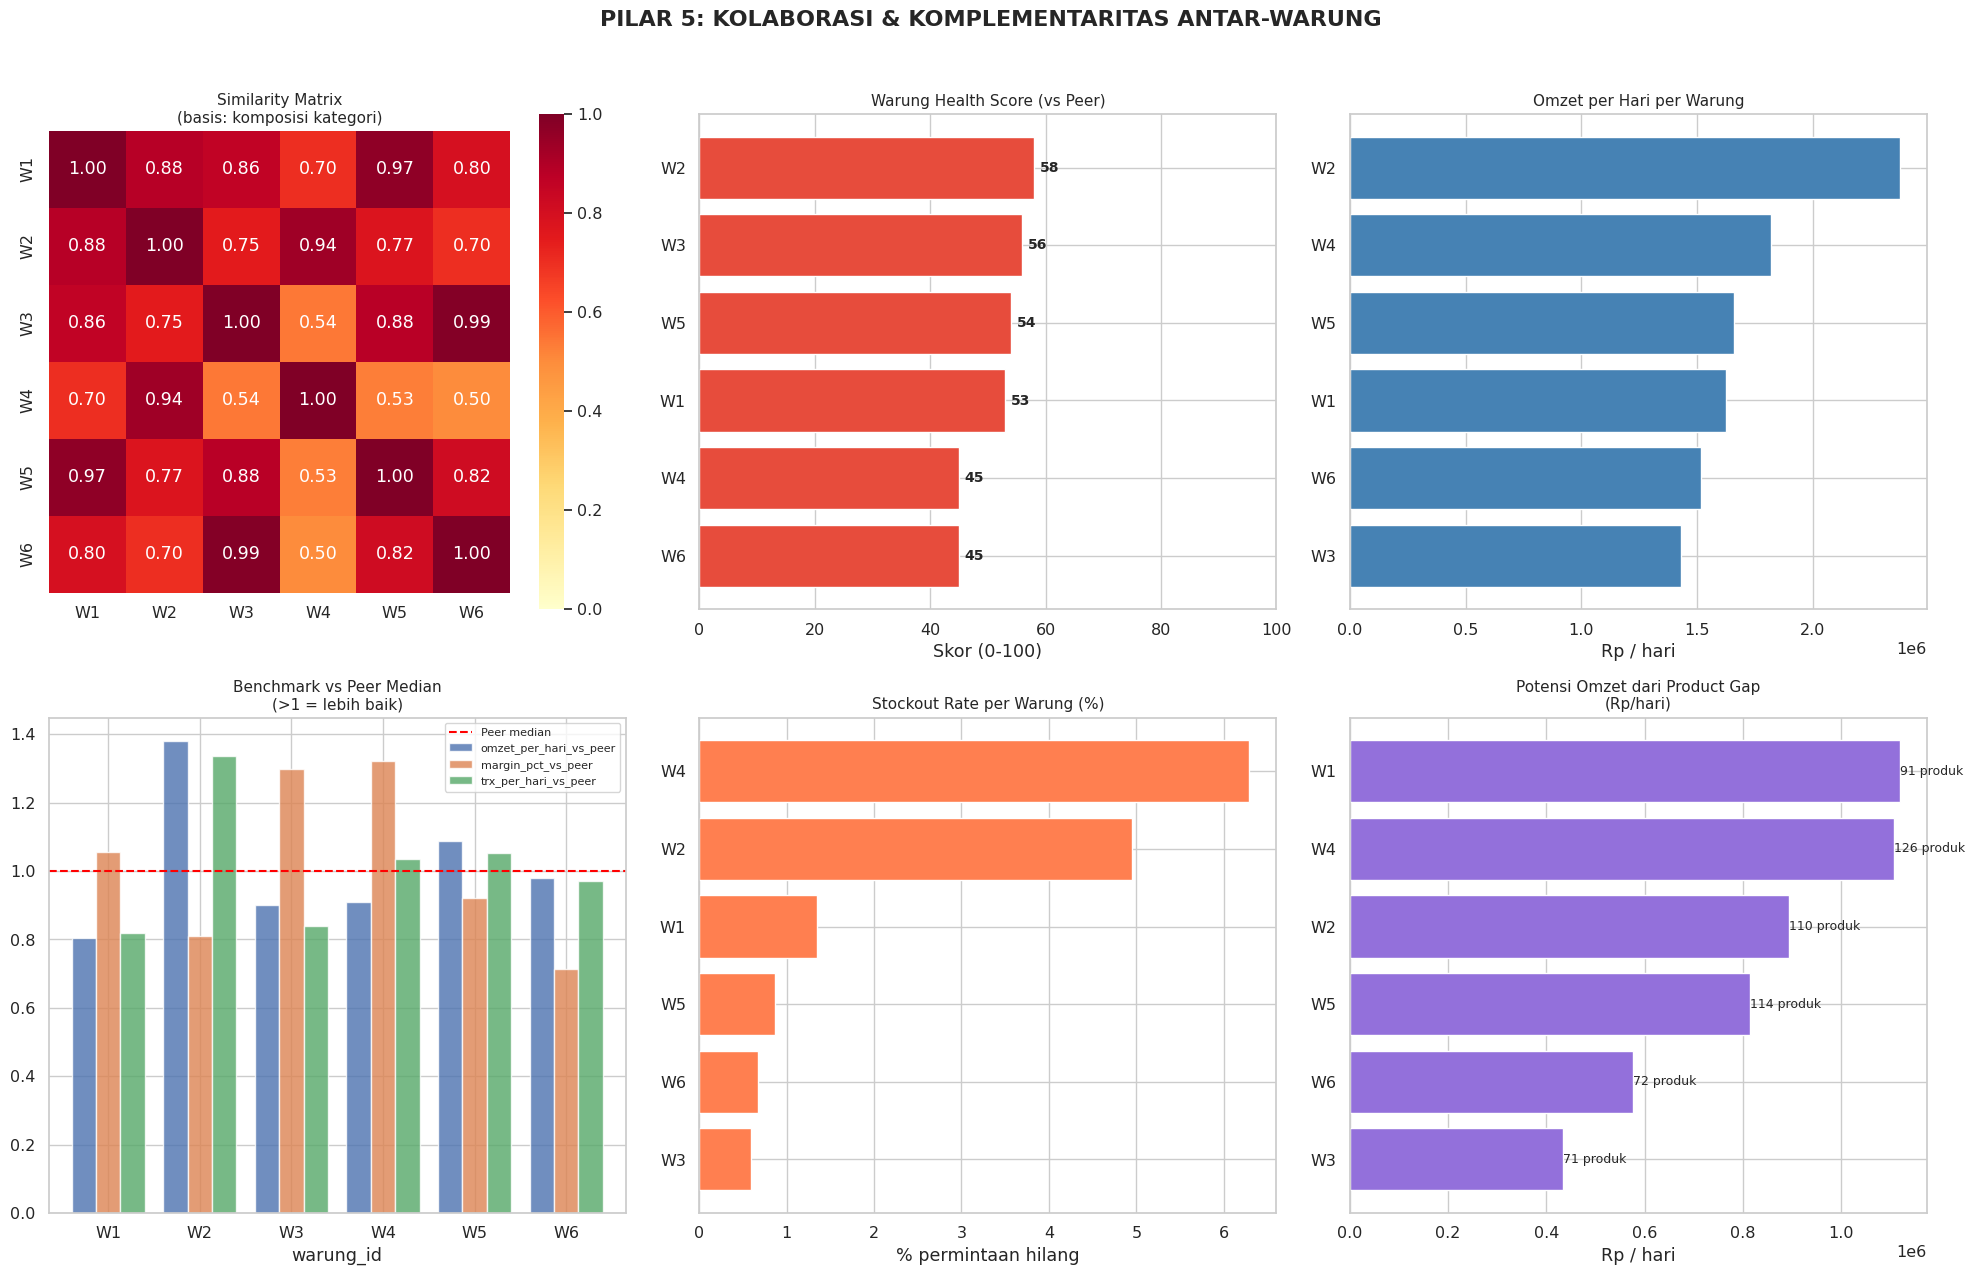


10. RINGKASAN INSIGHT KOLABORASI

┌─────────────────────────────────────────────────────────────────┐
│                  RINGKASAN PILAR 5                              │
├─────────────────────────────────────────────────────────────────┤
│ Total Warung Dianalisis         :     6                    │
│ Product Gaps Ditemukan          :   584 produk             │
│ Rekomendasi Stok                :    26 produk             │
│ Peluang Jam Operasional         :     0 jam               │
│ Peluang Referral Stockout       :  1515 pasangan           │
│ Peluang Bundle Komplementer     :    30 pasangan           │
│ Health Score Rata-rata          :  51.8 / 100            │
│ Health Score Terendah           :    45 / 100            │
│ Health Score Tertinggi          :    58 / 100            │
│ Warung dengan Alert Tinggi      :     0                    │
└─────────────────────────────────────────────────────────────────┘

Semua output tersimpan di: outputs/pilar5_kolaborasi/

File yang diha

In [ ]:
# ============================================================
# PILAR 5: KOLABORASI & KOMPLEMENTARITAS ANTAR-WARUNG
# ============================================================
# Tujuan: Mengubah persaingan menjadi kolaborasi dengan:
#   1. Warung Similarity & Peer Grouping
#   2. Benchmark KPI antar-warung
#   3. Product Gap Analysis (produk yang belum distok)
#   4. Peer-based Stock Recommendations
#   5. Operating Hours Recommendations
#   6. Cross-Warung Anomaly Detection
#   7. Warung Health Score
#   8. Referral & Complementarity Opportunities
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.05)
PILAR5_OUT = "outputs/pilar5_kolaborasi"
import os
os.makedirs(PILAR5_OUT, exist_ok=True)

# ============================================================
# PERSIAPAN DATA
# ============================================================
print("=" * 70)
print("PILAR 5: KOLABORASI & KOMPLEMENTARITAS ANTAR-WARUNG")
print("=" * 70)

# Pastikan tanggal datetime
df_penjualan['tanggal'] = pd.to_datetime(df_penjualan['tanggal'])

# Hitung kolom turunan jika belum ada
if 'total_harga' not in df_penjualan.columns:
    df_penjualan['total_harga'] = df_penjualan['jumlah'] * df_penjualan['harga_jual']
if 'total_profit' not in df_penjualan.columns:
    df_penjualan['total_profit'] = (df_penjualan['harga_jual'] - df_penjualan['harga_beli']) * df_penjualan['jumlah']

# Load stockout jika tersedia
try:
    df_stockout['tanggal'] = pd.to_datetime(df_stockout['tanggal'])
    HAS_STOCKOUT = True
except:
    df_stockout = pd.DataFrame()
    HAS_STOCKOUT = False

# Load kalender jika tersedia
try:
    df_kalender = pd.read_csv('data_simulasi/kalender.csv')
    df_kalender['tanggal'] = pd.to_datetime(df_kalender['tanggal'])
    HAS_KALENDER = True
except:
    HAS_KALENDER = False

# Extract jam integer
if 'jam_int' not in df_penjualan.columns:
    df_penjualan['jam_int'] = pd.to_numeric(
        df_penjualan['jam'].astype(str).str[:2], errors='coerce')

print(f"\nData: {len(df_penjualan):,} baris penjualan | "
      f"{df_penjualan['warung_id'].nunique()} warung | "
      f"{df_penjualan['produk'].nunique()} produk")
print(f"Stockout tersedia: {HAS_STOCKOUT} | Kalender tersedia: {HAS_KALENDER}")

# ============================================================
# 1. WARUNG SIMILARITY & PEER GROUPING
# ============================================================
print("\n" + "=" * 70)
print("1. WARUNG SIMILARITY & PEER GROUPING")
print("=" * 70)

def build_warung_feature_matrix():
    """Bangun vektor fitur per warung untuk menghitung similarity."""
    features = {}

    for wid in df_penjualan['warung_id'].unique():
        wdf = df_penjualan[df_penjualan['warung_id'] == wid]

        # --- Fitur komposisi kategori (share omzet) ---
        cat_share = wdf.groupby('kategori')['total_harga'].sum()
        cat_share = cat_share / cat_share.sum()

        # --- Fitur komposisi profil produk ---
        prod_share = wdf.groupby('produk')['jumlah'].sum()
        prod_share = prod_share / prod_share.sum()

        # --- Fitur numerik ---
        n_hari = wdf['tanggal'].nunique()
        features[wid] = {
            'omzet_per_hari': wdf['total_harga'].sum() / n_hari,
            'trx_per_hari': wdf['trx_id'].nunique() / n_hari,
            'basket_size': wdf['jumlah'].sum() / wdf['trx_id'].nunique(),
            'margin_rata2': wdf['total_profit'].sum() / max(wdf['total_harga'].sum(), 1),
            'n_sku_aktif': wdf['produk'].nunique(),
            'n_kategori': wdf['kategori'].nunique(),
            'cat_share': cat_share,
            'prod_share': prod_share,
        }

    return features

def compute_similarity_matrix(features, n_peers=2):
    """Hitung similarity matrix berbasis cosine pada komposisi kategori."""
    warungs = sorted(features.keys())
    n = len(warungs)

    # Ambil semua kategori yang ada
    all_cats = sorted(set(
        c for f in features.values() for c in f['cat_share'].index
    ))

    # Bangun matriks share kategori
    mat = np.zeros((n, len(all_cats)))
    for i, wid in enumerate(warungs):
        for j, cat in enumerate(all_cats):
            mat[i, j] = features[wid]['cat_share'].get(cat, 0)

    # Cosine similarity
    sim_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                sim_matrix[i, j] = 1.0
            else:
                sim_matrix[i, j] = 1 - cosine(mat[i], mat[j])

    sim_df = pd.DataFrame(sim_matrix, index=warungs, columns=warungs)

    # Tentukan peer terdekat untuk setiap warung
    peers = {}
    for wid in warungs:
        scores = sim_df.loc[wid].drop(wid).sort_values(ascending=False)
        peers[wid] = scores.head(n_peers).index.tolist()

    return sim_df, peers

# Jalankan
warung_features = build_warung_feature_matrix()
sim_df, peer_map = compute_similarity_matrix(warung_features, n_peers=2)

# Tampilkan
print("\nSimilarity Matrix (berbasis komposisi kategori):")
print(sim_df.round(3).to_string())

print("\nPeer Terdekat tiap Warung:")
for wid, peers in peer_map.items():
    nama = df_warung[df_warung['warung_id'] == wid]['nama'].values[0] if wid in df_warung['warung_id'].values else wid
    peer_names = []
    for p in peers:
        pn = df_warung[df_warung['warung_id'] == p]['nama'].values[0] if p in df_warung['warung_id'].values else p
        peer_names.append(f"{p} ({pn})")
    print(f"  {wid} [{nama}] → {', '.join(peer_names)}")

# Simpan
sim_df.to_csv(f"{PILAR5_OUT}/similarity_matrix.csv")

# ============================================================
# 2. BENCHMARK KPI ANTAR-WARUNG
# ============================================================
print("\n" + "=" * 70)
print("2. BENCHMARK KPI ANTAR-WARUNG")
print("=" * 70)

def compute_kpi_table():
    """Hitung KPI utama per warung."""
    rows = []
    for wid in df_penjualan['warung_id'].unique():
        wdf = df_penjualan[df_penjualan['warung_id'] == wid]
        n_hari = wdf['tanggal'].nunique()

        omzet = wdf['total_harga'].sum()
        profit = wdf['total_profit'].sum()

        # Stockout rate
        if HAS_STOCKOUT:
            so = df_stockout[df_stockout['warung_id'] == wid]
            total_hilang = so['jumlah_hilang'].sum()
            total_demand = wdf['jumlah'].sum() + total_hilang
            so_rate = total_hilang / max(total_demand, 1)
        else:
            so_rate = np.nan
            total_hilang = 0

        rows.append({
            'warung_id': wid,
            'nama': df_warung[df_warung['warung_id'] == wid]['nama'].values[0]
                    if wid in df_warung['warung_id'].values else wid,
            'omzet_total': omzet,
            'omzet_per_hari': omzet / n_hari,
            'profit_total': profit,
            'profit_per_hari': profit / n_hari,
            'margin_pct': profit / max(omzet, 1),
            'trx_per_hari': wdf['trx_id'].nunique() / n_hari,
            'basket_size': wdf['jumlah'].sum() / max(wdf['trx_id'].nunique(), 1),
            'n_sku': wdf['produk'].nunique(),
            'stockout_rate': so_rate,
            'total_hilang': total_hilang,
        })

    return pd.DataFrame(rows)

kpi_df = compute_kpi_table()

# Bandingkan vs peer median & network median
def benchmark_vs_peers(kpi_df, peer_map):
    """Hitung rasio KPI warung vs peer median dan network median."""
    metrics = ['omzet_per_hari', 'margin_pct', 'trx_per_hari', 'basket_size', 'stockout_rate']
    results = []

    for _, row in kpi_df.iterrows():
        wid = row['warung_id']
        peers = peer_map.get(wid, [])

        # Peer median
        peer_kpi = kpi_df[kpi_df['warung_id'].isin(peers)]

        # Network median (exclude self)
        net_kpi = kpi_df[kpi_df['warung_id'] != wid]

        r = {'warung_id': wid, 'nama': row['nama']}
        for m in metrics:
            val = row[m]
            peer_med = peer_kpi[m].median() if len(peer_kpi) > 0 else np.nan
            net_med = net_kpi[m].median() if len(net_kpi) > 0 else np.nan

            # Untuk stockout, lebih rendah = lebih baik
            if m == 'stockout_rate':
                r[f'{m}_vs_peer'] = peer_med / max(val, 1e-9) if not np.isnan(peer_med) else np.nan
                r[f'{m}_vs_net'] = net_med / max(val, 1e-9) if not np.isnan(net_med) else np.nan
            else:
                r[f'{m}_vs_peer'] = val / max(peer_med, 1e-9) if not np.isnan(peer_med) else np.nan
                r[f'{m}_vs_net'] = val / max(net_med, 1e-9) if not np.isnan(net_med) else np.nan

        results.append(r)

    return pd.DataFrame(results)

benchmark_df = benchmark_vs_peers(kpi_df, peer_map)

print("\nKPI per Warung:")
display(kpi_df[['warung_id', 'nama', 'omzet_per_hari', 'profit_per_hari',
                'margin_pct', 'trx_per_hari', 'basket_size', 'stockout_rate']]
        .round({'omzet_per_hari': 0, 'profit_per_hari': 0, 'margin_pct': 3,
                'trx_per_hari': 1, 'basket_size': 2, 'stockout_rate': 3}))

print("\nBenchmark vs Peer (rasio > 1 = lebih baik dari peer):")
display(benchmark_df.round(3))

kpi_df.to_csv(f"{PILAR5_OUT}/kpi_per_warung.csv", index=False)
benchmark_df.to_csv(f"{PILAR5_OUT}/benchmark_vs_peer.csv", index=False)

# ============================================================
# 3. PRODUCT GAP ANALYSIS
# ============================================================
print("\n" + "=" * 70)
print("3. PRODUCT GAP ANALYSIS")
print("=" * 70)

def product_gap_analysis(min_omzet_peer=50000):
    """
    Identifikasi produk yang dijual peer tapi belum distok warung ini.
    min_omzet_peer: minimum omzet di peer agar dianggap 'layak' direkomendasikan.
    """
    results = []

    for wid in df_penjualan['warung_id'].unique():
        wdf = df_penjualan[df_penjualan['warung_id'] == wid]
        produk_saya = set(wdf['produk'].unique())
        peers = peer_map.get(wid, [])

        # Produk yang dijual peers
        peer_df = df_penjualan[df_penjualan['warung_id'].isin(peers)]
        peer_prod_stats = peer_df.groupby('produk').agg(
            omzet_peer=('total_harga', 'sum'),
            qty_peer=('jumlah', 'sum'),
            kategori=('kategori', 'first'),
            n_warung_peer=('warung_id', 'nunique'),
        ).reset_index()

        # Filter: belum dijual di warung ini & cukup laku di peer
        gap = peer_prod_stats[
            (~peer_prod_stats['produk'].isin(produk_saya)) &
            (peer_prod_stats['omzet_peer'] >= min_omzet_peer)
        ].copy()

        if len(gap) == 0:
            continue

        # Estimasi omzet harian jika warung ini juga menjual
        n_hari = peer_df['tanggal'].nunique()
        gap['estimasi_omzet_harian'] = gap['omzet_peer'] / max(n_hari, 1) / max(len(peers), 1)
        gap['estimasi_qty_harian'] = gap['qty_peer'] / max(n_hari, 1) / max(len(peers), 1)
        gap['warung_id'] = wid
        gap['n_produk_saya'] = len(produk_saya)

        results.append(gap.sort_values('estimasi_omzet_harian', ascending=False))

    if results:
        return pd.concat(results, ignore_index=True)
    return pd.DataFrame()

gap_df = product_gap_analysis(min_omzet_peer=50000)

if len(gap_df) > 0:
    print(f"\nTotal {len(gap_df)} produk gap ditemukan.")
    print("\nTop 5 Produk Gap per Warung:")
    for wid in df_penjualan['warung_id'].unique():
        wgap = gap_df[gap_df['warung_id'] == wid].head(5)
        if len(wgap) == 0:
            continue
        nama = df_warung[df_warung['warung_id'] == wid]['nama'].values[0] if wid in df_warung['warung_id'].values else wid
        print(f"\n  [{wid}] {nama}:")
        for _, r in wgap.iterrows():
            print(f"    • {r['produk']} ({r['kategori']}) | "
                  f"Est. Rp{r['estimasi_omzet_harian']:,.0f}/hari | "
                  f"~{r['estimasi_qty_harian']:.1f} unit/hari")

    gap_df.to_csv(f"{PILAR5_OUT}/product_gap.csv", index=False)
else:
    print("Tidak ada product gap yang signifikan.")

# ============================================================
# 4. PEER-BASED STOCK RECOMMENDATIONS
# ============================================================
print("\n" + "=" * 70)
print("4. PEER-BASED STOCK RECOMMENDATIONS")
print("=" * 70)

def peer_stock_recommendations(target_days=7):
    """
    Rekomendasikan stok berdasarkan perbandingan laju jual vs peer.
    Jika warung jual lebih lambat dari peer tapi punya produk yang sama,
    kemungkinan stok terlalu sedikit atau ada masalah display/lokasi.
    """
    results = []

    for wid in df_penjualan['warung_id'].unique():
        wdf = df_penjualan[df_penjualan['warung_id'] == wid]
        n_hari = wdf['tanggal'].nunique()
        peers = peer_map.get(wid, [])
        peer_df = df_penjualan[df_penjualan['warung_id'].isin(peers)]

        # Laju jual per produk di warung ini
        my_rates = wdf.groupby('produk').agg(
            qty_saya=('jumlah', 'sum'),
            stok_terakhir=('stok_akhir', 'last'),
            kategori=('kategori', 'first'),
        ).reset_index()
        my_rates['rate_saya'] = my_rates['qty_saya'] / max(n_hari, 1)

        # Laju jual per produk di peers
        peer_rates = peer_df.groupby('produk').agg(
            qty_peer=('jumlah', 'sum'),
        ).reset_index()
        n_hari_peer = peer_df['tanggal'].nunique()
        peer_rates['rate_peer'] = peer_rates['qty_peer'] / max(n_hari_peer, 1) / max(len(peers), 1)

        # Merge
        merged = my_rates.merge(peer_rates[['produk', 'rate_peer']], on='produk', how='inner')

        # Identifikasi produk dengan rate_saya << rate_peer (potensi understock)
        merged['ratio'] = merged['rate_saya'] / merged['rate_peer'].clip(lower=0.01)
        underperforming = merged[
            (merged['ratio'] < 0.5) &  # Jual kurang dari 50% laju peer
            (merged['rate_peer'] > 0.5)  # Peer cukup aktif jual
        ].copy()

        if len(underperforming) == 0:
            continue

        # Rekomendasi stok target
        underperforming['stok_target'] = np.ceil(underperforming['rate_peer'] * target_days)
        underperforming['saran_tambah'] = (underperforming['stok_target'] -
                                            underperforming['stok_terakhir']).clip(lower=0).astype(int)
        underperforming['warung_id'] = wid
        underperforming['hari_stok_sisa'] = (underperforming['stok_terakhir'] /
                                              underperforming['rate_saya'].clip(lower=0.01)).round(1)

        results.append(underperforming.sort_values('rate_peer', ascending=False))

    if results:
        return pd.concat(results, ignore_index=True)
    return pd.DataFrame()

stock_rec_df = peer_stock_recommendations(target_days=7)

if len(stock_rec_df) > 0:
    print(f"\nTotal {len(stock_rec_df)} produk perlu perhatian stok.")
    print("\nTop Rekomendasi Stok per Warung:")
    for wid in df_penjualan['warung_id'].unique():
        wrec = stock_rec_df[stock_rec_df['warung_id'] == wid].head(5)
        if len(wrec) == 0:
            continue
        nama = df_warung[df_warung['warung_id'] == wid]['nama'].values[0] if wid in df_warung['warung_id'].values else wid
        print(f"\n  [{wid}] {nama}:")
        for _, r in wrec.iterrows():
            print(f"    • {r['produk']} | Stok: {r['stok_terakhir']:.0f} | "
                  f"Rate saya: {r['rate_saya']:.1f}/hari vs Peer: {r['rate_peer']:.1f}/hari | "
                  f"Saran: +{r['saran_tambah']} unit (target {r['stok_target']:.0f})")

    stock_rec_df.to_csv(f"{PILAR5_OUT}/stock_recommendations.csv", index=False)
else:
    print("Tidak ada rekomendasi stok signifikan.")

# ============================================================
# 5. OPERATING HOURS RECOMMENDATIONS
# ============================================================
print("\n" + "=" * 70)
print("5. OPERATING HOURS RECOMMENDATIONS")
print("=" * 70)

def operating_hours_analysis():
    """
    Analisis pola jam penjualan per warung & bandingkan dengan peer.
    Identifikasi jam-jam di mana peer ramai tapi warung ini sepi.
    """
    results = []

    # Pola jam per warung
    hourly = df_penjualan.groupby(['warung_id', 'jam_int']).agg(
        omzet=('total_harga', 'sum'),
        qty=('jumlah', 'sum'),
        n_trx=('trx_id', 'nunique'),
    ).reset_index()

    # Normalisasi per warung (share dari total harian)
    daily_totals = hourly.groupby('warung_id')['omzet'].sum().reset_index()
    daily_totals.columns = ['warung_id', 'omzet_total']
    hourly = hourly.merge(daily_totals, on='warung_id')
    hourly['share_omzet'] = hourly['omzet'] / hourly['omzet_total'].clip(lower=1)

    # Untuk setiap warung, bandingkan dengan peer
    for wid in df_penjualan['warung_id'].unique():
        peers = peer_map.get(wid, [])
        my_hours = hourly[hourly['warung_id'] == wid][['jam_int', 'share_omzet']].set_index('jam_int')
        peer_hours = hourly[hourly['warung_id'].isin(peers)].groupby('jam_int')['share_omzet'].mean()

        # Jam di mana peer punya share tinggi tapi warung ini rendah
        all_hours = sorted(set(my_hours.index) | set(peer_hours.index))
        for h in all_hours:
            my_share = my_hours.loc[h, 'share_omzet'] if h in my_hours.index else 0
            peer_share = peer_hours.get(h, 0)

            if peer_share > 0.05 and my_share < peer_share * 0.5:
                results.append({
                    'warung_id': wid,
                    'jam': int(h),
                    'share_saya': my_share,
                    'share_peer': peer_share,
                    'gap': peer_share - my_share,
                    'rekomendasi': f"Peer dapat {peer_share:.1%} omzet di jam {int(h):02d}:00, "
                                   f"warung Anda hanya {my_share:.1%}. "
                                   f"Potensi tambahan: ~{gap:.1%} omzet."
                })

    return pd.DataFrame(results), hourly

hours_rec_df, hourly_data = operating_hours_analysis()

if len(hours_rec_df) > 0:
    print(f"\nTotal {len(hours_rec_df)} peluang jam operasional ditemukan.")
    print("\nPeluang Jam per Warung:")
    for wid in df_penjualan['warung_id'].unique():
        whours = hours_rec_df[hours_rec_df['warung_id'] == wid].sort_values('gap', ascending=False).head(3)
        if len(whours) == 0:
            continue
        nama = df_warung[df_warung['warung_id'] == wid]['nama'].values[0] if wid in df_warung['warung_id'].values else wid
        print(f"\n  [{wid}] {nama}:")
        for _, r in whours.iterrows():
            print(f"    • Jam {r['jam']:02d}:00 → {r['rekomendasi']}")

    hours_rec_df.to_csv(f"{PILAR5_OUT}/operating_hours_opportunities.csv", index=False)
else:
    print("Tidak ada peluang jam operasional signifikan.")

# ============================================================
# 6. CROSS-WARUNG ANOMALY DETECTION
# ============================================================
print("\n" + "=" * 70)
print("6. CROSS-WARUNG ANOMALY DETECTION")
print("=" * 70)

def cross_warung_anomaly(window=7):
    """
    Deteksi anomali spesifik warung vs tren jaringan.
    Jika satu warung turun tapi peer naik → masalah internal.
    Jika semua turun → tren pasar/musiman.
    """
    # Hitung omzet harian per warung
    daily = df_penjualan.groupby(['warung_id', 'tanggal'])['total_harga'].sum().reset_index()
    daily.columns = ['warung_id', 'tanggal', 'omzet']

    last_date = daily['tanggal'].max()
    recent_start = last_date - pd.Timedelta(days=window)
    prev_start = last_date - pd.Timedelta(days=2 * window)

    results = []

    for wid in df_penjualan['warung_id'].unique():
        wdf = daily[daily['warung_id'] == wid]

        recent = wdf[wdf['tanggal'] > recent_start]['omzet'].sum()
        prev = wdf[(wdf['tanggal'] > prev_start) & (wdf['tanggal'] <= recent_start)]['omzet'].sum()

        growth_self = (recent - prev) / max(prev, 1)

        # Growth peers
        peers = peer_map.get(wid, [])
        peer_daily = daily[daily['warung_id'].isin(peers)]
        peer_recent = peer_daily[peer_daily['tanggal'] > recent_start]['omzet'].sum()
        peer_prev = peer_daily[(peer_daily['tanggal'] > prev_start) &
                               (peer_daily['tanggal'] <= recent_start)]['omzet'].sum()
        growth_peer = (peer_recent - peer_prev) / max(peer_prev, 1)

        # Network growth (all warungs except self)
        net_daily = daily[daily['warung_id'] != wid]
        net_recent = net_daily[net_daily['tanggal'] > recent_start]['omzet'].sum()
        net_prev = net_daily[(net_daily['tanggal'] > prev_start) &
                             (net_daily['tanggal'] <= recent_start)]['omzet'].sum()
        growth_net = (net_recent - net_prev) / max(net_prev, 1)

        # Diagnosis
        delta_vs_peer = growth_self - growth_peer

        if growth_self < -0.05 and growth_peer > 0:
            diagnosis = "MASALAH_SPESIFIK_WARUNG"
            severity = "HIGH"
        elif growth_self < -0.05 and growth_peer < -0.05:
            diagnosis = "TREN_PASAR_MENURUN"
            severity = "LOW"
        elif growth_self > 0.05 and growth_peer <= 0:
            diagnosis = "KINERJA_BAIK_SPESIFIK"
            severity = "INFO"
        elif growth_self > 0.05 and growth_peer > 0.05:
            diagnosis = "TREN_PASAR_NAIK"
            severity = "INFO"
        else:
            diagnosis = "NORMAL"
            severity = "LOW"

        results.append({
            'warung_id': wid,
            'growth_self': growth_self,
            'growth_peer': growth_peer,
            'growth_network': growth_net,
            'delta_vs_peer': delta_vs_peer,
            'diagnosis': diagnosis,
            'severity': severity,
        })

    return pd.DataFrame(results)

anomaly_df = cross_warung_anomaly(window=7)

print("\nDiagnosis Anomali Lintas-Warung (7 hari terakhir):")
display(anomaly_df.round(3))

# Highlight yang perlu perhatian
high_alert = anomaly_df[anomaly_df['severity'] == 'HIGH']
if len(high_alert) > 0:
    print("\n⚠️  PERHATIAN - Warung dengan masalah spesifik:")
    for _, r in high_alert.iterrows():
        nama = df_warung[df_warung['warung_id'] == r['warung_id']]['nama'].values[0]
        print(f"  [{r['warung_id']}] {nama}: Growth {r['growth_self']:.1%} "
              f"vs Peer {r['growth_peer']:.1%} → {r['diagnosis']}")

anomaly_df.to_csv(f"{PILAR5_OUT}/cross_warung_anomaly.csv", index=False)

# ============================================================
# 7. WARUNG HEALTH SCORE
# ============================================================
print("\n" + "=" * 70)
print("7. WARUNG HEALTH SCORE (0-100)")
print("=" * 70)

def compute_health_score(kpi_df, peer_map):
    """
    Hitung skor kesehatan warung 0-100 berdasarkan perbandingan vs peer.
    Komponen:
      - Omzet (30%)
      - Margin (20%)
      - Frekuensi transaksi (15%)
      - Basket size (15%)
      - Stockout rate (20%) - lebih rendah = lebih baik
    """

    def ratio_score(value, reference, higher_is_better=True):
        """Konversi rasio ke skor 0-100. Rasio 1.0 = 50."""
        if np.isnan(value) or np.isnan(reference) or reference == 0:
            return 50
        ratio = value / reference
        if not higher_is_better:
            ratio = 1 / max(ratio, 0.01)
        # Map: ratio 0.5 → 0, ratio 1.0 → 50, ratio 1.5+ → 100
        score = np.clip((ratio - 0.5) * 100, 0, 100)
        return int(round(score))

    results = []

    for _, row in kpi_df.iterrows():
        wid = row['warung_id']
        peers = peer_map.get(wid, [])
        peer_kpi = kpi_df[kpi_df['warung_id'].isin(peers)]

        # Referensi = median peer
        ref = {
            'omzet_per_hari': peer_kpi['omzet_per_hari'].median() if len(peer_kpi) > 0 else np.nan,
            'margin_pct': peer_kpi['margin_pct'].median() if len(peer_kpi) > 0 else np.nan,
            'trx_per_hari': peer_kpi['trx_per_hari'].median() if len(peer_kpi) > 0 else np.nan,
            'basket_size': peer_kpi['basket_size'].median() if len(peer_kpi) > 0 else np.nan,
            'stockout_rate': peer_kpi['stockout_rate'].median() if len(peer_kpi) > 0 else np.nan,
        }

        scores = {
            'omzet': ratio_score(row['omzet_per_hari'], ref['omzet_per_hari']),
            'margin': ratio_score(row['margin_pct'], ref['margin_pct']),
            'frekuensi': ratio_score(row['trx_per_hari'], ref['trx_per_hari']),
            'basket': ratio_score(row['basket_size'], ref['basket_size']),
            'stockout': ratio_score(row['stockout_rate'], ref['stockout_rate'], higher_is_better=False),
        }

        # Weighted total
        weights = {'omzet': 0.30, 'margin': 0.20, 'frekuensi': 0.15,
                   'basket': 0.15, 'stockout': 0.20}
        total = sum(scores[k] * w for k, w in weights.items())

        results.append({
            'warung_id': wid,
            'nama': row['nama'],
            'skor_total': int(round(total)),
            **scores,
            'grade': 'A' if total >= 80 else 'B' if total >= 60 else 'C' if total >= 40 else 'D',
        })

    return pd.DataFrame(results)

health_df = compute_health_score(kpi_df, peer_map)
health_df = health_df.sort_values('skor_total', ascending=False).reset_index(drop=True)

print("\nHealth Score per Warung:")
display(health_df)

health_df.to_csv(f"{PILAR5_OUT}/health_score.csv", index=False)

# ============================================================
# 8. REFERRAL & COMPLEMENTARITY OPPORTUNITIES
# ============================================================
print("\n" + "=" * 70)
print("8. REFERRAL & COMPLEMENTARITY OPPORTUNITIES")
print("=" * 70)

def referral_opportunities():
    """
    Identifikasi peluang referral antar-warung:
    - Produk yang sering stockout di warung A tapi tersedia di warung B
    - Produk komplementer yang bisa di-bundle lintas warung
    """
    if not HAS_STOCKOUT:
        print("Data stockout tidak tersedia. Skipping referral analysis.")
        return pd.DataFrame(), pd.DataFrame()

    # --- Peluang Referral Stockout ---
    # Produk yang sering stockout di warung A
    so_by_warung_prod = df_stockout.groupby(['warung_id', 'produk']).agg(
        total_hilang=('jumlah_hilang', 'sum'),
        n_kejadian=('jumlah_hilang', 'count'),
    ).reset_index()

    # Produk yang tersedia (pernah dijual) di warung lain
    prod_available = df_penjualan.groupby(['warung_id', 'produk']).size().reset_index(name='n_trx')
    prod_available_set = set(zip(prod_available['warung_id'], prod_available['produk']))

    referrals = []
    for _, row in so_by_warung_prod.iterrows():
        wid = row['warung_id']
        prod = row['produk']

        # Cari warung lain yang jual produk ini
        for other_wid in df_penjualan['warung_id'].unique():
            if other_wid == wid:
                continue
            if (other_wid, prod) in prod_available_set:
                referrals.append({
                    'warung_stockout': wid,
                    'produk': prod,
                    'total_hilang': row['total_hilang'],
                    'n_kejadian': row['n_kejadian'],
                    'warung_referral': other_wid,
                    'tipe': 'REFERRAL_STOCKOUT',
                })

    referral_df = pd.DataFrame(referrals)

    # --- Complementarity Analysis ---
    # Produk yang sering dibeli bersamaan di satu warung tapi terpisah di warung lain
    # (simplified: kategori yang sering co-occur dalam transaksi)
    trx_items = df_penjualan.groupby(['warung_id', 'trx_id'])['kategori'].apply(set).reset_index()

    # Co-occurrence per warung
    complementarity = []
    for wid in df_penjualan['warung_id'].unique():
        wtrx = trx_items[trx_items['warung_id'] == wid]
        cat_sets = wtrx['kategori'].values

        # Hitung co-occurrence
        cooccur = {}
        for s in cat_sets:
            for pair in combinations(sorted(s), 2):
                cooccur[pair] = cooccur.get(pair, 0) + 1

        # Top pairs
        top_pairs = sorted(cooccur.items(), key=lambda x: -x[1])[:5]
        for (cat1, cat2), count in top_pairs:
            complementarity.append({
                'warung_id': wid,
                'kategori_1': cat1,
                'kategori_2': cat2,
                'co_occurrence': count,
                'tipe': 'COMPLEMENTARY_BUNDLE',
            })

    comp_df = pd.DataFrame(complementarity)

    return referral_df, comp_df

referral_df, complementarity_df = referral_opportunities()

if len(referral_df) > 0:
    print(f"\nPeluang Referral Stockout: {len(referral_df)} pasangan ditemukan.")
    # Top referral opportunities
    top_referrals = referral_df.sort_values('total_hilang', ascending=False).head(10)
    print("\nTop 10 Peluang Referral (berdasarkan jumlah hilang):")
    for _, r in top_referrals.iterrows():
        print(f"  [{r['warung_stockout']}] {r['produk']} hilang {r['total_hilang']:.0f} unit "
              f"({r['n_kejadian']}x) → bisa dirujuk ke [{r['warung_referral']}]")

    referral_df.to_csv(f"{PILAR5_OUT}/referral_opportunities.csv", index=False)

if len(complementarity_df) > 0:
    print(f"\nPeluang Bundle Komplementer: {len(complementarity_df)} pasangan kategori.")
    print("\nTop Co-occurrence per Warung:")
    for wid in df_penjualan['warung_id'].unique():
        wcomp = complementarity_df[complementarity_df['warung_id'] == wid].head(3)
        if len(wcomp) == 0:
            continue
        nama = df_warung[df_warung['warung_id'] == wid]['nama'].values[0] if wid in df_warung['warung_id'].values else wid
        print(f"\n  [{wid}] {nama}:")
        for _, r in wcomp.iterrows():
            print(f"    • {r['kategori_1']} + {r['kategori_2']} "
                  f"(co-occur {r['co_occurrence']}x) → potensi bundle/promo bersama")

    complementarity_df.to_csv(f"{PILAR5_OUT}/complementarity.csv", index=False)

# ============================================================
# 9. VISUALISASI
# ============================================================
print("\n" + "=" * 70)
print("9. VISUALISASI")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle("PILAR 5: KOLABORASI & KOMPLEMENTARITAS ANTAR-WARUNG",
             fontsize=16, fontweight='bold', y=0.98)

# --- Plot 1: Similarity Heatmap ---
sns.heatmap(sim_df, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0, 0], vmin=0, vmax=1, square=True)
axes[0, 0].set_title("Similarity Matrix\n(basis: komposisi kategori)", fontsize=11)

# --- Plot 2: Health Score Bar Chart ---
health_sorted = health_df.sort_values('skor_total')
colors = ['#2ecc71' if s >= 80 else '#f39c12' if s >= 60 else '#e74c3c' if s >= 40 else '#c0392b'
          for s in health_sorted['skor_total']]
axes[0, 1].barh(health_sorted['warung_id'], health_sorted['skor_total'], color=colors)
axes[0, 1].set_xlim(0, 100)
axes[0, 1].set_title("Warung Health Score (vs Peer)", fontsize=11)
axes[0, 1].set_xlabel("Skor (0-100)")
for i, (wid, score) in enumerate(zip(health_sorted['warung_id'], health_sorted['skor_total'])):
    axes[0, 1].text(score + 1, i, f'{score}', va='center', fontsize=10, fontweight='bold')

# --- Plot 3: KPI Comparison (Omzet per hari) ---
kpi_sorted = kpi_df.sort_values('omzet_per_hari')
axes[0, 2].barh(kpi_sorted['warung_id'], kpi_sorted['omzet_per_hari'], color='steelblue')
axes[0, 2].set_title("Omzet per Hari per Warung", fontsize=11)
axes[0, 2].set_xlabel("Rp / hari")

# --- Plot 4: Benchmark vs Peer (radar-like bar) ---
if len(benchmark_df) > 0:
    bench_metrics = ['omzet_per_hari_vs_peer', 'margin_pct_vs_peer', 'trx_per_hari_vs_peer']
    bench_plot = benchmark_df.set_index('warung_id')[bench_metrics]
    bench_plot.plot(kind='bar', ax=axes[1, 0], alpha=0.8, width=0.8)
    axes[1, 0].axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Peer median')
    axes[1, 0].set_title("Benchmark vs Peer Median\n(>1 = lebih baik)", fontsize=11)
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].tick_params(axis='x', rotation=0)

# --- Plot 5: Stockout Rate Comparison ---
if HAS_STOCKOUT:
    so_sorted = kpi_df.sort_values('stockout_rate')
    axes[1, 1].barh(so_sorted['warung_id'], so_sorted['stockout_rate'] * 100, color='coral')
    axes[1, 1].set_title("Stockout Rate per Warung (%)", fontsize=11)
    axes[1, 1].set_xlabel("% permintaan hilang")

# --- Plot 6: Product Gap Summary ---
if len(gap_df) > 0:
    gap_summary = gap_df.groupby('warung_id').agg(
        n_gap=('produk', 'count'),
        total_potensi=('estimasi_omzet_harian', 'sum'),
    ).reset_index().sort_values('total_potensi')

    ax2 = axes[1, 2]
    bars = ax2.barh(gap_summary['warung_id'], gap_summary['total_potensi'], color='mediumpurple')
    ax2.set_title("Potensi Omzet dari Product Gap\n(Rp/hari)", fontsize=11)
    ax2.set_xlabel("Rp / hari")

    # Annotate count
    for i, (idx, row) in enumerate(gap_summary.iterrows()):
        ax2.text(row['total_potensi'] + 100, i,
                f"{row['n_gap']} produk", va='center', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{PILAR5_OUT}/pilar5_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 10. RINGKASAN INSIGHT KOLABORASI
# ============================================================
print("\n" + "=" * 70)
print("10. RINGKASAN INSIGHT KOLABORASI")
print("=" * 70)

insight_summary = {
    'total_warung': int(df_penjualan['warung_id'].nunique()),
    'total_product_gaps': int(len(gap_df)) if len(gap_df) > 0 else 0,
    'total_stock_recommendations': int(len(stock_rec_df)) if len(stock_rec_df) > 0 else 0,
    'total_hour_opportunities': int(len(hours_rec_df)) if len(hours_rec_df) > 0 else 0,
    'total_referral_opportunities': int(len(referral_df)) if len(referral_df) > 0 else 0,
    'total_complementary_bundles': int(len(complementarity_df)) if len(complementarity_df) > 0 else 0,
    'health_score_avg': float(health_df['skor_total'].mean()),
    'health_score_min': int(health_df['skor_total'].min()),
    'health_score_max': int(health_df['skor_total'].max()),
    'high_alert_warungs': int((anomaly_df['severity'] == 'HIGH').sum()),
}

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                  RINGKASAN PILAR 5                              │
├─────────────────────────────────────────────────────────────────┤
│ Total Warung Dianalisis         : {insight_summary['total_warung']:>5}                    │
│ Product Gaps Ditemukan          : {insight_summary['total_product_gaps']:>5} produk             │
│ Rekomendasi Stok                : {insight_summary['total_stock_recommendations']:>5} produk             │
│ Peluang Jam Operasional         : {insight_summary['total_hour_opportunities']:>5} jam               │
│ Peluang Referral Stockout       : {insight_summary['total_referral_opportunities']:>5} pasangan           │
│ Peluang Bundle Komplementer     : {insight_summary['total_complementary_bundles']:>5} pasangan           │
│ Health Score Rata-rata          : {insight_summary['health_score_avg']:>5.1f} / 100            │
│ Health Score Terendah           : {insight_summary['health_score_min']:>5} / 100            │
│ Health Score Tertinggi          : {insight_summary['health_score_max']:>5} / 100            │
│ Warung dengan Alert Tinggi      : {insight_summary['high_alert_warungs']:>5}                    │
└─────────────────────────────────────────────────────────────────┘
""")

# Simpan insight summary
import json
with open(f"{PILAR5_OUT}/insight_summary.json", 'w') as f:
    json.dump(insight_summary, f, indent=4)

print(f"Semua output tersimpan di: {PILAR5_OUT}/")
print("\nFile yang dihasilkan:")
for f in sorted(os.listdir(PILAR5_OUT)):
    size = os.path.getsize(f"{PILAR5_OUT}/{f}")
    print(f"  • {f} ({size:,} bytes)")

print("\n✅ PILAR 5 SELESAI!")